# 📄 RETO 4 — SOSTENIBILIDAD AMBIENTAL Y COHESIÓN SOCIAL 

In [ ]:
# pip install pandas matplotlib seaborn requests beautifulsoup4 undetected-chromedriver
# pip install odfpy

In [1]:
# Importación de librerías

# Análisis y manipulación de datos
import pandas as pd             # Estructuras de datos (DataFrames) y análisis estadístico
import numpy as np              # Operaciones numéricas y manejo de matrices/arrays
import math                     # Funciones matemáticas estándar de Python

# Visualización de datos
import matplotlib.pyplot as plt # Creación de gráficos y visualizaciones básicas
import matplotlib.dates as mdates # Formateo y manejo de fechas en ejes de gráficos
import seaborn as sns           # Visualización de datos estadística basada en Matplotlib

# Web Scraping y automatización
import requests                 # Peticiones HTTP para descargar contenido web
from bs4 import BeautifulSoup   # Extracción de datos de archivos HTML y XML
import undetected_chromedriver as uc # Selenium optimizado para evitar la detección de bots

# Utilidades del sistema y archivos
import time                     # Manejo de pausas, retardos y tiempos de ejecución
import csv                      # Lectura y escritura de archivos en formato CSV

## 1. Introducción y planteamiento del problema

El modelo turístico-residencial de destinos como Torrevieja se caracteriza por una elevada variabilidad temporal de la población, derivada de la llegada masiva de visitantes en determinados periodos del año, especialmente durante la temporada estival. Esta dinámica genera una presión potencialmente significativa sobre los recursos naturales, las infraestructuras urbanas y el equilibrio social del municipio.

A diferencia de otros contextos turísticos donde la actividad se canaliza a través de infraestructuras claramente identificables (como el alojamiento hotelero), en Torrevieja la actividad turística se encuentra fuertemente integrada en el tejido residencial. Esto implica que los impactos asociados al turismo no siempre son directamente observables mediante indicadores tradicionales.

En este contexto, el objetivo del reto es evaluar, a partir de los datos disponibles, si existen evidencias de presión ambiental y social asociadas a la dinámica turística del municipio. Este análisis no se limita a la mera descripción de indicadores, sino que busca determinar hasta qué punto dichos datos permiten caracterizar de forma fiable los efectos del modelo turístico sobre el territorio.

Para abordar este objetivo, el análisis se articula en torno a dos dimensiones principales. Por un lado, la sostenibilidad ambiental, centrada en el estudio de la posible presión sobre recursos como el agua o los ecosistemas asociados, así como en el funcionamiento de infraestructuras críticas como el saneamiento. Por otro lado, la cohesión social, que se analiza a través de indicadores relacionados con la seguridad, el mercado de la vivienda y, de forma indirecta, la estructura socioeconómica del municipio.

A partir de este planteamiento general, este reto se estructura en torno a las siguientes preguntas de investigación:

* ¿Existen señales en los datos disponibles que indiquen presión sobre los recursos naturales, especialmente en periodos de alta demanda turística?
* ¿Se observan patrones temporales en variables sociales (como la criminalidad o los precios de la vivienda) que puedan asociarse a la estacionalidad del destino?
* ¿Hasta qué punto los indicadores disponibles permiten evaluar la sostenibilidad del modelo turístico-residencial de Torrevieja?

Desde el punto de vista metodológico, este reto presenta una característica principal: la necesidad de trabajar con indicadores indirectos y de interpretar los resultados bajo condiciones de incertidumbre. Por ello, uno de los elementos centrales del análisis será la distinción explícita entre tres niveles de evidencia.

En primer lugar, se identificarán aquellas conclusiones que pueden considerarse observaciones directas; es decir, aquellas que se derivan de manera inmediata de los datos analizados. En segundo lugar, se desarrollarán inferencias indirectas, basadas en la relación entre variables y en hipótesis plausibles sobre el funcionamiento del sistema turístico. Finalmente, se señalarán de forma explícita aquellas cuestiones que no pueden ser abordadas con los datos disponibles, poniendo de manifiesto las limitaciones estructurales del análisis.

## 2. Metodología de análisis

Dado que no disponemos de variables directas que midan de forma explícita la presión turística sobre el sistema ambiental y social, la metodología se ha orientado a la construcción de indicadores indirectos y al análisis de patrones temporales que permitan identificar posibles señales de dicha presión.

En primer lugar, se ha llevado a cabo una fase de descubrimiento de los datos disponibles o no disponibles a través de diversos enlaces:

### Búsqueda de datos fallida

1. **Registros relativos a las aguas de Torrevieja**: https://sinac.sanidad.gob.es/CiudadanoWeb/ciudadano/informacionAbastecimientoActionCA.do?idRed=697. Este enlace nos lleva a los registros históricos de SINAC de los tratamientos que se realizan a las aguas potables de Torrevieja. Sin embargo, solo se pueden los últimos tratamientos y los ciudadanos no tenemos disponibles los registros históricos de los tratamientos realizados. Esta información nos podría haber permitido comparar, por ejemplo, la cantidad de tratamientos realizados con la afluencia de turistas.

2. **Registros sobre los residuos generados**: 
   * https://www.miteco.gob.es/es/calidad-y-evaluacion-ambiental/publicaciones/memoria-anual-generacion-gestion-residuos.html#residuos-de-competencia-municipal. este enlace nos lleva a informes anuales sobre generación y gestión de residuos que, además de no resultar informativos, no nos ayudan a relacionar los residuos generados con los turistas.
   * https://dadesobertes.gva.es/es/dataset/pircv-tasas-de-generacion-de-residuos-domesticos-para-el-ano-2022-en-la-comunitat-valenciana/resource/c81f9e95-af05-4ea6-9674-974347709ba3. Si nos descargamos el archivo CSV de este enlace del PIRCV, nos damos cuenta de que trata de las tasas de generación de residuos domésticos en el año 2022 localizadas en la Comunitat Valenciana a nivel de consorcio, por lo que tampoco nos aportaría nada relevante (además de que es un datasets muy mal estructurado, que no presenta ni una columna temporal).

3. **Registros relacionados con las playas de Torrevieja**:
   * https://www.miteco.gob.es/es/cartografia-y-sig/ide/descargas/agua/censo-aguas-bano.htm. Este enlace únicamente nos informa de las playas que tiene Torrevieja.
   * En este punto, nos pareció oportuno intentar averiguar la ocupación de las playas de Torrevieja. Aunque el sistema *PlayasInteligentes.es* realiza una   monitorización constante del litoral de Torrevieja mediante sensores de IA y cámaras de visión artificial desde el 16 de agosto de 2024, los registros históricos detallados de la ocupación en la arena no se encuentran publicados para descarga abierta.

4. **Índice de precios de apartamentos turísticos**: https://www.ine.es/dyngs/INEbase/operacion.htm?c=Estadistica_C&cid=1254736176962&menu=resultados&idp=1254735576863. Desde este enlace, se trató de conseguir los precios de los apartamentos turísticos en Torrevieja durante los último años, para analizar como habían aumentado en el tiempo. Sin embargo, los resultados solo se encontraros a nivel nacional. Se pretendía cruzar este dato con los aumentos de los precios de la vivienda y de alquileres no turísticos en Torrevieja, para estudiar cómo los precios de apartamentos turísticos les habían afectado. 

### Búsqueda de datos exitosa

1. **Registros sobre las aguas subterráneas de Torrevieja**: https://www.chsegura.es/es/cuenca/redes-de-control/calidad-en-aguas-subterraneas/acceso-a-los-datos/. Este dataset nos informa sobre las diferentes sustancias presentes en las aguas subterráneas de Torrevieja. Se realizan tomas en torno a 2 o 4 meses en la estación *CA0748001*. Este conjunto de datos puede decirnos cómo de sano está el ecosistema subterráneo de Torrevieja o que cuántos químicos presentan las aguas subterráneas de Torrevieja, y analizarlos por años.

2. **Calidad del agua de baño**: https://nayadeciudadano.sanidad.gob.es/Splayas/ciudadano/ciudadanoZonaAction.do. Este enlace es del sistema NAYADE, que mide la contaminación microbiológica en las playas. En concreto, se realizan tomas aleatorias sobre las bacterias fecales *Escherichia coli* y *Enterococos*.

3. **Afluencia de visitantes a la Laguna de la Mata y Torrevieja**: https://datos.chantwin.iuii.ua.es/dataset/. En este enlace, aparece el número de personas que entraron y salieron cada ciertos minutos de la Laguna de la Mata y Torrevieja, comprendiéndose la serie temporal desde septiembre de 2024 hasta marzo de 2025. 

4. **Presupuestos Municipales (Gastos e Ingresos)**: no recuerdamos el enlace de donde obtuvimos estos datos. En ese enlace, conseguimos diferentes pdfs donde aparecen las partidas presupuestarias de ingresos y gastos de 2022-2025.

5. **Registros sobre criminalidad**: https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/balances. Este enlace nos proporciona el número de diferentes delitos que ocurrieron en Torrevieja por trismestres desde 2021 hasta 2025.

6. **Precios de la venta de viviendas en idealista**: https://www.idealista.com/sala-de-prensa/informes-precio-vivienda/venta/comunitat-valenciana/alicante-alacant/torrevieja/historico/. Aquí encontramos el precio del metro cuadrado de las viviendas en venta desde 2006 hasta 2026.

7. **Precios de los alquileres de viviendas en idealista**: https://www.idealista.com/sala-de-prensa/informes-precio-vivienda/alquiler/comunitat-valenciana/alicante-alacant/torrevieja/historico/. Aquí encontramos el precio del metro cuadrado de las viviendas en alquiler desde 2008 hasta 2026.

Así, una vez introducidos brevemente los datos buscados (tanto los encontrados como no), prodecemos a plantear cuestiones que intentaremos responder a partir de los datos conseguidos y las cuestiones que hubieramos intentado contestar a partir de lo que se buscó pero no halló:

### Formulación de cuestiones a responder o no

A partir del proceso de descubrimiento de datos, se han identificado una serie de preguntas de investigación que estructuran el análisis del reto. Estas preguntas se han clasificado en función de si pueden responderse directamente con los datos disponibles, si requieren inferencias indirectas o si no pueden abordarse debido a la ausencia de información.

#### Preguntas que podrían responderse directamente con los datos disponibles

**Eje ambiental**

* ¿Cómo evolucionan en el tiempo los principales parámetros físico-químicos de las aguas subterráneas en Torrevieja?
* ¿Existen tendencias crecientes o decrecientes en contaminantes como nitratos o conductividad?
* ¿Se mantienen estables los niveles de calidad del acuífero a lo largo de los años?
* ¿Cuál es el nivel de concentración de bacterias fecales (E. coli y Enterococos) en las playas de Torrevieja?
* ¿Se mantienen estos indicadores dentro de niveles considerados seguros para el baño?
* ¿Existen diferencias significativas entre distintas playas o puntos de muestreo?
* ¿Cómo varía la afluencia de visitantes en la Laguna de la Mata a lo largo del tiempo?
* ¿Se identifican patrones diarios o semanales en el uso de este espacio natural?

**Eje social**

* ¿Cómo evoluciona el número total de delitos en Torrevieja a lo largo del tiempo?
* ¿Qué tipologías delictivas son más frecuentes en el municipio?
* ¿Existen tendencias crecientes o decrecientes en la criminalidad en los últimos años?
* ¿Cómo han evolucionado los precios de la vivienda en venta en Torrevieja desde 2006?
* ¿Cómo han evolucionado los precios del alquiler desde 2008?
* ¿Existen cambios estructurales en el mercado inmobiliario en determinados periodos?
* ¿Cómo evolucionan los gastos e ingresos municipales asociados al turismo?
* ¿Existe un equilibrio entre los gastos y los ingresos generados por el turismo?
* ¿Se identifican patrones estacionales en el gasto turístico?

#### Preguntas que pueden abordarse mediante inferencia indirecta (cruce de datos)

* ¿Coinciden los periodos de mayor afluencia de visitantes con cambios en la calidad de las aguas subterráneas?
* ¿Se observa alguna relación temporal entre la presión de visitantes (Laguna) y los niveles de contaminantes?
* ¿Se producen variaciones en los indicadores microbiológicos de las playas en periodos de mayor uso turístico?
* ¿Puede inferirse que el sistema de saneamiento mantiene su funcionamiento bajo presión estacional?
* ¿Coinciden los periodos de mayor afluencia de visitantes con incrementos en la criminalidad?
* ¿Se observan patrones estacionales en determinados tipos de delitos (por ejemplo, hurtos)?
* ¿Existe una relación entre el crecimiento de los precios de la vivienda y el modelo turístico del municipio?
* ¿Se comportan de forma diferente los precios de venta y los precios de alquiler, lo que podría indicar presión sobre el mercado residencial?
* ¿Puede interpretarse la evolución de los precios como una señal indirecta de procesos de gentrificación o desplazamiento de población local?
* ¿Se puede relacionar la presión turística (aproximada mediante estacionalidad o afluencia) con el deterioro o estabilidad de indicadores ambientales?
* ¿Existe una relación temporal entre presión turística, criminalidad y evolución del mercado inmobiliario?
* ¿Se comportan de forma coherente los distintos indicadores (ambientales y sociales) ante los periodos de mayor demanda?

#### Preguntas que no pueden responderse por la falta de datos

**Eje ambiental**

* ¿Cuál es el consumo real de agua en Torrevieja por periodo temporal (mensual o estacional)?
* ¿Aumenta el consumo de agua de forma proporcional al incremento de la población turística?
* ¿Consume más agua un turista que un residente?
* ¿Cuál es el volumen de residuos generado en el municipio y cómo varía a lo largo del año?
* ¿Existe un incremento significativo de residuos en temporada alta?
* ¿Cuál es el nivel real de ocupación de las playas (personas por metro cuadrado)?
* ¿Se alcanzan niveles de saturación en determinados momentos del verano?

**Eje social**

* ¿Qué parte de la criminalidad está asociada a población residente frente a población visitante?
* ¿Existen diferencias espaciales (por barrios) en la criminalidad?
* ¿Cómo se distribuye la renta de los hogares dentro del municipio y cómo se relaciona con el turismo?
* ¿Existen procesos de segregación socioespacial asociados a la actividad turística?
* ¿Cuál es el precio real de los apartamentos turísticos en Torrevieja?
* ¿Cómo influyen los precios del alquiler turístico en el mercado de alquiler residencial?

### 2.1 Exploración básica de los diferentes datasets

#### 2.1.1 Registros sobre las aguas subterráneas de Torrevieja

Al acceder al enlace de estos registros, tenemos que rellenar los siguientes parámetros:

* Estación: AB070001 - Abast. Corral Rubio
* Masa de agua subterránea: TERCIARIO DE TORREVIEJA - 070.042
* Municipio: Torrevieja
* Provincia: ALICANTE
* Comunidad autónoma: Comunidad Valencia
* Fecha desde: 1-enero-2019
* Fecha hasta: 31-diciembre-2025

Posteriormente, nos descargamos el dataset en formato csv con el nombre: *Aguas subterráneas.csv*

In [2]:
df_aguas_subterraneas = pd.read_csv('../DATASETS/RETO 4/DATASETS ORIGINALES/Aguas subterráneas.csv', encoding="latin-1", sep=";")
df_aguas_subterraneas.head()

,ï»¿EstaciÃ³n,Fecha Toma,Cod. ParÃ¡metro,Nom. ParÃ¡metro,Unidades,Valor numÃ©rico,Valor texto,Coord. X,Coord. Y,Cod Masa,Nombre Masa,Municipio,Provincia,UH Geo,UH Geo Nombre,Acuifero,Profundidad,Nombre C.A
0,CA0748001,16/01/2019,12DIBR,"1,2-DIBROMOETANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
1,CA0748001,16/01/2019,2CLPRO,"1,3-DICLOROPROPANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
2,CA0748001,16/01/2019,2CLPROPA,"1,2-DICLOROPROPANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
3,CA0748001,16/01/2019,2CLPROPE,"1,1-DICLOROPROPENO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
4,CA0748001,16/01/2019,3CLETA,"1,1,2-TRICLOROETANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana


In [3]:
# Limpiamos los nombres de las variables
df_aguas_subterraneas = df_aguas_subterraneas.rename(columns=lambda x: x.replace('ï»¿', '').replace('Ã³', 'o').replace('Ã¡', 'a').strip())
df_aguas_subterraneas.columns = df_aguas_subterraneas.columns.str.strip()
df_aguas_subterraneas.columns.values[5] = 'Valor'

# Convertimos la columna de texto a formato fecha (datetime) 
# dayfirst=True asegura el formato DD/MM/AAAA y errors='coerce' evita errores con fechas vacías
df_aguas_subterraneas['Fecha Toma'] = pd.to_datetime(df_aguas_subterraneas['Fecha Toma'], dayfirst=True, errors='coerce')

print("=== 1. PRIMERAS FILAS DEL DATASET ===")
display(df_aguas_subterraneas.head())

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_aguas_subterraneas.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_aguas_subterraneas.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_aguas_subterraneas.duplicated().sum()}\n")

=== 1. PRIMERAS FILAS DEL DATASET ===


,Estacion,Fecha Toma,Cod. Parametro,Nom. Parametro,Unidades,Valor,Valor texto,Coord. X,Coord. Y,Cod Masa,Nombre Masa,Municipio,Provincia,UH Geo,UH Geo Nombre,Acuifero,Profundidad,Nombre C.A
0,CA0748001,2019-01-16,12DIBR,"1,2-DIBROMOETANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
1,CA0748001,2019-01-16,2CLPRO,"1,3-DICLOROPROPANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
2,CA0748001,2019-01-16,2CLPROPA,"1,2-DICLOROPROPANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
3,CA0748001,2019-01-16,2CLPROPE,"1,1-DICLOROPROPENO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana
4,CA0748001,2019-01-16,3CLETA,"1,1,2-TRICLOROETANO",Âµg/L,0,"< 0,5",705332,4207772,70042,TERCIARIO DE TORREVIEJA,Torrevieja,ALICANTE,748,TERCIARIO DE TORREVIEJA,TERCIARIO DE TORREVIEJA,320,Comunidad Valenciana



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 2434 entries, 0 to 2433
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Estacion        2434 non-null   str           
 1   Fecha Toma      2434 non-null   datetime64[us]
 2   Cod. Parametro  2411 non-null   str           
 3   Nom. Parametro  2434 non-null   str           
 4   Unidades        2434 non-null   str           
 5   Valor           2434 non-null   int64         
 6   Valor texto     2434 non-null   str           
 7   Coord. X        2434 non-null   int64         
 8   Coord. Y        2434 non-null   int64         
 9   Cod Masa        2434 non-null   int64         
 10  Nombre Masa     2434 non-null   str           
 11  Municipio       2434 non-null   str           
 12  Provincia       2434 non-null   str           
 13  UH Geo          2434 non-null   int64         
 14  UH Geo Nombre   2434 no

Las variables con las que contamos son:

1. *Estacion*: identificador único (ID) del punto de muestreo o pozo.
2. *Fecha Toma*: fecha en la que se recogió la muestra de agua.
3. *Municipio* / *Provincia*: ubicación administrativa de la estación (Filtro aplicado: Torrevieja / Alicante).
4. *Nom. Parametro*: nombre del elemento analizado.
5. *Valor numérico*: el resultado de la analítica. 
6. *Unidades*: unidad de medida (habitualmente mg/l o µS/cm).
7. *Valor texto*: observaciones adicionales o avisos si el valor está por debajo del límite de detección.
8. *Coord. X* / *Coord. Y*: coordenadas geográficas (UTM).
9. *Profundidad*: nivel al que se encuentra el agua bajo el suelo. Las capas más superficiales son más vulnerables a la contaminación urbana.
10. *Nombre Masa* / *Cod Masa*: identifica la unidad geológica.
11. *Acuifero*: descripción del tipo de roca o formación subterránea que almacena el agua.
12. *UH Geo* / *UH Geo Nombre*: unidad Hidrogeológica según la clasificación de la CHS.
13. *Nombre C.A*: nombre de la Comunidad Autónoma (Comunidad Valenciana).

Observamos que no tenemos valores vacíos en los datos ni filas duplicadas.

Creamos variables auxiliares que emplearemos en las visualizaciones:

In [4]:
# Extraemos el número del mes (del 1 al 12) de la columna 'Fecha Toma'
df_aguas_subterraneas['Mes'] = df_aguas_subterraneas['Fecha Toma'].dt.month

# Guardamos el dataset modificado
df_aguas_subterraneas.to_csv(
    '../DATASETS/RETO 4/DATASETS MODIFICADOS/Aguas_subterraneas_MOD.csv', 
    index=False, 
    sep=";", 
    encoding="latin-1"
)

En primer lugar, estudiamos el número de tomas para analizar que se realizan por año.

C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_21356\3195988425.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df_auxiliar, x='Año', y='Total Tomas', palette='viridis')


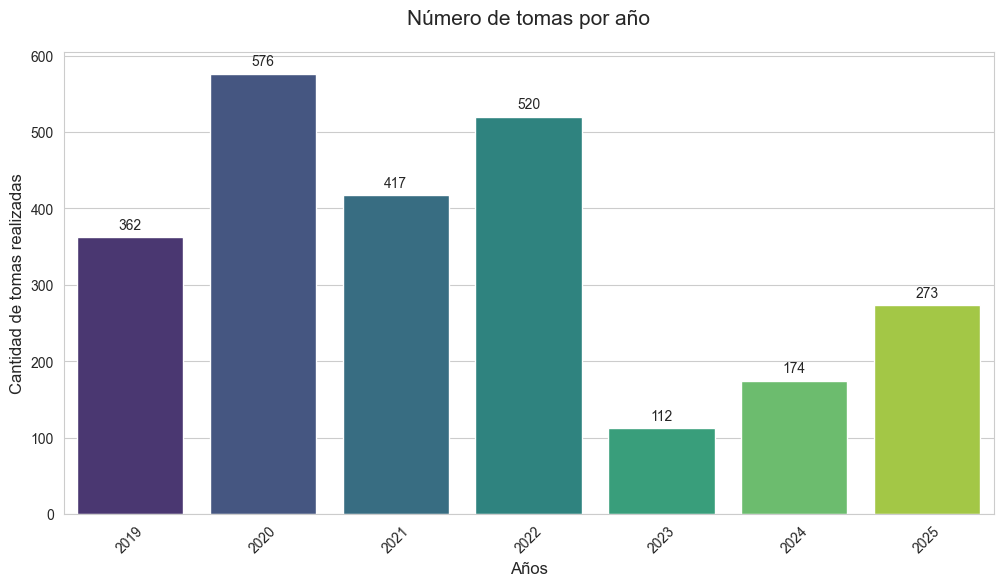

In [5]:
# Extraemos solo el número del año para poder agrupar cronológicamente
df_aguas_subterraneas['Año'] = df_aguas_subterraneas['Fecha Toma'].dt.year

# Creamos una tabla auxiliar contando cuántas filas (tomas) hay por cada año
# .size() cuenta los registros y .reset_index() le da formato de tabla limpia
df_auxiliar = df_aguas_subterraneas.groupby('Año').size().reset_index(name='Total Tomas')

# Definimos el tamaño del lienzo (ancho=12, alto=6)
plt.figure(figsize=(12, 6))

# Aplicamos un estilo de cuadrícula blanca de fondo para mejorar la lectura
sns.set_style("whitegrid")

# Dibujamos las barras usando el Año en el eje X y el conteo en el eje Y
# palette='viridis' aplica un degradado de color estético y moderno
barplot = sns.barplot(data=df_auxiliar, x='Año', y='Total Tomas', palette='viridis')

# Recorremos cada una de las barras (patches) para escribir su valor encima
for p in barplot.patches:
    barplot.annotate(
        format(p.get_height(), '.0f'),      # El texto a mostrar (el valor de la barra sin decimales)
        (p.get_x() + p.get_width() / 2., p.get_height()), # Posición: centro de la barra y arriba
        ha = 'center',                      # Alineación horizontal centrada
        va = 'center',                      # Alineación vertical centrada
        xytext = (0, 9),                    # Desplazamos el texto 9 puntos hacia arriba para que no toque la barra
        textcoords = 'offset points'        # Indica que el desplazamiento es en puntos relativos
    )

# Añadimos títulos y etiquetas a los ejes con tamaños de fuente legibles
plt.title('Número de tomas por año', fontsize=15, pad=20)
plt.xlabel('Años', fontsize=12)
plt.ylabel('Cantidad de tomas realizadas', fontsize=12)

# Giramos los años 45 grados para evitar que se amontonen si hay muchos
plt.xticks(rotation=45)
plt.show()

Observamos que antes y durante la pandemia de la COVID-19, se realizaron muchas más tomas y analíticas a las aguas subterráneas de Torrevieja que en años posteriores, aunque parece que la tendencia anual es a aumentar.

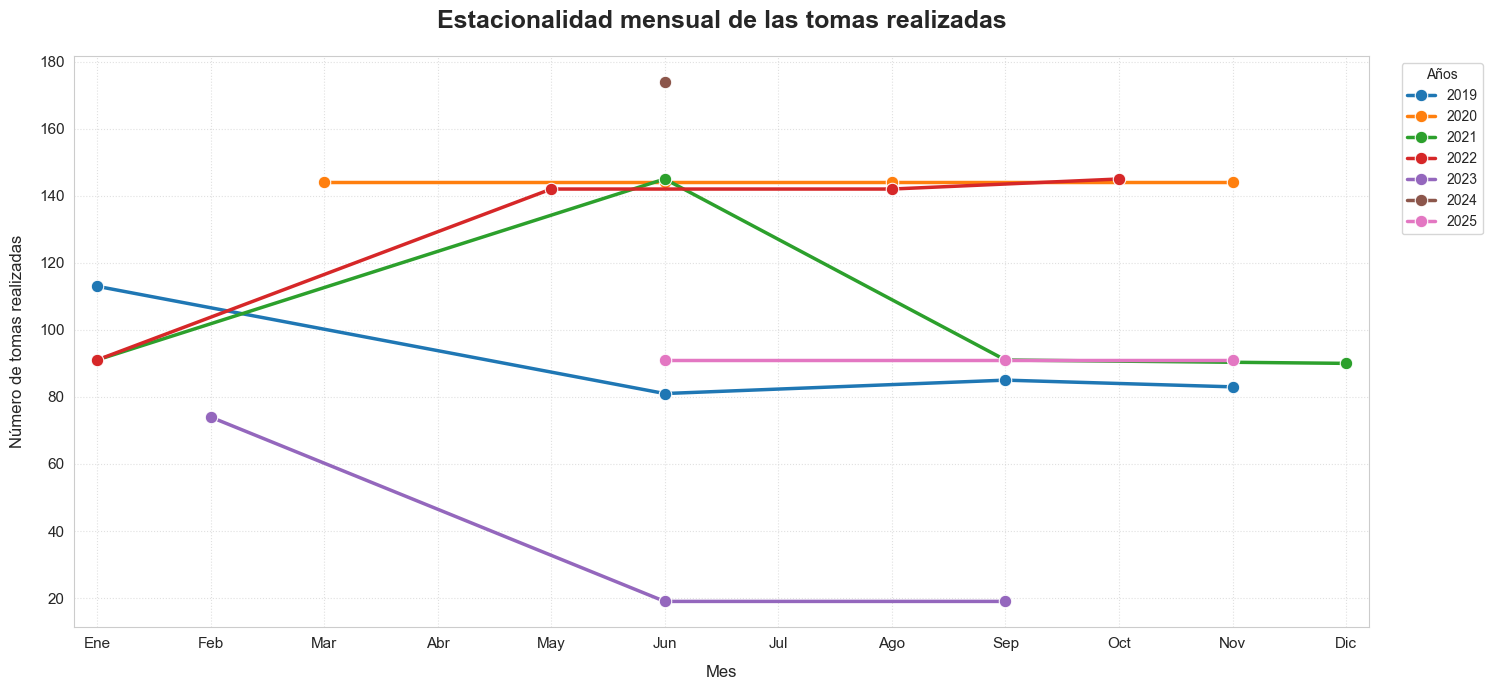

In [6]:
# Agrupamos por Año y Mes para contar cuántas analíticas se realizaron en cada periodo
# .size() cuenta los registros y .reset_index() crea una columna llamada 'Total' con el resultado
df_auxiliar = df_aguas_subterraneas.groupby(['Año', 'Mes']).size().reset_index(name='Total')

# Definimos el tamaño de la figura (15 de ancho x 7 de alto) para que la serie anual se vea espaciosa
plt.figure(figsize=(15, 7))

# Establecemos fondo blanco ('#ffffff') y cuadrícula ('whitegrid') para un acabado limpio y profesional
sns.set_style("whitegrid", {'axes.facecolor': '#ffffff'})

# Generamos una paleta de colores de alto contraste ('tab10') según el número de años únicos detectados
palette = sns.color_palette("tab10", n_colors=df_auxiliar['Año'].nunique())

# Dibujamos la evolución: eje X el mes, eje Y el conteo, y 'hue' separa una línea de color diferente por cada Año
# marker='o' añade círculos en los puntos de datos para identificar los meses con tomas reales
plot = sns.lineplot(data=df_auxiliar, x='Mes', y='Total', hue='Año', 
                    marker='o', markersize=9, linewidth=2.5, palette=palette)

# Definimos los nombres de los meses para sustituir los números (1-12) en el eje X
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.xticks(range(1, 13), meses_nombres, fontsize=11)
plt.yticks(fontsize=11)

# Añadimos título principal en negrita y etiquetas descriptivas a los ejes
plt.title('Estacionalidad mensual de las tomas realizadas', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Mes', fontsize=12, labelpad=10)
plt.ylabel('Número de tomas realizadas', fontsize=12, labelpad=10)

# Movemos la leyenda fuera del gráfico (derecha) para evitar que tape las líneas (bbox_to_anchor)
# loc='upper left' indica el punto de anclaje de la caja de la leyenda
plt.legend(title='Años', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)

# Configuramos la cuadrícula con líneas de puntos suaves (':') para no sobrecargar el gráfico
plt.grid(True, linestyle=':', alpha=0.6)

# Ajustamos el límite del eje X (de 0.8 a 12.2) para que los puntos de Enero y Diciembre no toquen los bordes
plt.xlim(0.8, 12.2)

# Optimizamos el espacio entre todos los elementos para que el gráfico no salga cortado al exportarlo
plt.tight_layout()

# Mostramos el resultado final
plt.show()

En esta gráfica sobre el despliegue de la serie temporal correspondiente a las tomas realizadas por meses, aparentenmente no observamos patrones en las tomas. No obstante, observamos que, en casi todos los años, se toman muestras en el mes de junio.

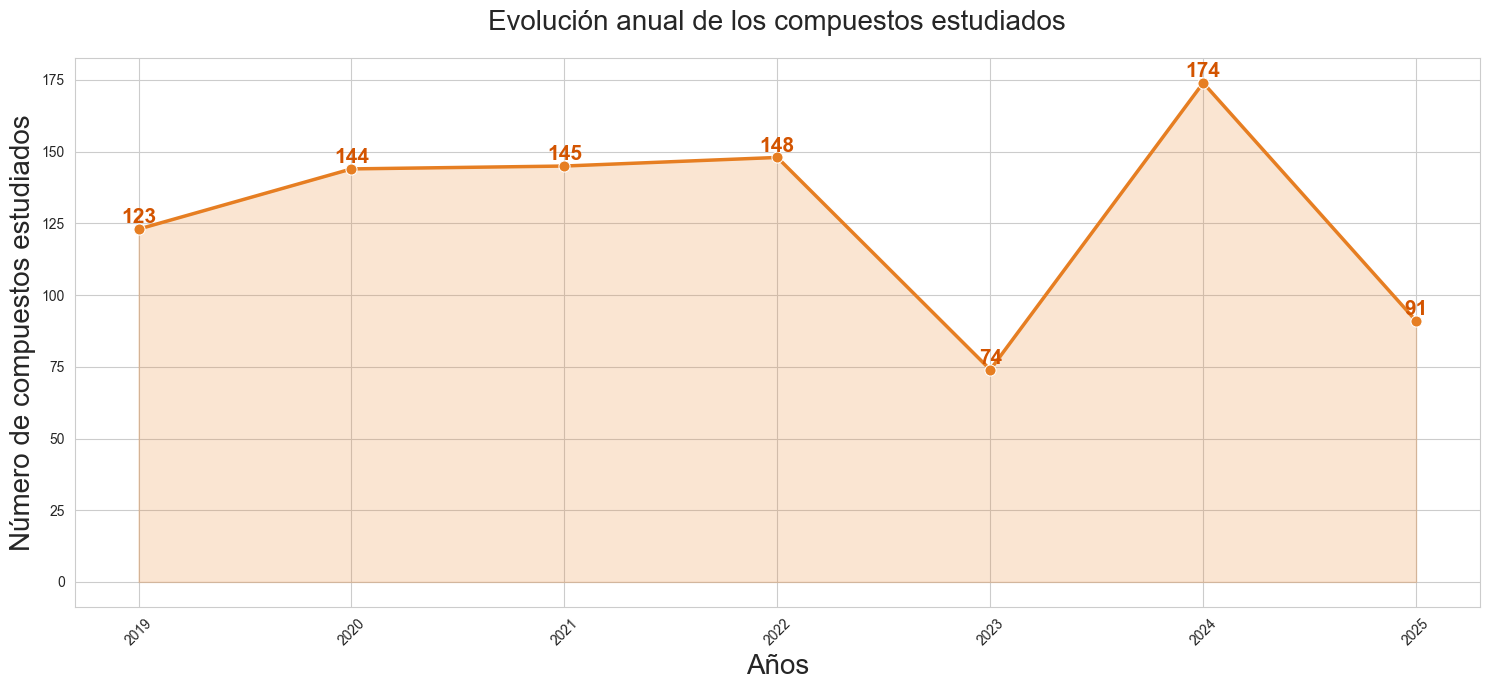

In [7]:
# Agrupamos por 'Año' y contamos cuántos nombres de parámetros ÚNICOS (.nunique) se investigaron
# Esto nos dice si cada año se analizaron más o menos tipos de sustancias diferentes
df_auxiliar = df_aguas_subterraneas.groupby('Año')['Nom. Parametro'].nunique().reset_index(name='Variedad Elementos')

# --- CONFIGURACIÓN DEL GRÁFICO ---
# Definimos el tamaño de la figura (12 de ancho x 6 de alto)
plt.figure(figsize=(15, 7))

# Aplicamos un estilo de fondo con cuadrícula para facilitar la lectura de los niveles
sns.set_style("whitegrid")

# Dibujamos una línea de evolución temporal
# marker='o' pone puntos en cada año, color naranja (#e67e22) para diferenciarlo de los otros gráficos
lineplot = sns.lineplot(data=df_auxiliar, x='Año', y='Variedad Elementos', 
                        marker='o', color='#e67e22', linewidth=2.5, markersize=8)

# Rellenamos el espacio bajo la curva con un color naranja suave (alpha=0.2 para transparencia)
# Esto ayuda a visualizar mejor el "volumen" de complejidad analítica a lo largo del tiempo
plt.fill_between(df_auxiliar['Año'], df_auxiliar['Variedad Elementos'], color='#e67e22', alpha=0.2)

# Recorremos los datos de Año (x) y Variedad (y) para escribir el número exacto sobre cada punto
# y + 2 desplaza el texto un poco hacia arriba para que no pise el punto
for x, y in zip(df_auxiliar['Año'], df_auxiliar['Variedad Elementos']):
    plt.text(x, y + 2, str(y), color='#d35400', fontweight='bold', ha='center', fontsize=15)

# Título enfocado a la "Complejidad Analítica" (término muy profesional para el trabajo)
plt.title('Evolución anual de los compuestos estudiados', fontsize=20, pad=20)
plt.xlabel('Años', fontsize=20)
plt.ylabel('Número de compuestos estudiados', fontsize=20)

# Forzamos que en el eje X aparezcan todos los años presentes en los datos
plt.xticks(df_auxiliar['Año'], rotation=45)

# Ajuste automático para evitar que las etiquetas o títulos queden fuera del marco
plt.tight_layout()

# Renderizamos la gráfica
plt.show()

En esta gráfica, estudiamos la evolución anual de los compuestos que se han ido estudiando en los años. Destaca como, sin sentido aparente, van cambiando los compuestos que se analizan en las diferentes tomas. Sería interesante intentar averiguar el porqué, aunque en este caso no se podrá llegar a ninguna conclusión.

Ahora, de todos los compuestos de los que tenemos registros, nos centramos en aquellos cuya inclusión en el agua resulta más peligrosa:

1. Metales pesados: son peligrosos porque no desaparecen, sino que se acumulan en el organismo.

   * MERCURIO y CADMIO: los más peligrosos de la lista. Son neurotóxicos y afectan a los riñones incluso en dosis mínimas.
   * PLOMO y ARSÉNICO: clásicos de la contaminación industrial o de tuberías antiguas. El arsénico es cancerígeno.
   * CROMO y NÍQUEL: asociados a vertidos industriales.

2. Pesticidas prohibidos: muchos de los compuestos encontrados en las aguas subterráneas están prohibidos en la UE desde hace años por su extrema toxicidad, pero siguen apareciendo porque el agua subterránea tarda décadas en renovarse.

   * LINDANO (GAMMA-HCH) y ALDRINA/DIELDRINA: pesticidas organoclorados muy tóxicos que afectan al sistema nervioso.
   * DDT (y sus derivados DDE, DDD): su presencia indica una contaminación muy antigua.
   * GLIFOSATO y AMPA: El herbicida más usado hoy día. Su presencia indica impacto de la agricultura o jardinería intensiva actual.

3. Compuestos orgánicos volátiles (disolventes y gasolinas): su aparición indica filtraciones de gasolineras, talleres o limpieza industrial.

   * BENCENO: altamente cancerígeno. Proviene de hidrocarburos.
   * CLORURO DE VINILO: muy peligroso, asociado a la degradación de plásticos y disolventes.
   * TETRACLOROETILENO y TRICLOROETILENO: disolventes industriales que contaminan acuíferos muy rápido.

4. Disruptores endocrinos y nuevos químicos:

   * BISFENOL-A: proviene de plásticos. Altera el sistema hormonal.
   * BENZO[A]PIRENO: un hidrocarburo cancerígeno que aparece por la combustión de combustibles fósiles.

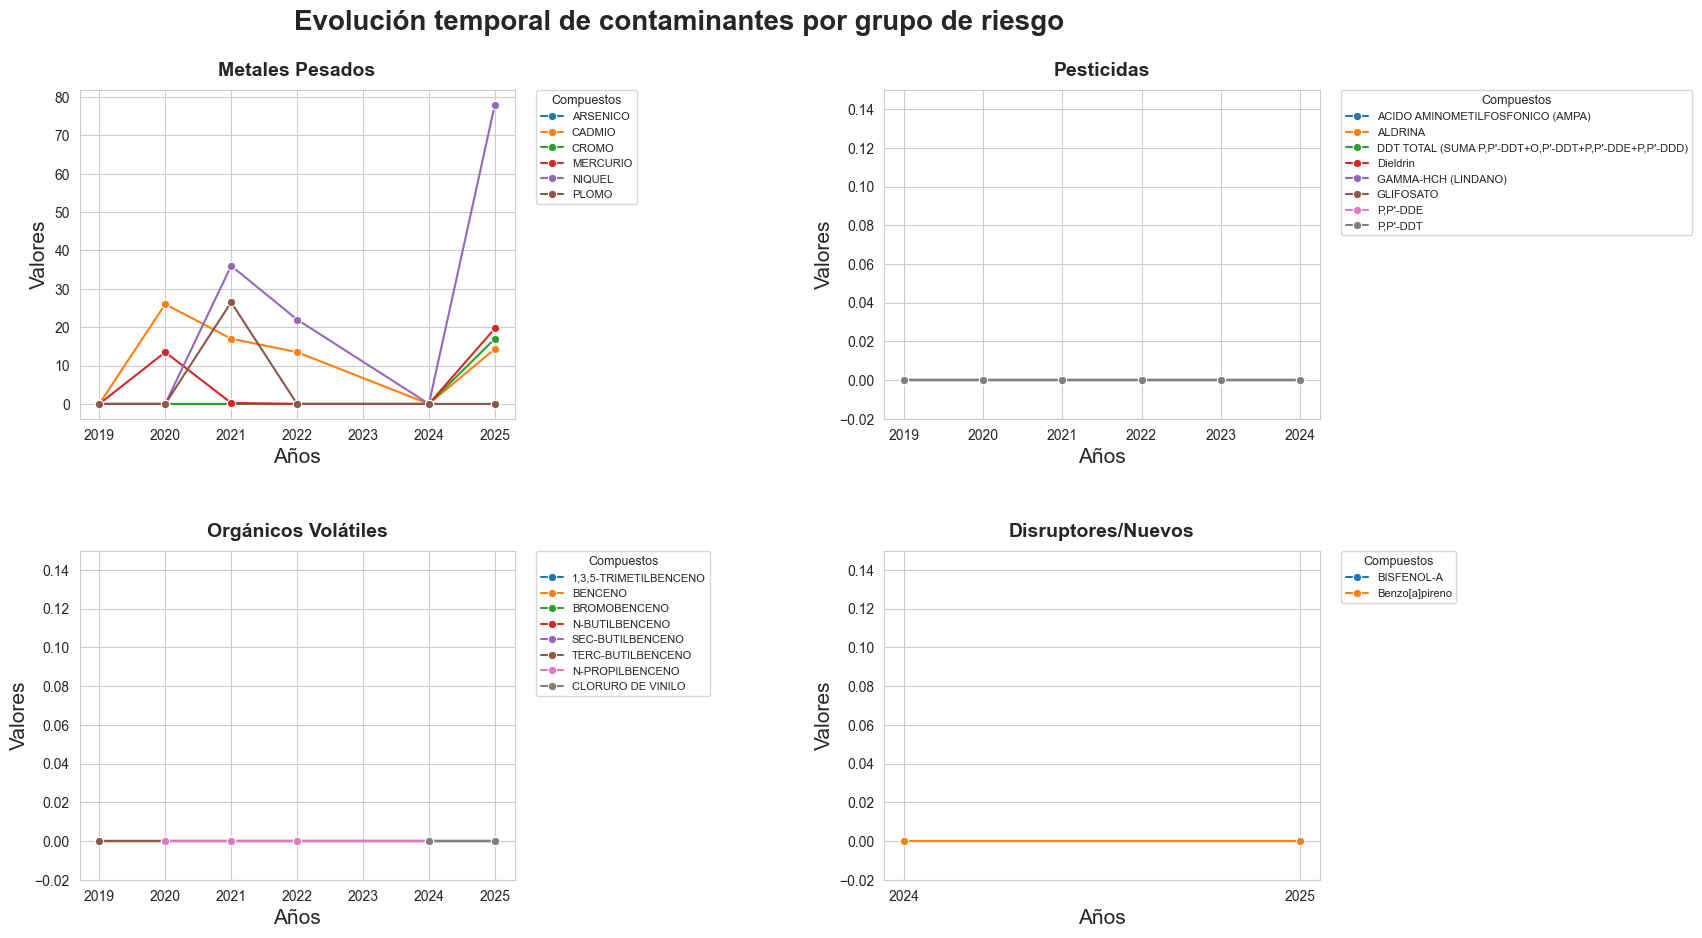

In [8]:
# Preparamos un DataFrame específico para analizar solo los compuestos peligrosos, renombrando la columna de valores y limpiando los nombres
df_comp_peligrosos = df_aguas_subterraneas.copy()

# Agrupamos compuestos por familias químicas para un análisis comparativo estructurado
categorias_peligro = {
    'Metales Pesados': ['MERCURIO', 'CADMIO', 'PLOMO', 'ARSENICO', 'CROMO', 'NIQUEL'],
    'Pesticidas': ['GAMMA-HCH (LINDANO)', 'ALDRINA', 'Dieldrin', 'GLIFOSATO', 'AMPA', "P,P'-DDT", "P,P'-DDE"],
    'Orgánicos Volátiles': ['BENCENO', 'CLORURO DE VINILO', 'TETRACLOROETILENO', 'TRICLOROETILENO'],
    'Disruptores/Nuevos': ['BISFENOL-A', 'Benzo[a]pireno']
}

# Cast de la columna Fecha a objeto datetime y extracción del componente anual
df_comp_peligrosos['Fecha Toma'] = pd.to_datetime(df_comp_peligrosos['Fecha Toma'], dayfirst=True, errors='coerce')
df_comp_peligrosos['Año'] = df_comp_peligrosos['Fecha Toma'].dt.year

def asignar_categoria(nombre):
    for cat, lista in categorias_peligro.items():
        if any(x in str(nombre) for x in lista): return cat
    return None

# Aplicamos la categorización y eliminamos registros nulos o incompletos
df_comp_peligrosos['Grupo Riesgo'] = df_comp_peligrosos['Nom. Parametro'].apply(asignar_categoria)
df_final = df_comp_peligrosos.dropna(subset=['Grupo Riesgo', 'Año', 'Valor'])

# Agregación de datos: calculamos la concentración media anual por compuesto y grupo
df_auxiliar = df_final.groupby(['Año', 'Grupo Riesgo', 'Nom. Parametro'])['Valor'].mean().reset_index()

sns.set_style("whitegrid")
# Creamos una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # Aplanamos la matriz de ejes para iterar fácilmente (0,1,2,3)

grupos = list(categorias_peligro.keys())

for i, grupo in enumerate(grupos):
    ax = axes[i]
    # Filtramos datos solo para el grupo actual
    data_grupo = df_auxiliar[df_auxiliar['Grupo Riesgo'] == grupo]
    
    # Dibujamos las líneas en el subplot correspondiente
    sns.lineplot(data=data_grupo, x='Año', y='Valor', hue='Nom. Parametro', 
                 marker='o', markersize=6, linewidth=1.5, ax=ax, palette="tab10")
    
    # Formateo de títulos y etiquetas
    ax.set_title(grupo, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel("Años", fontsize=15)
    ax.set_ylabel("Valores", fontsize=15)
    
    # Configuración de leyenda: La movemos fuera a la derecha de cada subplot
    ax.legend(title="Compuestos", fontsize=8, title_fontsize=9, 
              bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    # Tratamiento de valores nulos/bajos para evitar que la gráfica colapse
    curr_ylim = ax.get_ylim()
    if curr_ylim[1] < 0.1:
        ax.set_ylim(-0.02, 0.15)
        
    # Aseguramos años enteros en el eje X
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Ajustes finales de layout para evitar el solapamiento
# wspace=0.8 es fundamental para que quepan las leyendas entre columnas
plt.subplots_adjust(top=0.90, hspace=0.4, wspace=0.85)
fig.suptitle('Evolución temporal de contaminantes por grupo de riesgo', fontsize=20, fontweight='bold')

plt.show()

En primer lugar, podemos notar que para la gráficas de *Pesticidas*, *Orgánicos Volátiles* y *Disruptures/Nuevos* todos los valores de los que tienen registros son 0. Esta es una muy buena noticia, pues no se presentan estos compuestos tan peligrosos para el ser humano en las aguas subterráneas de Torrevieja.

Sin embargo, si nos fijamos en los *Metales Pesados*, sí que aparecen en las tomas de aguas subterráneas. Por tanto, mostremos la serie temporal de estos compuestos para ver su evolución a lo largo de las diferentes tomas.

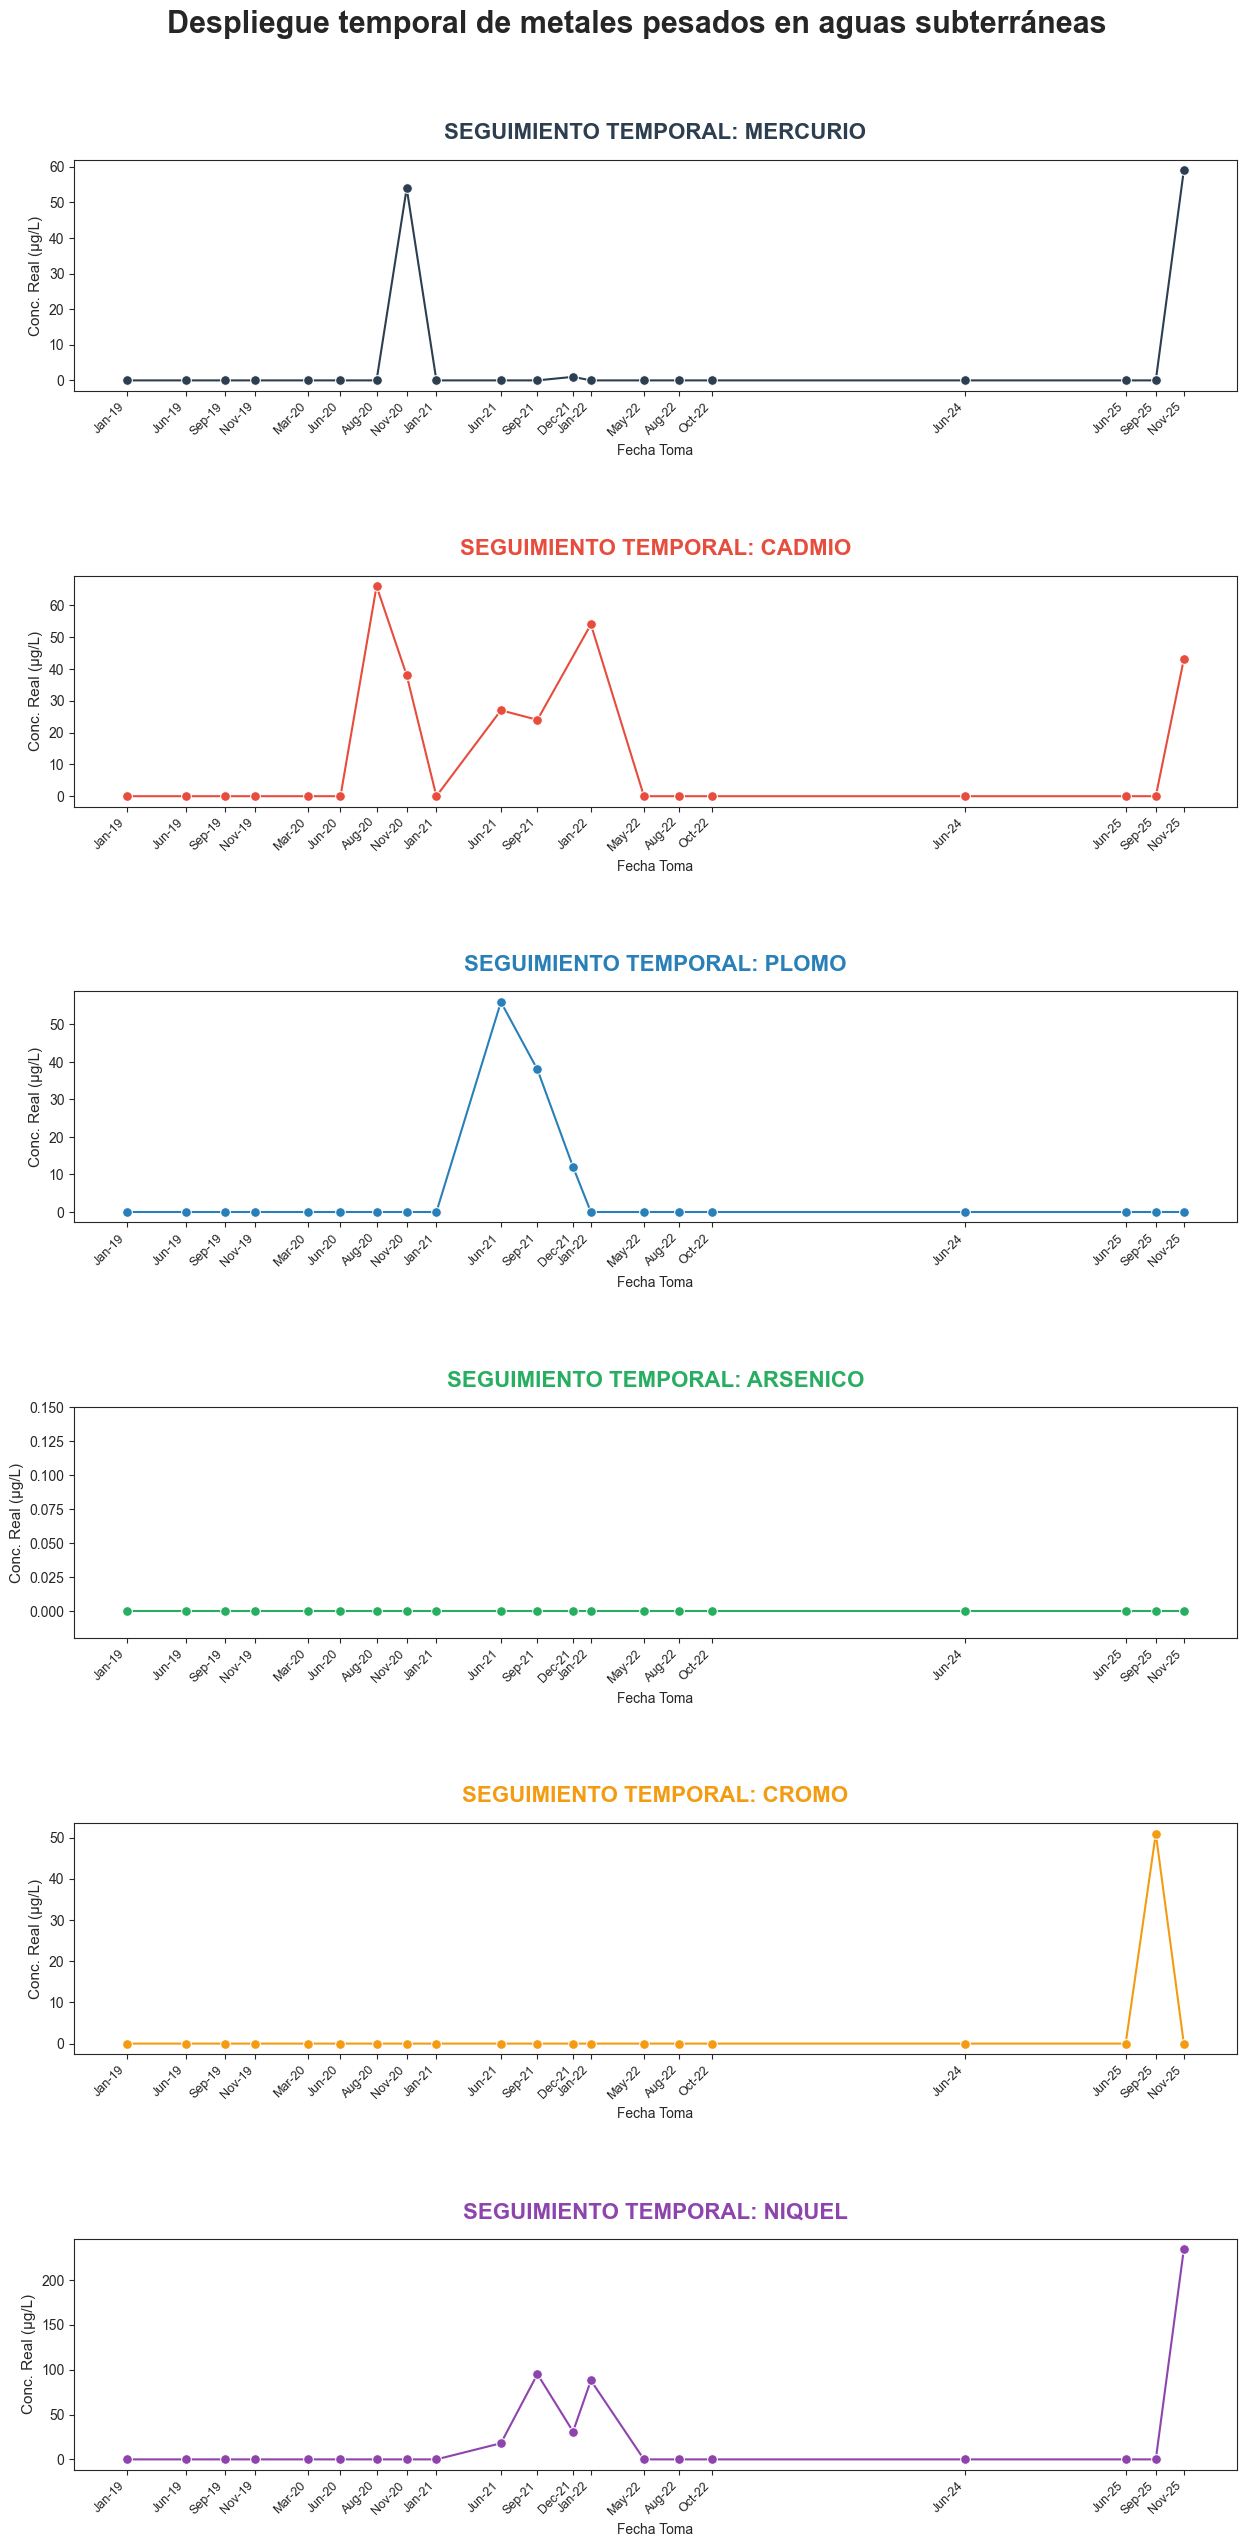

In [9]:
# Definimos la lista de contaminantes específicos (Metales Pesados) para filtrar el dataset
lista_metales = ['MERCURIO', 'CADMIO', 'PLOMO', 'ARSENICO', 'CROMO', 'NIQUEL']

# Creamos una copia del DataFrame original para preservar la integridad de los datos fuente
df_auxiliar = df_aguas_subterraneas.copy() 

# Eliminamos registros que no tengan fecha o valor numérico, ya que no aportan información a la serie
df_auxiliar = df_auxiliar.dropna(subset=['Fecha Toma', 'Valor'])

# Filtramos el DataFrame para trabajar exclusivamente con los metales pesados definidos arriba
df_auxiliar = df_auxiliar[df_auxiliar['Nom. Parametro'].isin(lista_metales)].copy()

# Ordenamos los datos cronológicamente para que las líneas de tendencia sigan una secuencia temporal lógica
df_auxiliar = df_auxiliar.sort_values('Fecha Toma')

# Establecemos un estilo visual de "marcas" (ticks) para un acabado más técnico y limpio
sns.set_style("ticks")

# Creamos una cuadrícula vertical de 6 filas (una para cada metal) y 1 columna
# Se define un tamaño de 15x30 para dar suficiente espacio vertical a cada serie
fig, axes = plt.subplots(6, 1, figsize=(15, 30))

# Paleta de colores personalizada para asignar una identidad visual única a cada metal
colores = ['#2c3e50', '#e74c3c', '#2980b9', '#27ae60', '#f39c12', '#8e44ad']

# Graficamos los subplots
for i, metal in enumerate(lista_metales):
    ax = axes[i]
    
    # Seleccionamos únicamente los registros correspondientes al metal de la iteración actual
    data_metal = df_auxiliar[df_auxiliar['Nom. Parametro'] == metal]
    
    # Dibujamos la serie temporal real (Une los puntos cronológicamente respetando los huecos sin tomas)
    sns.lineplot(data=data_metal, x='Fecha Toma', y='Valor', 
                 marker='o', markersize=7, linewidth=1.5, 
                 color=colores[i], ax=ax)
    
    # Obtenemos las fechas únicas donde existe una muestra real para este metal específico
    fechas_con_toma = data_metal['Fecha Toma'].unique()
    
    # Forzamos al eje X a colocar etiquetas 'Ticks' únicamente en los días con datos reales
    ax.set_xticks(fechas_con_toma)
    
    # Formateamos las fechas del eje X para mostrar el Mes abreviado y el Año (ej: Ene-23)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
    
    ax.set_title(f'SEGUIMIENTO TEMPORAL: {metal}', fontsize=16, fontweight='bold', color=colores[i], pad=15)
    ax.set_ylabel('Conc. Real (µg/L)', fontsize=11)
    
    # Rotamos las etiquetas del eje X (45°) para asegurar la legibilidad y evitar solapamientos
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    
    # Si los valores detectados son insignificantes (< 0.1), ajustamos el límite del eje Y 
    # para que la gráfica no se vea "aplastada" contra el suelo y sea interpretable
    curr_ylim = ax.get_ylim()
    if curr_ylim[1] < 0.1:
        ax.set_ylim(-0.02, 0.15)

# Aumentamos el espacio vertical entre subgráficas para evitar que se pisen los títulos y etiquetas
plt.subplots_adjust(hspace=0.8)

# Añadimos un título global al conjunto de gráficas para el informe final
fig.suptitle('Despliegue temporal de metales pesados en aguas subterráneas', 
             fontsize=22, fontweight='bold', y=0.93)

# Renderizamos el resultado final
plt.show()

Expliquemos cada subgráfica:

* **MERCURIO**: observamos picos en noviembre de 2020 y septiembre de 2025. 
* **CADMIO**: apreciamos picos en verano y otoño de 2020, en el verano del 2021 y 2022 y en septiembre de 2025. 
* **PLOMO**: notamos picos en la segunda mitad del año de 2021.
* **ARSÉNICO**: se observa una estabilidad general en torno al valor 0.
* **CROMO**: se aprecia un único pico en septiembre de 2025.
* **NIQUEL**: aparecen picos desde junio de 2021 hasta mayo de 2022, y un pico desorbitado en 2025.

Estos picos aislados pueden deberse a incidentes de contaminación puntuales. Sin embargo, las temporadas comprendidas por varias tomas para el **CADMIO**, el **PLOMO** y el **NIQUEL** indican temporadas amplias de contaminación. Además, resultaría muy interesante descubrir el porqué de ese pico tan pronunciado en septiembre del 25 para numerosos metales pesados.

Finalmente, graficamos las series temporales de los 15 compuestos que más aparecen en nuestro dataset para estudiar su estacionalidad y presentan patrones.

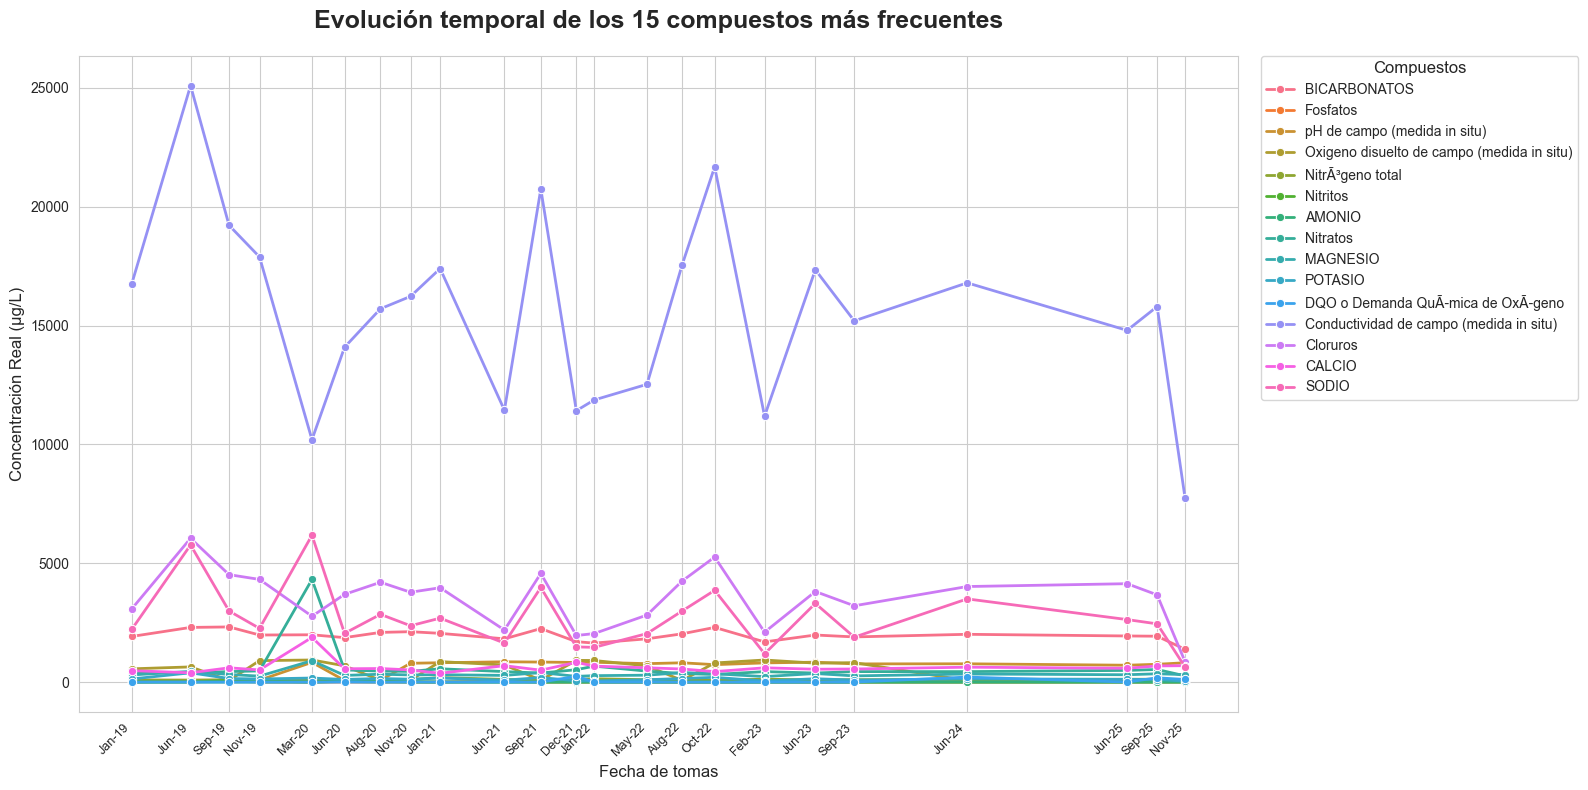

In [10]:
# Creamos una copia del DataFrame original para preservar la integridad de los datos fuente
df_top = df_aguas_subterraneas.copy()

# Filtramos registros válidos
df_top = df_top.dropna(subset=['Fecha Toma', 'Valor'])

# Identificamos el top 15 (usamos una variable distinta para la lista)
lista_top15 = df_top['Nom. Parametro'].value_counts().head(15).index.tolist()

# Filtramos el DataFrame usando la lista y ordenamos
df_top = df_top[df_top['Nom. Parametro'].isin(lista_top15)].copy()
df_top = df_top.sort_values('Fecha Toma')

# Graficamos
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))

# Dibujamos todas las líneas
plot = sns.lineplot(data=df_top, x='Fecha Toma', y='Valor', hue='Nom. Parametro', 
                    marker='o', markersize=6, linewidth=2, palette="husl")

fechas_totales = df_top['Fecha Toma'].unique()

# Marcamos solo los meses con actividad real
plt.xticks(fechas_totales)
plot.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.xticks(rotation=45, ha='right', fontsize=9)

plt.title('Evolución temporal de los 15 compuestos más frecuentes', 
          fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Concentración Real (µg/L)', fontsize=12)
plt.xlabel('Fecha de tomas', fontsize=12)

plt.legend(title="Compuestos", bbox_to_anchor=(1.02, 1), loc='upper left', 
           borderaxespad=0, fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

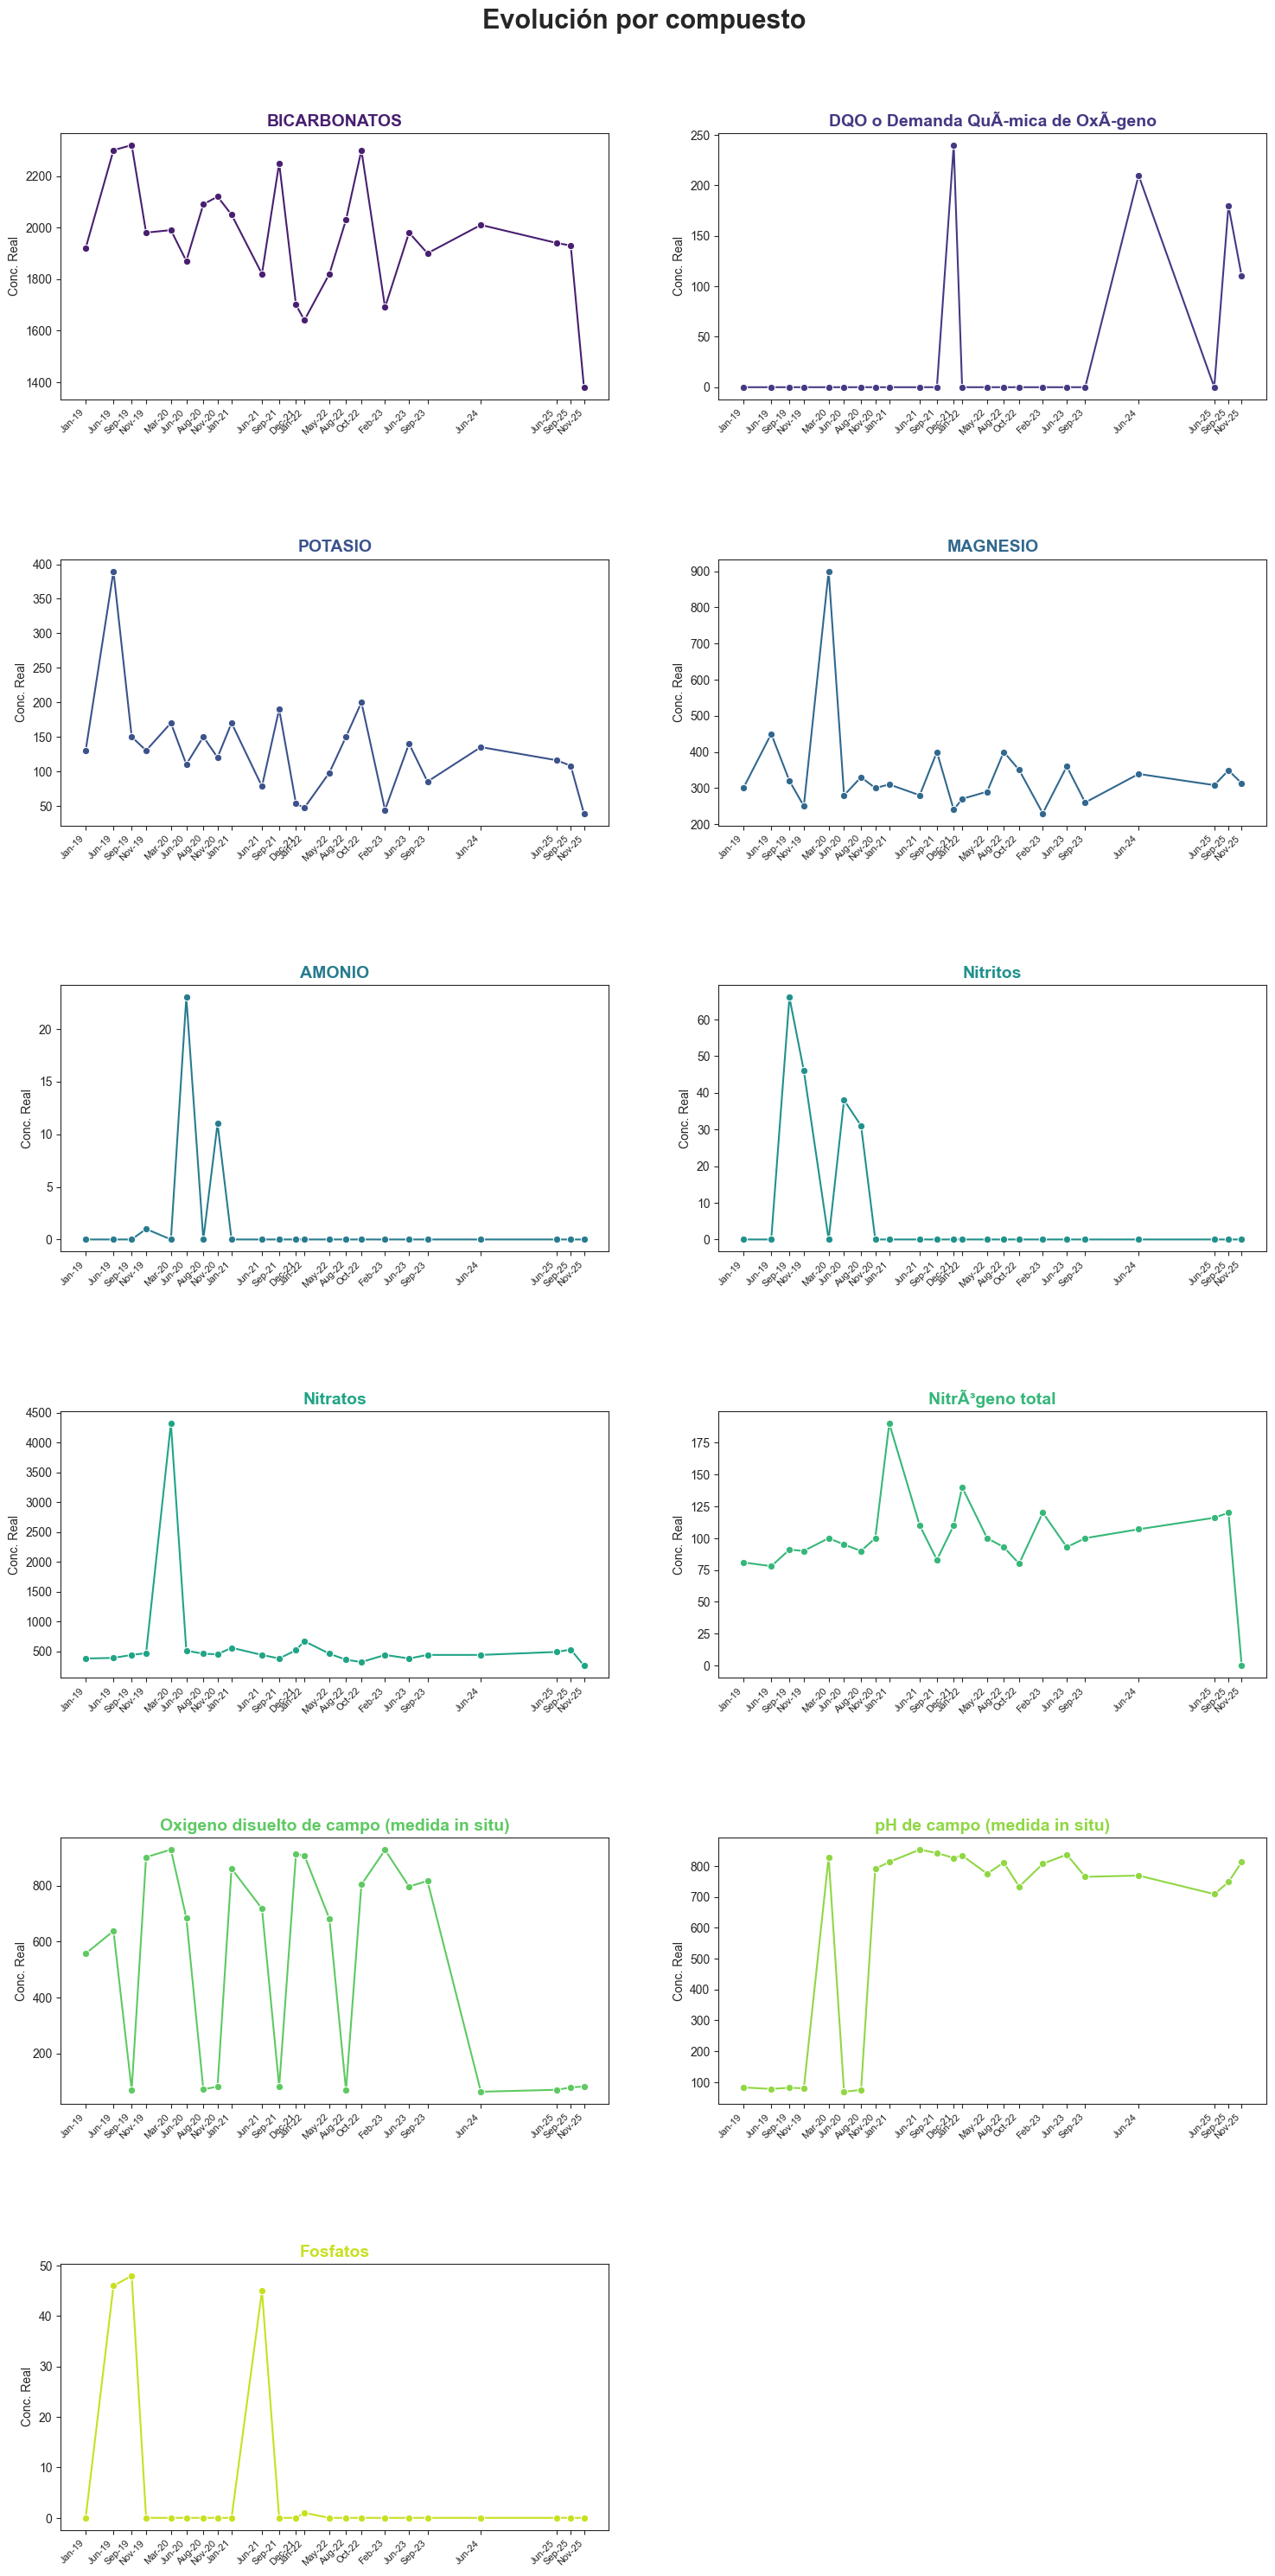

In [11]:
df_detalle = df_aguas_subterraneas.copy()

# Identificamos el Top 15 original
top_15_nombres = df_detalle['Nom. Parametro'].value_counts().head(15).index.tolist()

# Lista de compuestos a excluir, pues se ven bien en la gráfica general
excluir = ['Conductividad de campo (medida in situ)', 'Cloruros', 'SODIO', 'CALCIO']
lista_estudio = [c for c in top_15_nombres if c not in excluir]

# Filtramos y ordenamos cronológicamente
df_final = df_detalle[df_detalle['Nom. Parametro'].isin(lista_estudio)].copy()
df_final = df_final.dropna(subset=['Fecha Toma', 'Valor'])
df_final = df_final.sort_values('Fecha Toma')

sns.set_style("ticks")

num_graficas = len(lista_estudio)
columnas = 2
filas = math.ceil(num_graficas / columnas) # Calcula cuántas filas necesitamos

# Creamos la figura con la nueva cuadrícula
fig, axes = plt.subplots(filas, columnas, figsize=(18, filas * 6))

# Aplanamos los ejes para poder iterar sobre ellos fácilmente (1D en lugar de 2D)
axes_flat = axes.flatten()

# Paleta de colores
colores = sns.color_palette("viridis", num_graficas)

for i, compuesto in enumerate(lista_estudio):
    ax = axes_flat[i]
    data_comp = df_final[df_final['Nom. Parametro'] == compuesto]
    
    # Dibujamos la serie temporal
    sns.lineplot(data=data_comp, x='Fecha Toma', y='Valor', 
                 marker='o', markersize=6, linewidth=1.5, 
                 color=colores[i], ax=ax)
    
    # Configuración Eje X: Meses reales
    fechas_reales = data_comp['Fecha Toma'].unique()
    ax.set_xticks(fechas_reales)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
    
    # Estética de cada subplot
    ax.set_title(f'{compuesto}', fontsize=14, fontweight='bold', color=colores[i])
    ax.set_ylabel('Conc. Real', fontsize=10)
    ax.set_xlabel('', fontsize=9) # Quitamos etiqueta X para no recargar
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    
    # Ajuste de escala para valores mínimos
    if not data_comp.empty and data_comp['Valor'].max() < 0.1:
        ax.set_ylim(-0.01, 0.15)

# Ocultamos los subplots vacíos (si el número de gráficas es impar)
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])
    
plt.subplots_adjust(hspace=0.6, wspace=0.2)
fig.suptitle('Evolución por compuesto', 
             fontsize=22, fontweight='bold', y=0.92)

plt.show()

A partir de esta gráfica podemos sacar las siguientes conclusiones:

* La *Conductividad de campo* es la línea que está por encima de todas. Mide la capacidad del agua para conducir electricidad, lo cual depende directamente de la cantidad de sales disueltas. Valores por encima de 2.500 ya se consideran agua salobre (agua con una salinidad entre el agua dulce y el agua de mar). Estar en torno a valores de 20.000 puede ser señal de filtraciones de agua marina o un acuífero extremadamente salinizado.

* Observamos que les siguen en cuanto a valores los *Cloruros*, el *SODIO* y el *CALCIO*. Se mueven en el rango de 2.000 a 6.000 $\mu g/L$. Los *Cloruros* y el *SODIO* se mueven casi en paralelo. Sus altos valores podrían ratificar las ocurrencias de momentos en que el agua del mar está filtrándose en las aguas subterráneas debido a la sobreexplotación de los pozos o la proximidad a las salinas. En cuanto al *CALCIO*, proviene de la erosión de las rocas calizas y su presencia alta indica que es un agua con mucha cal.

* El resto de compuestos presentan unos valores muy por debajo, sus concentraciones son mínimas comparadas con las sales. Esto nos hace pensar que, aunque hay presencia de actividad agrícola (como el uso de abonos para la tierra) al haber valores positivos de *Nitratos* y derivados y *BICARBONATOS*, el problema principal de este acuífero no es la toxicidad por abonos, sino la salinidad.

* Ya a nivel de patrones, apreciamos una tendencia creciente en los valores de los compuestos para las épocas de verano (especialmente en junio) y en noviembre. Los repuntes en noviembre podrían estar ligados al lavado de sales y fertilizantes del suelo tras las primeras lluvias otoñales, que arrastran estos compuestos hacia el acuífero.

* Finalmente, cabe destacar el comportamiento de parámetros de estado como el *Oxígeno disuelto* y el *pH*, que presentan una gran inestabilidad estacional. Las caídas bruscas de oxígeno en periodos donde aumentan los *Nitritos* y el *Amonio* (como se observa en el detalle de 2020) sugieren episodios puntuales de eutrofización o carga orgánica reciente que consume el oxígeno disponible en el agua, afectando gravemente su calidad biológica.

No obstante, sería interesante analizar las condiciones climáticas en el momento de las tomas, o unos días antes, para ver si pudiera haber alguna situación climática que las explicase.

<!-- A partir de esta gráfica podemos sacar las siguientes conclusiones:

* La *Conductividad de campo* es la línea que está por encima de todas. Mide la capacidad del agua para conducir electricidad, lo cual depende directamente de la cantidad de sales disueltas. Valores por encima de 2.500 ya se consideran agua salobre (agua con una salinidad entre el agua dulce y el agua de mar). Estar en torno a valores de 20.000 puede ser señal de filtraciones de agua marina o un acuífero extremadamente salinizado.

* Observamos que les siguen en cuanto a valores los *Cloruros*, el *SODIO* y el *CALCIO*. Se mueven en el rango de 2.000 a 6.000 $\mu g/L$. Los *Cloruros* y el *SODIO* se mueven casi en paralelo. Sus altos valores podrían ratificar las ocurrencias de momentos en que el agua del mar está filtrándose en las aguas subterráneas debido a la sobreexplotación de los pozos o la proximidad a las salinas. En cuanto al *CALCIO*, proviene de la erosión de las rocas calizas y su presencia alta indica que es un agua con mucha cal.

* El resto de compuestos presentan unos valores muy por debajo, sus concentraciones son mínimas comparadas con las sales. Esto nos hace pensar que, aunque hay presencia de actividad agrícola (como el uso de abonos para la tierra) al haber valores positivos de *Nitratos* y derivados y *BICARBONATOS*, el problema principal de este acuífero no es la toxicidad por abonos, sino la salinidad.

* Ya a nivel de patrones, apreciamos una tendencia creciente en los valores de los compuestos para las épocas de verano (especialmente en junio) y en noviembre. Los repuntes en noviembre podrían estar ligados al lavado de sales y fertilizantes del suelo tras las primeras lluvias otoñales, que arrastran estos compuestos hacia el acuífero.

* Finalmente, cabe destacar el comportamiento de parámetros de estado como el *Oxígeno disuelto* y el *pH*, que presentan una gran inestabilidad estacional. Las caídas bruscas de oxígeno en periodos donde aumentan los *Nitritos* y el *Amonio* (como se observa en el detalle de 2020) sugieren episodios puntuales de eutrofización o carga orgánica reciente que consume el oxígeno disponible en el agua, afectando gravemente su calidad biológica.

No obstante, sería interesante analizar las condiciones climáticas en el momento de las tomas, o unos días antes, para ver si pudiera haber alguna situación climática que las explicase. -->

#### 2.1.2 Calidad del agua de baño

Al acceder al enlace de estos datos, debemos realizar las siguientes selecciones:

* CCAA: *Comunidad Valenciana*
* Provincia: *Alicante/Alacant*
* Municipio: *Torrevieja*

Ahora, elegimos cualquiera de las playas de Torrevieja que nos aparecen, por ejemplo, *PLAYA CALA DE LAS PITERAS*. Pulsamos *Muestros* para ver las diferentes tomas de muestras que se realizaron. Ahí aparecen los datos que queremos recolectar. Para ello, haremos *Web Scraping*. En este caso, las urls de los *Muestros* de cada playa son los mismo, por lo que necesitamos un código de identificación para cada playa.

Para identificar el código de la zona de la playa (*codZona*) dentro de la página web del Sistema de Información Nacional de Aguas de Baño, primero abrimos el HTML que contiene la información detallada de cada playa en *Localizacion*. En cada documento HTML se encuentran varias secciones, como la localización, características de la zona, puntos de muestreo y enlaces a mapas o perfiles ambientales. La información está organizada dentro de formularios HTML (`<form>`), que incluyen campos ocultos (`<input type="hidden">`) para almacenar datos que se envían al servidor cuando se interactúa con la página.

Dentro del formulario principal, llamado *ciudadanoZonaForm*, se encuentran múltiples campos ocultos que guardan datos importantes sobre la playa. Entre ellos, el campo `<input type="hidden" name="codZona" value="numero">` es el que nos da directamente el código de la zona. Este valor cambia dependiendo de la playa que estemos visualizando. Por ejemplo, para Playa Los Náufragos el valor de *codZona* es 844, mientras que para Playa del Cura era 843. Este código es clave porque permite al sistema identificar de forma única cada zona de baño en las solicitudes posteriores, como descargar el perfil ambiental o mostrar mapas SIGPAC.

Los *codZona* para cada una de las playas son:

* *PLAYA CALA DE LAS PITERAS*: 1786
* *PLAYA DE CABO CERBERA*: 845
* *PLAYA DE CALA MAR AZUL*: 1785
* *PLAYA DE LA MATA*: 2279
* *PLAYA DE LAS PISCINAS DEL PASEO*: 846
* *PLAYA DE LOS LOCOS*: 842
* *PLAYA DE TORRELAMATA*: 841
* *PLAYA DEL CURA*: 843
* *PLAYA LOS NAUFRAGOS*: 844

Una vez conocidos los códigos que identifican las 9 playas de Torrevieja, nos disponemos a realizar *Web Scraping* para ingestar los datos.

In [ ]:
# Creamos una lista de diccionarios que asocia el nombre legible de la playa 
# con su identificador interno ('codZona') requerido por la base de datos de NÁYADE.
playas = [
    {"nombre": "PLAYA DE CABO CERBERA", "codZona": "845"},
    {"nombre": "PLAYA DE CALA MAR AZUL", "codZona": "1785"},
    {"nombre": "PLAYA DE LA MATA", "codZona": "2279"},
    {"nombre": "PLAYA DE LAS PISCINAS DEL PASEO", "codZona": "846"},
    {"nombre": "PLAYA DE LOS LOCOS", "codZona": "842"},
    {"nombre": "PLAYA DE TORRELAMATA", "codZona": "841"},
    {"nombre": "PLAYA DEL CURA", "codZona": "843"},
    {"nombre": "PLAYA LOS NAUFRAGOS", "codZona": "844"},
    {"nombre": "CALA DE LAS PITERAS", "codZona": "1786"}
]

# URL donde el servidor de Sanidad procesa las peticiones POST de los ciudadanos.
url = "https://nayadeciudadano.sanidad.gob.es/Splayas/ciudadano/ciudadanoVerZonaAction.do"

# Usamos Session() para mantener cookies si fuera necesario y optimizar la conexión.
session = requests.Session()

# El 'User-Agent' simula un navegador real (Chrome) para evitar que el servidor 
# bloquee la petición al identificarla como un script automatizado (bot).
session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
})

# Lista global donde acumularemos las filas de datos de todas las playas.
todos_datos = []

# Bucle de extración (Scraping) por playa
for playa in playas:
    # El 'payload' contiene los parámetros ocultos del formulario. 
    # 'pestanya': '3' indica al servidor que queremos los datos de "Muestreos".
    payload = {
        'pestanya': '3', 
        'actionProcedencia': 'ciudadanoListaZonaAction',
        'codZona': playa["codZona"],
        'codCCAA': '10',      # Código para C. Valenciana
        'codProvincia': '3',   # Código para Alicante
        'codMunicipio': '3133', # Código para Torrevieja
        'provinciaMapa': '',
        'denZona': '',
        'codPlaya': ''
    }

    try:
        # Enviamos la petición POST con los datos del formulario
        response = session.post(url, data=payload)
        response.raise_for_status() # Lanza error si la web no responde (404, 500, etc.)

        # Parseamos el contenido HTML con BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Localizamos todas las celdas de la tabla que contienen los valores de interés.
        # En esta web, los datos están en etiquetas <td> con la clase 'valorCampoI'.
        celdas = soup.find_all('td', class_='valorCampoI')

        # La tabla es plana, así que agrupamos las celdas de 4 en 4.
        # Estructura original: [Fecha] [E.Coli] [Enterococo] [Estado/Observaciones]
        datos_limpios = []
        for i in range(0, len(celdas), 4):
            # Extraemos el texto limpio (strip=True elimina espacios y saltos de línea)
            fila = [c.get_text(strip=True) for c in celdas[i:i+4]]
            
            # Si la fila tiene los 4 campos, le añadimos el nombre de la playa al principio
            if len(fila) == 4:
                fila.insert(0, playa["nombre"]) 
                datos_limpios.append(fila)

        # Añadimos los datos de esta playa a la lista maestra
        todos_datos.extend(datos_limpios)
    except Exception as e:
        # Captura errores de conexión o cambios en la estructura de la web
        print(f"❌ Error al conectar con {playa['nombre']}: {e}")

# Definimos los nombres de las columnas para el DataFrame de Pandas
columnas = ["Playa", "Fecha", "E_Coli", "Enterococo", "Estado"]
df = pd.DataFrame(todos_datos, columns=columnas)

# Exportamos a CSV. 
# - encoding='utf-8-sig' asegura que Excel reconozca tildes y eñes correctamente.
# - sep=';' es el separador estándar para CSV en configuraciones españolas de Excel.
df.to_csv("Calidad_aguas_playas.csv", index=False, encoding='utf-8-sig', sep=';')

print("✅ Archivo 'Calidad_aguas_playas.csv' generado con éxito.")

✅ Archivo 'Calidad_aguas_playas.csv' generado con éxito.


In [12]:
df_calidad_playas = pd.read_csv('../DATASETS/RETO 4/DATASETS ORIGINALES/Calidad_aguas_playas.csv', encoding="latin-1", sep=";")
df_calidad_playas.head()

,ï»¿Playa,Fecha,E_Coli,Enterococo,Estado
0,PLAYA DE CALA MAR AZUL,09/09/2025,1 UFC/100 mL,20 NMP/100 mL,Zona Apta para el baÃ±o
1,PLAYA DE CALA MAR AZUL,02/09/2025,5 UFC/100 mL,10 NMP/100 mL,Zona Apta para el baÃ±o
2,PLAYA DE CALA MAR AZUL,26/08/2025,1 UFC/100 mL,10 NMP/100 mL,Zona Apta para el baÃ±o
3,PLAYA DE CALA MAR AZUL,19/08/2025,4 UFC/100 mL,1 NMP/100 mL,Zona Apta para el baÃ±o
4,PLAYA DE CALA MAR AZUL,12/08/2025,1 UFC/100 mL,1 NMP/100 mL,Zona Apta para el baÃ±o


Como preprocesamiento, realizamos las siguientes acciones:

* **Corrección de encoding**: eliminamos los caracteres extraños `ï»¿` del nombre de la columna *Playa*. Estos caracteres aparecen cuando un archivo CSV se guarda con una codificación BOM (Byte Order Mark) y Python no la reconoce automáticamente.
* **Normalización de texto**: corregimos errores de interpretación de caracteres especiales (como convertir `baÃ±o` en `baño`).
* **Limpieza de cadenas**: usamos expresiones regulares (`str.extract('(\d+)')`) para buscar únicamente los dígitos dentro de las celdas de bacterias y descartar el texto. También, los transformamos de tipo *Objeto* a tipo *float*.
* **Renombrado de columnas**: movemos la unidad de medida del cuerpo de los datos al encabezado: *E_Coli (UFC/100 mL)* y *Enterococo (NMP/100 mL)*.
* **Conversión a datetime**: pasamos la columna *Fecha* de ser un texto a ser un objeto de tipo *datetime64*.
* **Uso de errors='coerce'**: al convertir las fechas, configuramos el código para que, si encuentra algún dato corrupto o imposible de leer, no detenga el programa, sino que marque ese valor como `NaT`, permitiéndote limpiar o ignorar esos registros específicos después.

In [13]:
# Corregimos el nombre de la columna 'Playa'
df_calidad_playas.columns = [c.replace('ï»¿', '') for c in df_calidad_playas.columns]

# Limpiamos E_Coli
df_calidad_playas['E_Coli'] = df_calidad_playas['E_Coli'].str.extract('(\d+)').astype(float)
df_calidad_playas.rename(columns={'E_Coli': 'E_Coli (UFC/100 mL)'}, inplace=True)

# Limpiamos Enterococo
df_calidad_playas['Enterococo'] = df_calidad_playas['Enterococo'].str.extract('(\d+)').astype(float)
df_calidad_playas.rename(columns={'Enterococo': 'Enterococo (NMP/100 mL)'}, inplace=True)

# Corregimos texto del Estado
df_calidad_playas['Estado'] = df_calidad_playas['Estado'].str.replace('baÃ±o', 'baño')

# CONVERSIÓN DE FECHA CORREGIDA (%Y en lugar de %s)
# Usamos 'coerce' para que si algo falla ponga NaT en vez de romper el código
df_calidad_playas['Fecha'] = pd.to_datetime(df_calidad_playas['Fecha'], format='%d/%m/%Y', errors='coerce')

# Guardamos el dataset modificado
df_calidad_playas.to_csv(
    '../DATASETS/RETO 4/DATASETS MODIFICADOS/Calidad_playas_MOD.csv', 
    index=False, 
    sep=";", 
    encoding="latin-1"
)

A continuación, comenzamos con un exploratorio básico de los datos.

In [14]:
print("=== 1. PRIMERAS FILAS DEL DATASET ===")
display(df_calidad_playas.head())

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_calidad_playas.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_calidad_playas.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_calidad_playas.duplicated().sum()}\n")

=== 1. PRIMERAS FILAS DEL DATASET ===


,Playa,Fecha,E_Coli (UFC/100 mL),Enterococo (NMP/100 mL),Estado
0,PLAYA DE CALA MAR AZUL,2025-09-09,1.0,20.0,Zona Apta para el baño
1,PLAYA DE CALA MAR AZUL,2025-09-02,5.0,10.0,Zona Apta para el baño
2,PLAYA DE CALA MAR AZUL,2025-08-26,1.0,10.0,Zona Apta para el baño
3,PLAYA DE CALA MAR AZUL,2025-08-19,4.0,1.0,Zona Apta para el baño
4,PLAYA DE CALA MAR AZUL,2025-08-12,1.0,1.0,Zona Apta para el baño



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Playa                    345 non-null    str           
 1   Fecha                    345 non-null    datetime64[us]
 2   E_Coli (UFC/100 mL)      345 non-null    float64       
 3   Enterococo (NMP/100 mL)  345 non-null    float64       
 4   Estado                   345 non-null    str           
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 13.6 KB

=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===
Playa                      0
Fecha                      0
E_Coli (UFC/100 mL)        0
Enterococo (NMP/100 mL)    0
Estado                     0
dtype: int64

Número de filas exactamente iguales (duplicadas): 0



Las variables con las que contamos son:

1. *Playa*: playa en la que se toman las muestras.
2. *Fecha*: fecha exacta en la que se toman las muestras de agua.
3. *E_Coli (UFC/100 mL)*: concentración de la bacteria Escherichia coli. Es un indicador primario de contaminación fecal. Niveles altos suelen ocurrir tras lluvias intensas (arrastre de alcantarillado) o fallos en depuradoras.
4. *Enterococo (NMP/100 mL)*: concentración de bacterias del grupo de los Enterococos intestinales. Los Enterococos sobreviven más tiempo en el agua salada. Por eso, son el mejor indicador para detectar contaminación antigua o persistente en el mar.
5. *Estado*: la calificación sanitaria simplificada. En todas las muestras, el estado es *Zona Apta para el baño*.

Observamos que no tenemos valores vacíos en los datos ni filas duplicadas.

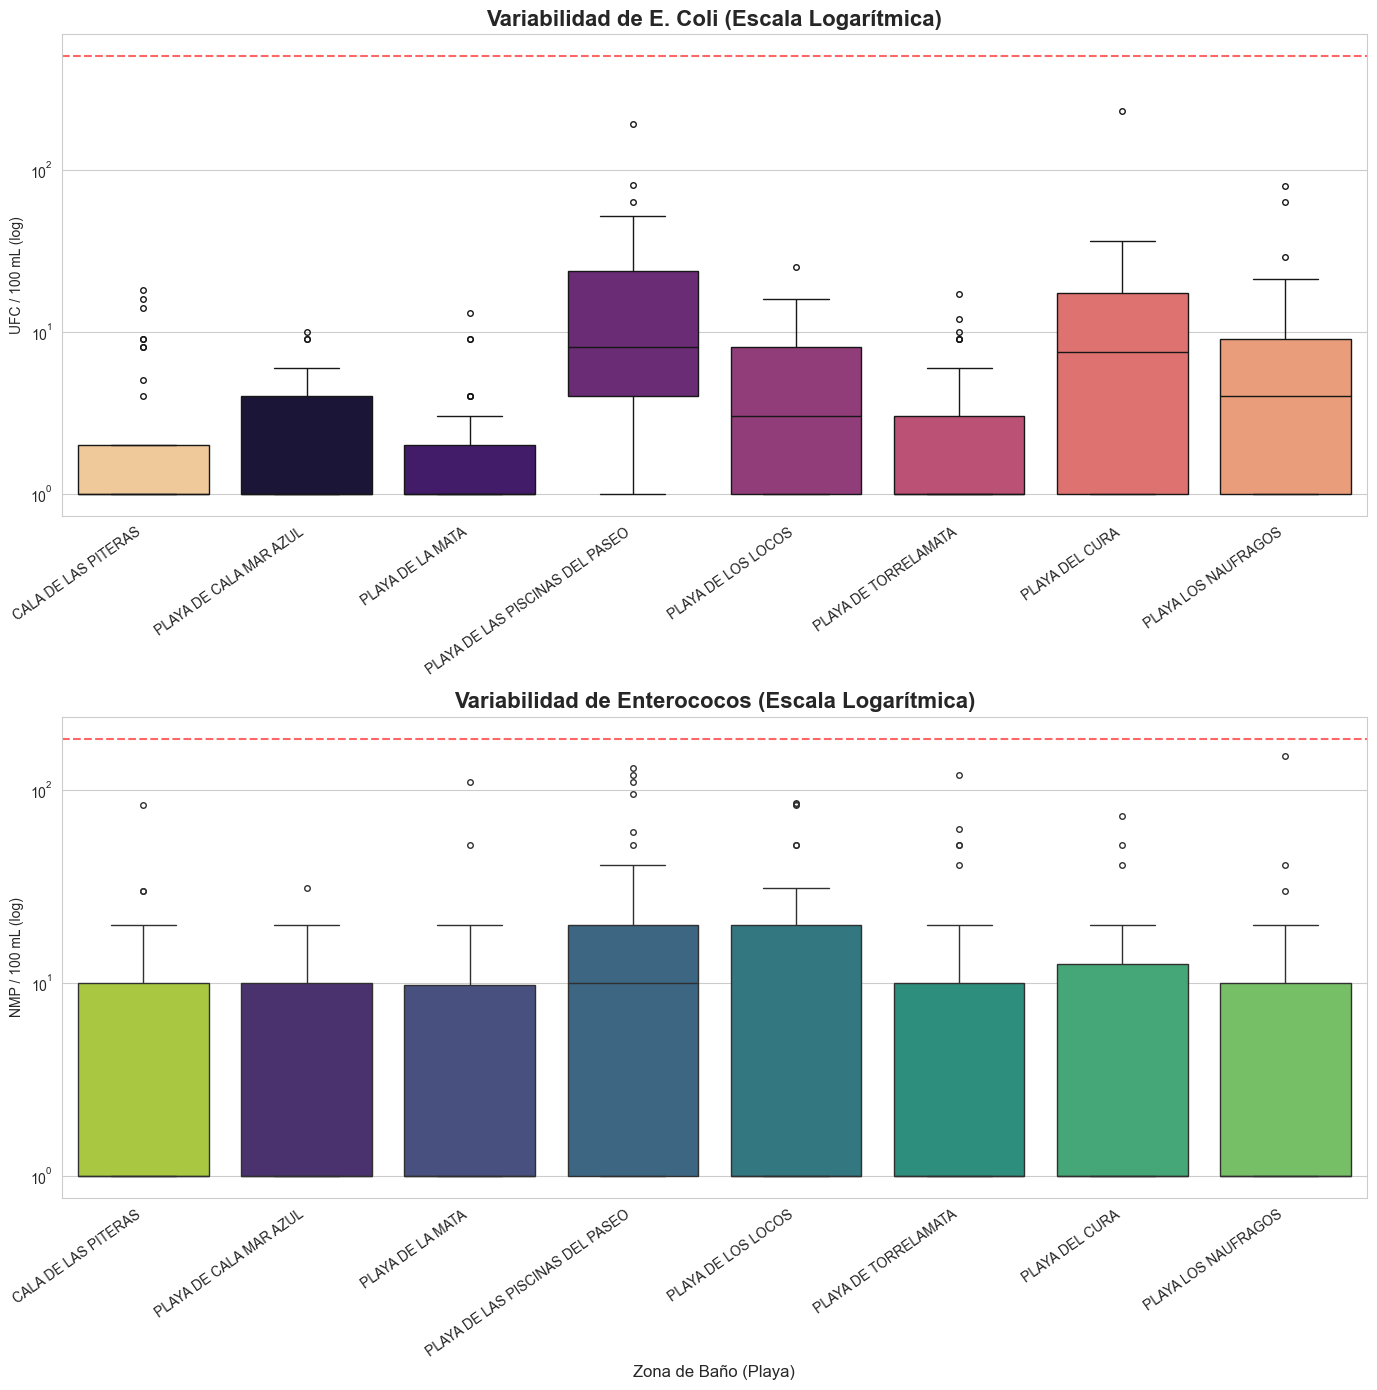

In [16]:
# Configuración de estilo y creación de la figura
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Obtenemos la lista de playas ordenada para que ambos gráficos coincidan
orden_playas = sorted(df_calidad_playas['Playa'].unique())

# --- BOXPLOT PARA E. COLI ---
sns.boxplot(data=df_calidad_playas, x='Playa', y='E_Coli (UFC/100 mL)', 
            ax=axes[0], hue='Playa', palette='magma', 
            order=orden_playas, legend=False, fliersize=4)

# Añadimos línea de límite para Calidad Excelente (aprox. 500 UFC)
axes[0].axhline(500, color='red', linestyle='--', alpha=0.6, label='Límite Calidad')
axes[0].set_yscale('log') # Escala logarítmica para ver mejor las cajas bajas

axes[0].set_title('Variabilidad de E. Coli (Escala Logarítmica)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('UFC / 100 mL (log)')
axes[0].set_xlabel('') # Limpiamos para no repetir

# Ajuste de etiquetas
axes[0].set_xticks(range(len(orden_playas)))
axes[0].set_xticklabels(orden_playas, rotation=35, ha='right', fontsize=10)


# --- BOXPLOT PARA ENTEROCOCOS ---
sns.boxplot(data=df_calidad_playas, x='Playa', y='Enterococo (NMP/100 mL)', 
            ax=axes[1], hue='Playa', palette='viridis', 
            order=orden_playas, legend=False, fliersize=4)

# Añadimos línea de límite para Calidad Excelente (aprox. 185 NMP)
axes[1].axhline(185, color='red', linestyle='--', alpha=0.6)
axes[1].set_yscale('log') # Escala logarítmica

axes[1].set_title('Variabilidad de Enterococos (Escala Logarítmica)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('NMP / 100 mL (log)')
axes[1].set_xlabel('Zona de Baño (Playa)', fontsize=12)

# Ajuste de etiquetas
axes[1].set_xticks(range(len(orden_playas)))
axes[1].set_xticklabels(orden_playas, rotation=35, ha='right', fontsize=10)

# Ajustes finales de espaciado
plt.tight_layout()
plt.show()

**Límites Legales de Calidad de Aguas de Baño (Marítimas)**

*Valores de referencia por cada 100 mL de muestra según Directiva 2006/7/CE*

| Categoría | Enterococos (NMP/100mL) | E. Coli (UFC/100mL) | Interpretación |
| :--- | :--- | :--- | :--- |
| **Excelente** | < 185 | < 500 | Agua muy limpia, ideal para el baño. |
| **Buena** | 185 - 200 | 500 | Calidad aceptable. |
| **Suficiente** | 200 | 500 | Límite crítico; riesgo leve. |
| **Insuficiente** | **> 200** | **> 500** | **ALTO.** Riesgo para la salud. |

--- 

En primer lugar, observamos que la gran mayoría de los valores de ambas bacterias se sitúan en niveles bajos, claramente por debajo de los límites establecidos para una calidad *excelente* (500 UFC/100 mL para *E. coli* y 185 NMP/100 mL para Enterococos). En general, las aguas de las playas analizadas presentan una calidad microbiológica muy alta y son aptas para el baño sin riesgos significativos para la salud.

Sin embargo, también se detectan *outliers* en prácticamente todas las playas, especialmente en *Playa de las Piscinas del Paseo*, *Playa del Cura* y *Playa Los Náufragos*. Estos picos representan episodios puntuales de contaminación que, aunque no son frecuentes, pueden deberse a factores como lluvias intensas, vertidos ocasionales o problemas en los sistemas de depuración.

En el caso de *E. coli*, algunas playas presentan una mayor variabilidad (cajas más altas y dispersas), lo que indica fluctuaciones más pronunciadas en el tiempo. Destaca especialmente *Playa de las Piscinas del Paseo*, donde la mediana y el rango intercuartílico son más elevados que en el resto, sugiriendo una mayor exposición a contaminación puntual.

Por su parte, los *Enterococos* muestran una distribución más homogénea entre playas, aunque también con presencia de valores extremos que en algunos casos se aproximan o superan el umbral de calidad excelente. Dado que esta bacteria sobrevive más tiempo en agua salada, su presencia elevada puede indicar contaminación más persistente.

A pesar de estos picos aislados, es importante destacar que ninguna playa presenta una tendencia sistemática a superar los límites críticos de calidad (*insuficiente*), lo que coincide con la clasificación sanitaria observada en los datos (*Zona apta para el baño* en todos los casos).

#### 2.1.3 Afluencia de visitantes a la Laguna de la Mata y Torrevieja

Al acceder al enlace que lleva a esta sección, de todos los *datasets* nos quedamos con el que tiene por nombre *people_count.csv*. Este conjunto de datos proporciona información sobre el número de personas que visitan la Laguna de la Mata y Torrevieja durante diferentes periodos de tiempo. En concreto, el archivo contiene registros de afluencia por día, lo que nos permitirá analizar patrones de comportamiento de los visitantes y su relación con la estacionalidad y los posibles efectos derivados de la actividad turística.

In [17]:
df_lagunas = pd.read_csv('../DATASETS/RETO 4/DATASETS ORIGINALES/people_count.csv', encoding="latin-1", sep=";")
df_lagunas.head()

,ï»¿Fecha,count_in,count_out,Fecha_sin_hora,AÃ±o,Mes,Dia,Dia_semana,Hora,Minuto
0,10/09/2024 12:50,55,57,10/09/2024,2024,9,10,Martes,12,50
1,10/09/2024 12:51,55,57,10/09/2024,2024,9,10,Martes,12,51
2,10/09/2024 12:55,55,57,10/09/2024,2024,9,10,Martes,12,55
3,10/09/2024 12:56,55,57,10/09/2024,2024,9,10,Martes,12,56
4,10/09/2024 13:00,55,60,10/09/2024,2024,9,10,Martes,13,0


Como preprocesamiento, limpiamos los nombres de las columnas y eliminamos las filas duplicadas.

In [18]:
# 1. Limpieza de nombres de columnas
df_lagunas.columns = df_lagunas.columns.str.strip()

new_cols = {
    'ï»¿Fecha': 'Fecha',
    'AÃ±o': 'Anio'
}
df_lagunas.rename(columns=new_cols, inplace=True)

# 2. Limpieza de los VALORES dentro de la columna 'Dia_semana'
# Creamos un diccionario con las correcciones de caracteres extraños
dict_dias = {
    'MiÃ©rcoles': 'Miercoles',
    'SÃ¡bado': 'Sabado'
}

# Aplicamos el reemplazo en la columna específica
df_lagunas['Dia_semana'] = df_lagunas['Dia_semana'].replace(dict_dias)

# Observamos las filas duplicadas que tenemos
print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_lagunas.duplicated().sum()}\n")

# Eliminamos los duplicados y nos queda solo con la primera aparición
df_lagunas = df_lagunas.drop_duplicates().reset_index(drop=True)

# Convertimos la columna de texto a formato fecha (datetime)
df_lagunas['Fecha'] = pd.to_datetime(df_lagunas['Fecha'], format='%d/%m/%Y %H:%M')
df_lagunas['Fecha_sin_hora'] = pd.to_datetime(df_lagunas['Fecha_sin_hora'], format='%d/%m/%Y')

# Guardamos el dataset modificado
df_lagunas.to_csv(
    '../DATASETS/RETO 4/DATASETS MODIFICADOS/Lagunas_MOD.csv', 
    index=False, 
    sep=";", 
    encoding="latin-1"
)


Número de filas exactamente iguales (duplicadas): 14735



Llevamos a cabo una exploración básica de los datos.

In [19]:
print("=== 1. PRIMERAS FILAS DEL DATASET ===")
display(df_lagunas.head())

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_lagunas.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_lagunas.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_lagunas.duplicated().sum()}\n")

=== 1. PRIMERAS FILAS DEL DATASET ===


,Fecha,count_in,count_out,Fecha_sin_hora,Anio,Mes,Dia,Dia_semana,Hora,Minuto
0,2024-09-10 12:50:00,55,57,2024-09-10,2024,9,10,Martes,12,50
1,2024-09-10 12:51:00,55,57,2024-09-10,2024,9,10,Martes,12,51
2,2024-09-10 12:55:00,55,57,2024-09-10,2024,9,10,Martes,12,55
3,2024-09-10 12:56:00,55,57,2024-09-10,2024,9,10,Martes,12,56
4,2024-09-10 13:00:00,55,60,2024-09-10,2024,9,10,Martes,13,0



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 57345 entries, 0 to 57344
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Fecha           57345 non-null  datetime64[us]
 1   count_in        57345 non-null  int64         
 2   count_out       57345 non-null  int64         
 3   Fecha_sin_hora  57345 non-null  datetime64[us]
 4   Anio            57345 non-null  int64         
 5   Mes             57345 non-null  int64         
 6   Dia             57345 non-null  int64         
 7   Dia_semana      57345 non-null  str           
 8   Hora            57345 non-null  int64         
 9   Minuto          57345 non-null  int64         
dtypes: datetime64[us](2), int64(7), str(1)
memory usage: 4.4 MB

=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===
Fecha             0
count_in          0
count_out         0
Fecha_sin_hora    0
Anio              0
Mes               0
D

Las variables con las que contamos son:

1. **Fecha**: fecha y hora de la medición de la afluencia.
2. **count_in**: número de personas que entraron hasta el momento del día.
3. **count_out**: número de personas que salieron hasta el momento del día.
4. **Fecha_sin_hora**: fecha sin la información de la hora.
5. **Anio**: año de la medición.
6. **Mes**: mes de la medición.
7. **Dia**: día del mes en el que se realizó la medición.
8. **Dia_semana**: día de la semana correspondiente a la fecha de la medición.
9. **Hora**: hora exacta de la medición.
10. **Minuto**: minuto exacto de la medición.

Observamos que no tenemos valores vacíos en los datos ni filas duplicadas.

Además, creamos un *dataframe* que contenga la ocupación total de visitantes a las lagunas por días.

In [20]:
df_lagunas_dia = df_lagunas.groupby(['Anio', 'Mes', 'Dia', 'Fecha_sin_hora', 'Dia_semana'])['count_out'].max().reset_index()

# Ponemos la columna datetime como índice (indispensable para el Grouper)
df_lagunas_dia.set_index('Fecha_sin_hora', inplace=True)

# Convertimos la columna 'Dia_semana' a categórica con el orden definido
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
df_lagunas_dia['Dia_semana'] = pd.Categorical(df_lagunas_dia['Dia_semana'], 
                                              categories=orden_dias, 
                                              ordered=True)

Ahora, graficamos la distribución temporal de la ocupacion de las lagunas por día para analizar los patrones de afluencia durante diferentes períodos de tiempo, como días, semanas, meses, y años.

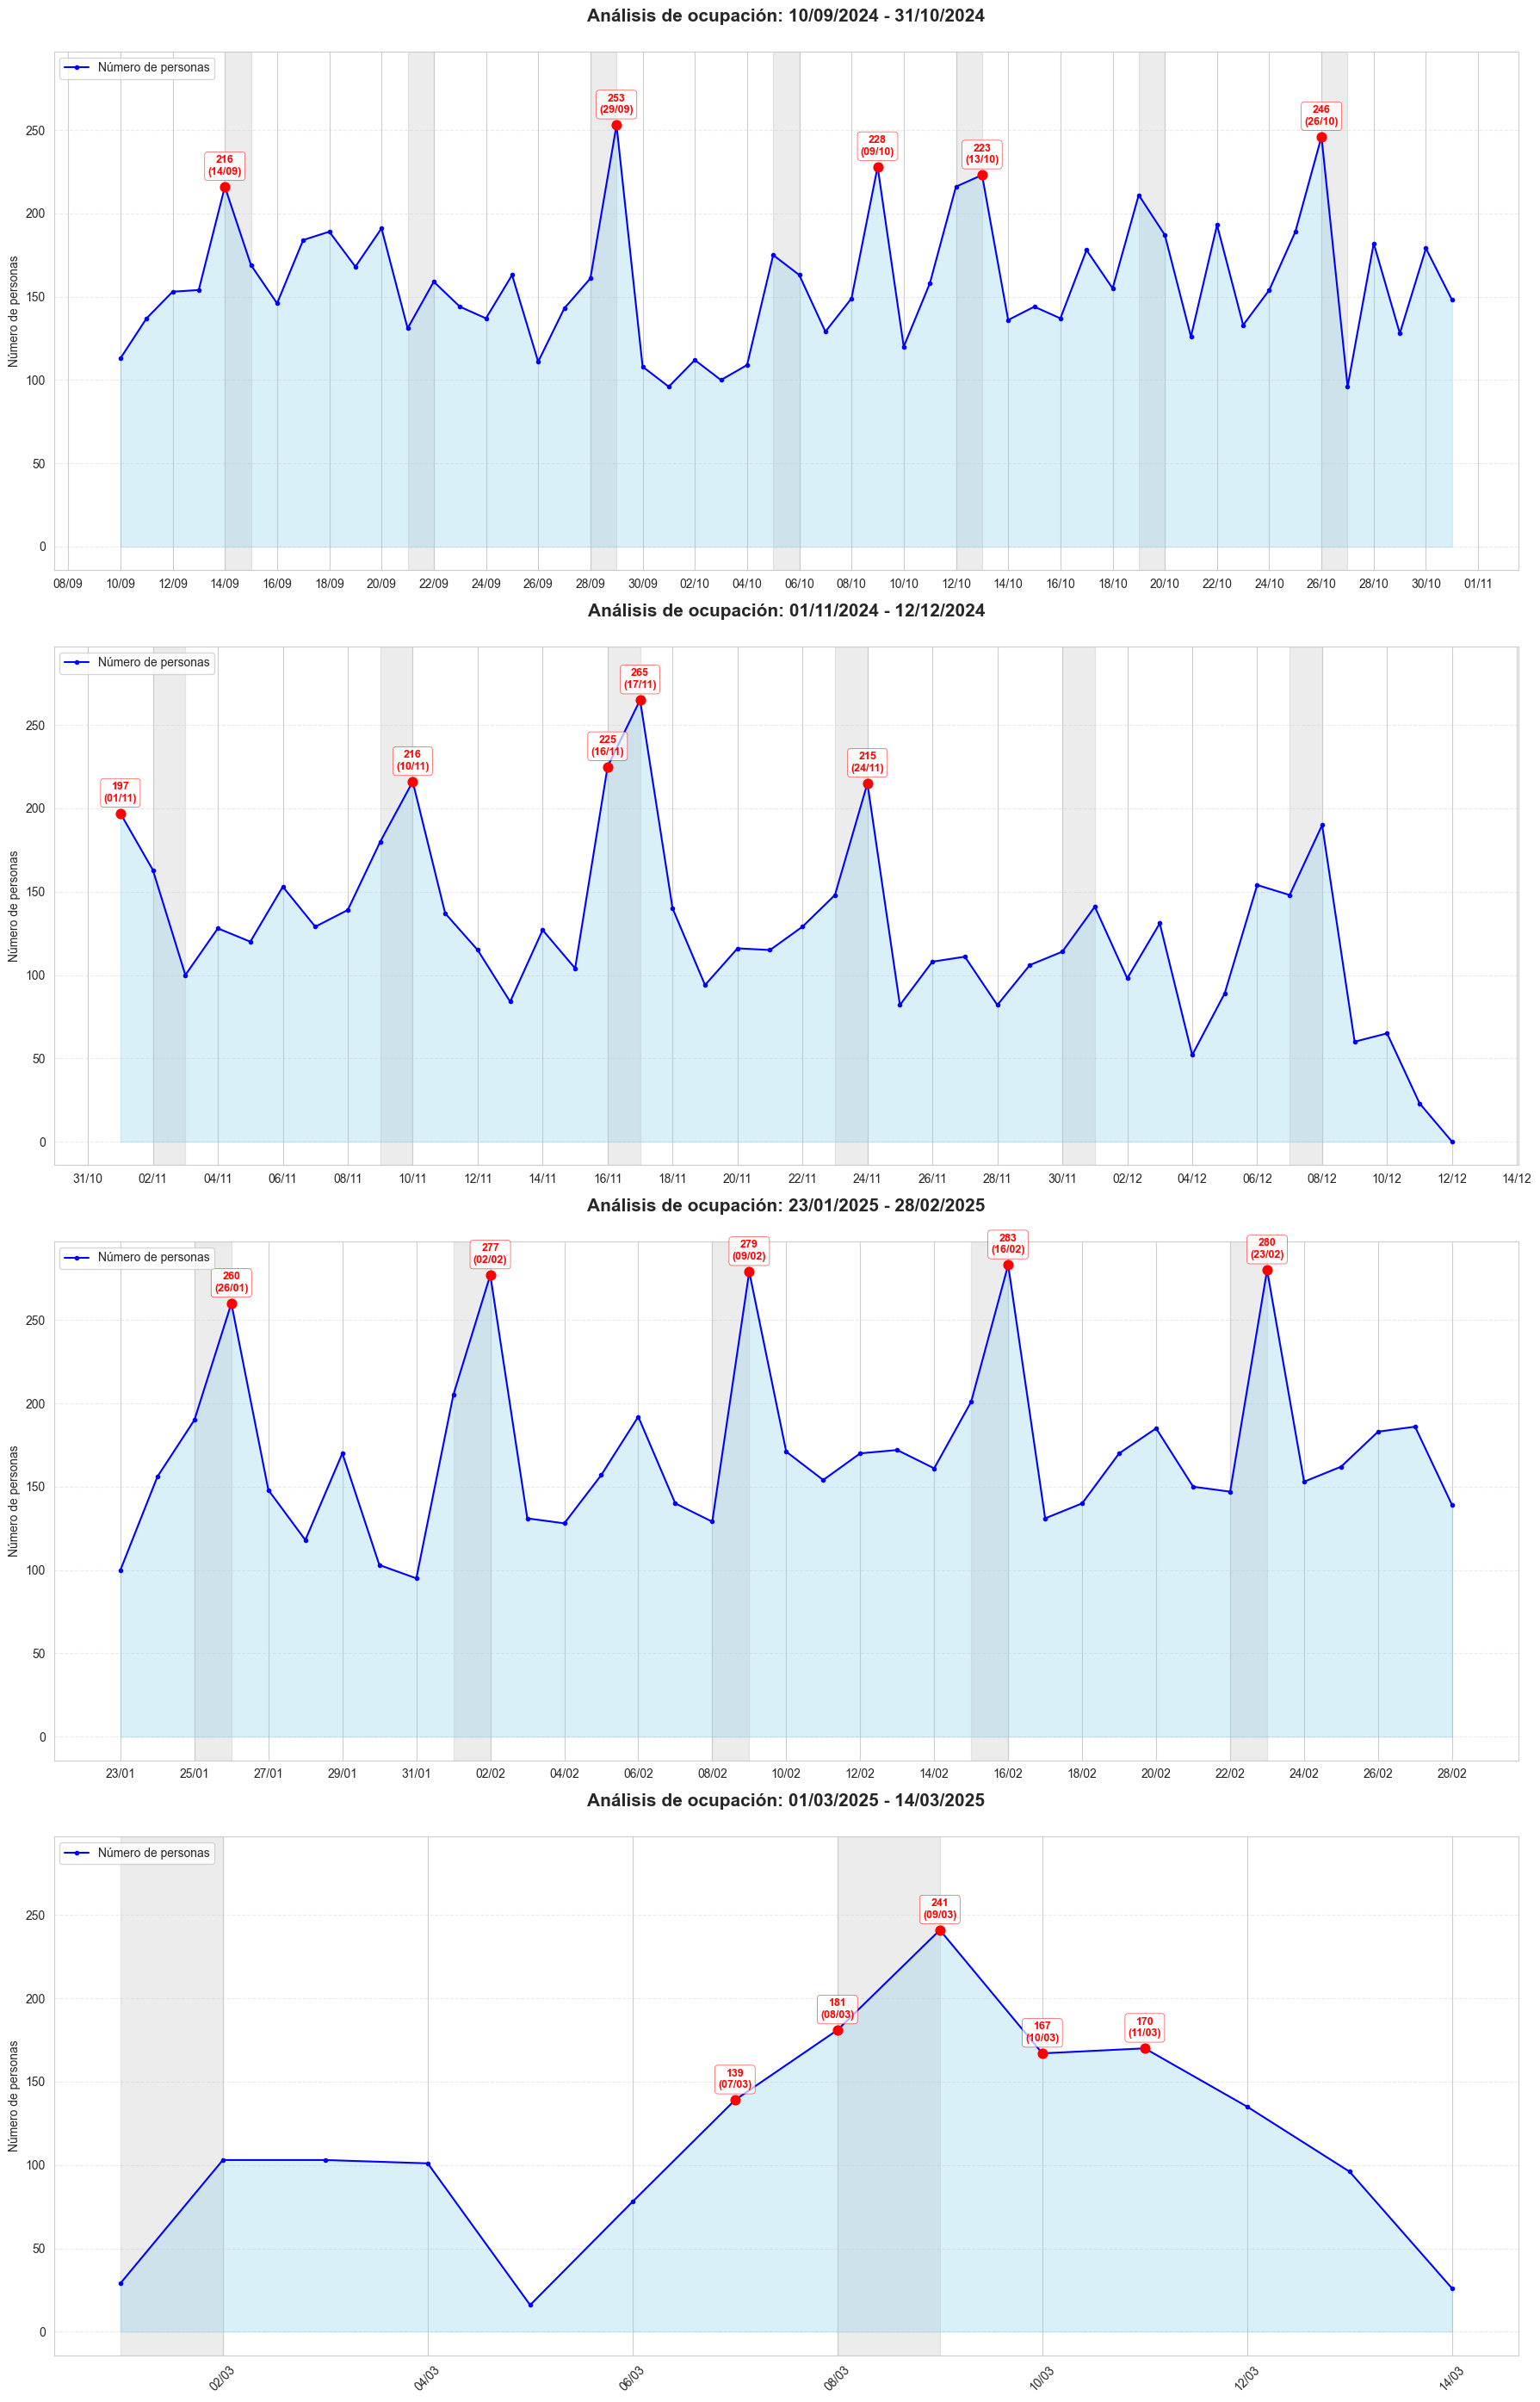

In [21]:
# --- CONFIGURACIÓN DE GRÁFICOS ---
# Ahora el Grouper funcionará correctamente
grupos = [g for n, g in df_lagunas_dia.groupby(pd.Grouper(freq='2MS')) if not g.empty]
n_grupos = len(grupos)


# Creamos la figura con subplots según el número de grupos
fig, axes = plt.subplots(n_grupos, 1, figsize=(18, 7 * n_grupos), sharey=True)
if n_grupos == 1: axes = [axes]

for i, data in enumerate(grupos):
    ax = axes[i]
    
    # 1. Graficamos la serie principal (Máximos diarios)
    # Usamos fill_between y plot para mantener la estética
    ax.fill_between(data.index, data['count_out'], color='skyblue', alpha=0.3)
    ax.plot(data.index, data['count_out'], color='blue', lw=1.5, marker='.', label='Número de personas')
    
    # 2. Anotamos los 5 picos más altos de este periodo
    # Al ser df_lagunas_dia, nlargest nos dará los 5 días con más salidas
    top_5_picos = data.nlargest(5, 'count_out')
    
    for t_exacto, row in top_5_picos.iterrows():
        valor = row['count_out']
        
        if valor > 0:
            ax.scatter(t_exacto, valor, color='red', s=60, zorder=5)
            ax.annotate(f'{valor}\n({t_exacto.strftime("%d/%m")})', 
                        xy=(t_exacto, valor), 
                        xytext=(0, 10), 
                        textcoords='offset points', 
                        ha='center', 
                        fontsize=9, 
                        fontweight='bold', 
                        color='red',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='red', lw=0.5))

    # 3. Sombreamos fines de semana (Sábado y Domingo únicamente)
    dias_rango = pd.date_range(data.index.min(), data.index.max(), freq='D')
    for d in dias_rango:
        # 5 es Sábado. Si es sábado, pintamos un bloque que dure 2 días (Sábado + Domingo)
        if d.weekday() == 5: 
            ax.axvspan(d, d + pd.Timedelta(days=1), color='gray', alpha=0.15, zorder=0)
        # Si el rango empieza en domingo, pintamos solo ese domingo (1 día)
        elif d == dias_rango[0] and d.weekday() == 6:
            ax.axvspan(d, d + pd.Timedelta(days=0), color='gray', alpha=0.15, zorder=0)

    # 4. Formato de ejes y títulos
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    
    inicio_str = data.index.min().strftime("%d/%m/%Y")
    fin_str = data.index.max().strftime("%d/%m/%Y")
    
    ax.set_title(f'Análisis de ocupación: {inicio_str} - {fin_str}', 
                    fontsize=15, pad=25, fontweight='bold')
    ax.set_ylabel('Número de personas')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hemos diseñado la gráfica para mostrar los picos más altos de ocupación cada 2 meses, los cuales se han marcado con puntos rojos. También, hemos sombreado los fines de semana.

Observamos que, en términos generales, la mayor afluencia de visitantes se da los fines de semana (de sábado a domingo), a excepción de ciertos momentos (como el 9 de octubre o el 1 de noviembre, festivos).

De septiembre a octubre, la afluencia de visitantes se da en mayor medida en fines de semana, aunque también hay visitan las lagunas un número considerable de personas durante la semana. A medida que se acerca la temporada de otoño, los picos de ocupación se reducen en la mayoría de los días laborales, aunque los fines de semana siguen siendo puntos clave.

De noviembre a febrero, las visitas en días laborales se reducen considerablemente. Sin embargo, dejan de contabilizarse los registros desde mitad de diciembre hasta casi finales de enero, probablemente debido a las festividades y el descenso general de turistas fuera de las vacaciones, o al cierre de las lagunas. 

En marzo, la afluencia desciende considerablemente. Aunque algunos picos pueden seguir apareciendo durante los fines de semana, estos son mucho menos pronunciados.

A continuación, graficamos el promedia de asistencias por día de la semana

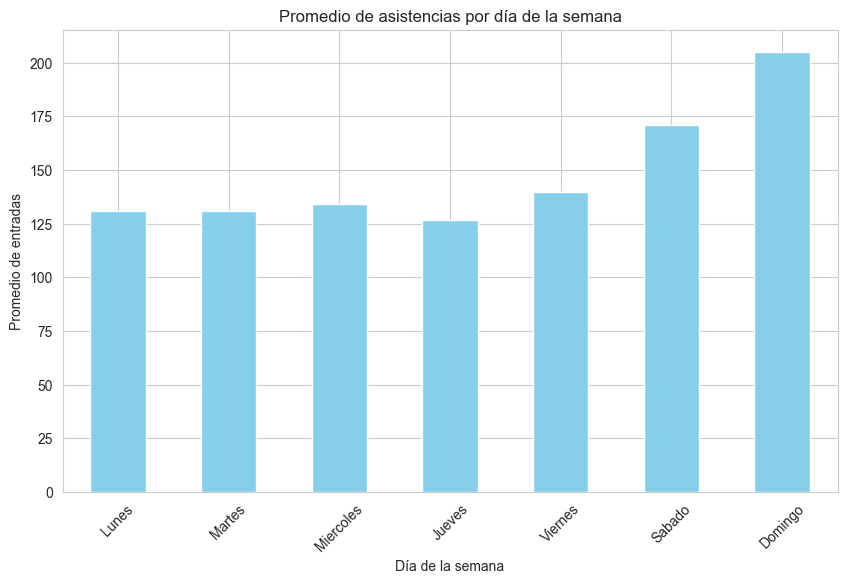

In [22]:
plt.figure(figsize=(10, 6))
df_lagunas_dia.groupby('Dia_semana', observed=True)['count_out'].mean().plot(kind='bar', color='skyblue')

plt.title('Promedio de asistencias por día de la semana')
plt.ylabel('Promedio de entradas')
plt.xlabel('Día de la semana')
plt.xticks(rotation=45)
plt.show()

En este gráfico de barras, observamos claramente que los fines de semana son los días donde mayor afluencia de visitantes se produce. En concreto, el domingo. El domingo tiene un aumento de visitantes con respecto al viernes (día laboral con mayor afluencia de gente) de entorno a 70 visitantes, aproximadamente un 33% más de afluencia.

Durante la semana laboral, el número de asistencias parece estable, ningún día destaca sobre otros.

Finalmente, estudiamos cómo varía el número de personas que entran y salen de las lagunas a lo largo de un día. Para ello, en lugar de desplegar toda la serie temporal, pues no seríamos capaces de apreciar ningún patrón horario, decidimos ver estas distribuciones de los 7 días de la semana, pero cada uno de ellos sería un día aletorio. Por ejemplo, para el lunes, elegimos al azar un lunes de todo el *dataset*. Para que los resultados sean reproducibles, fijamos una semilla.

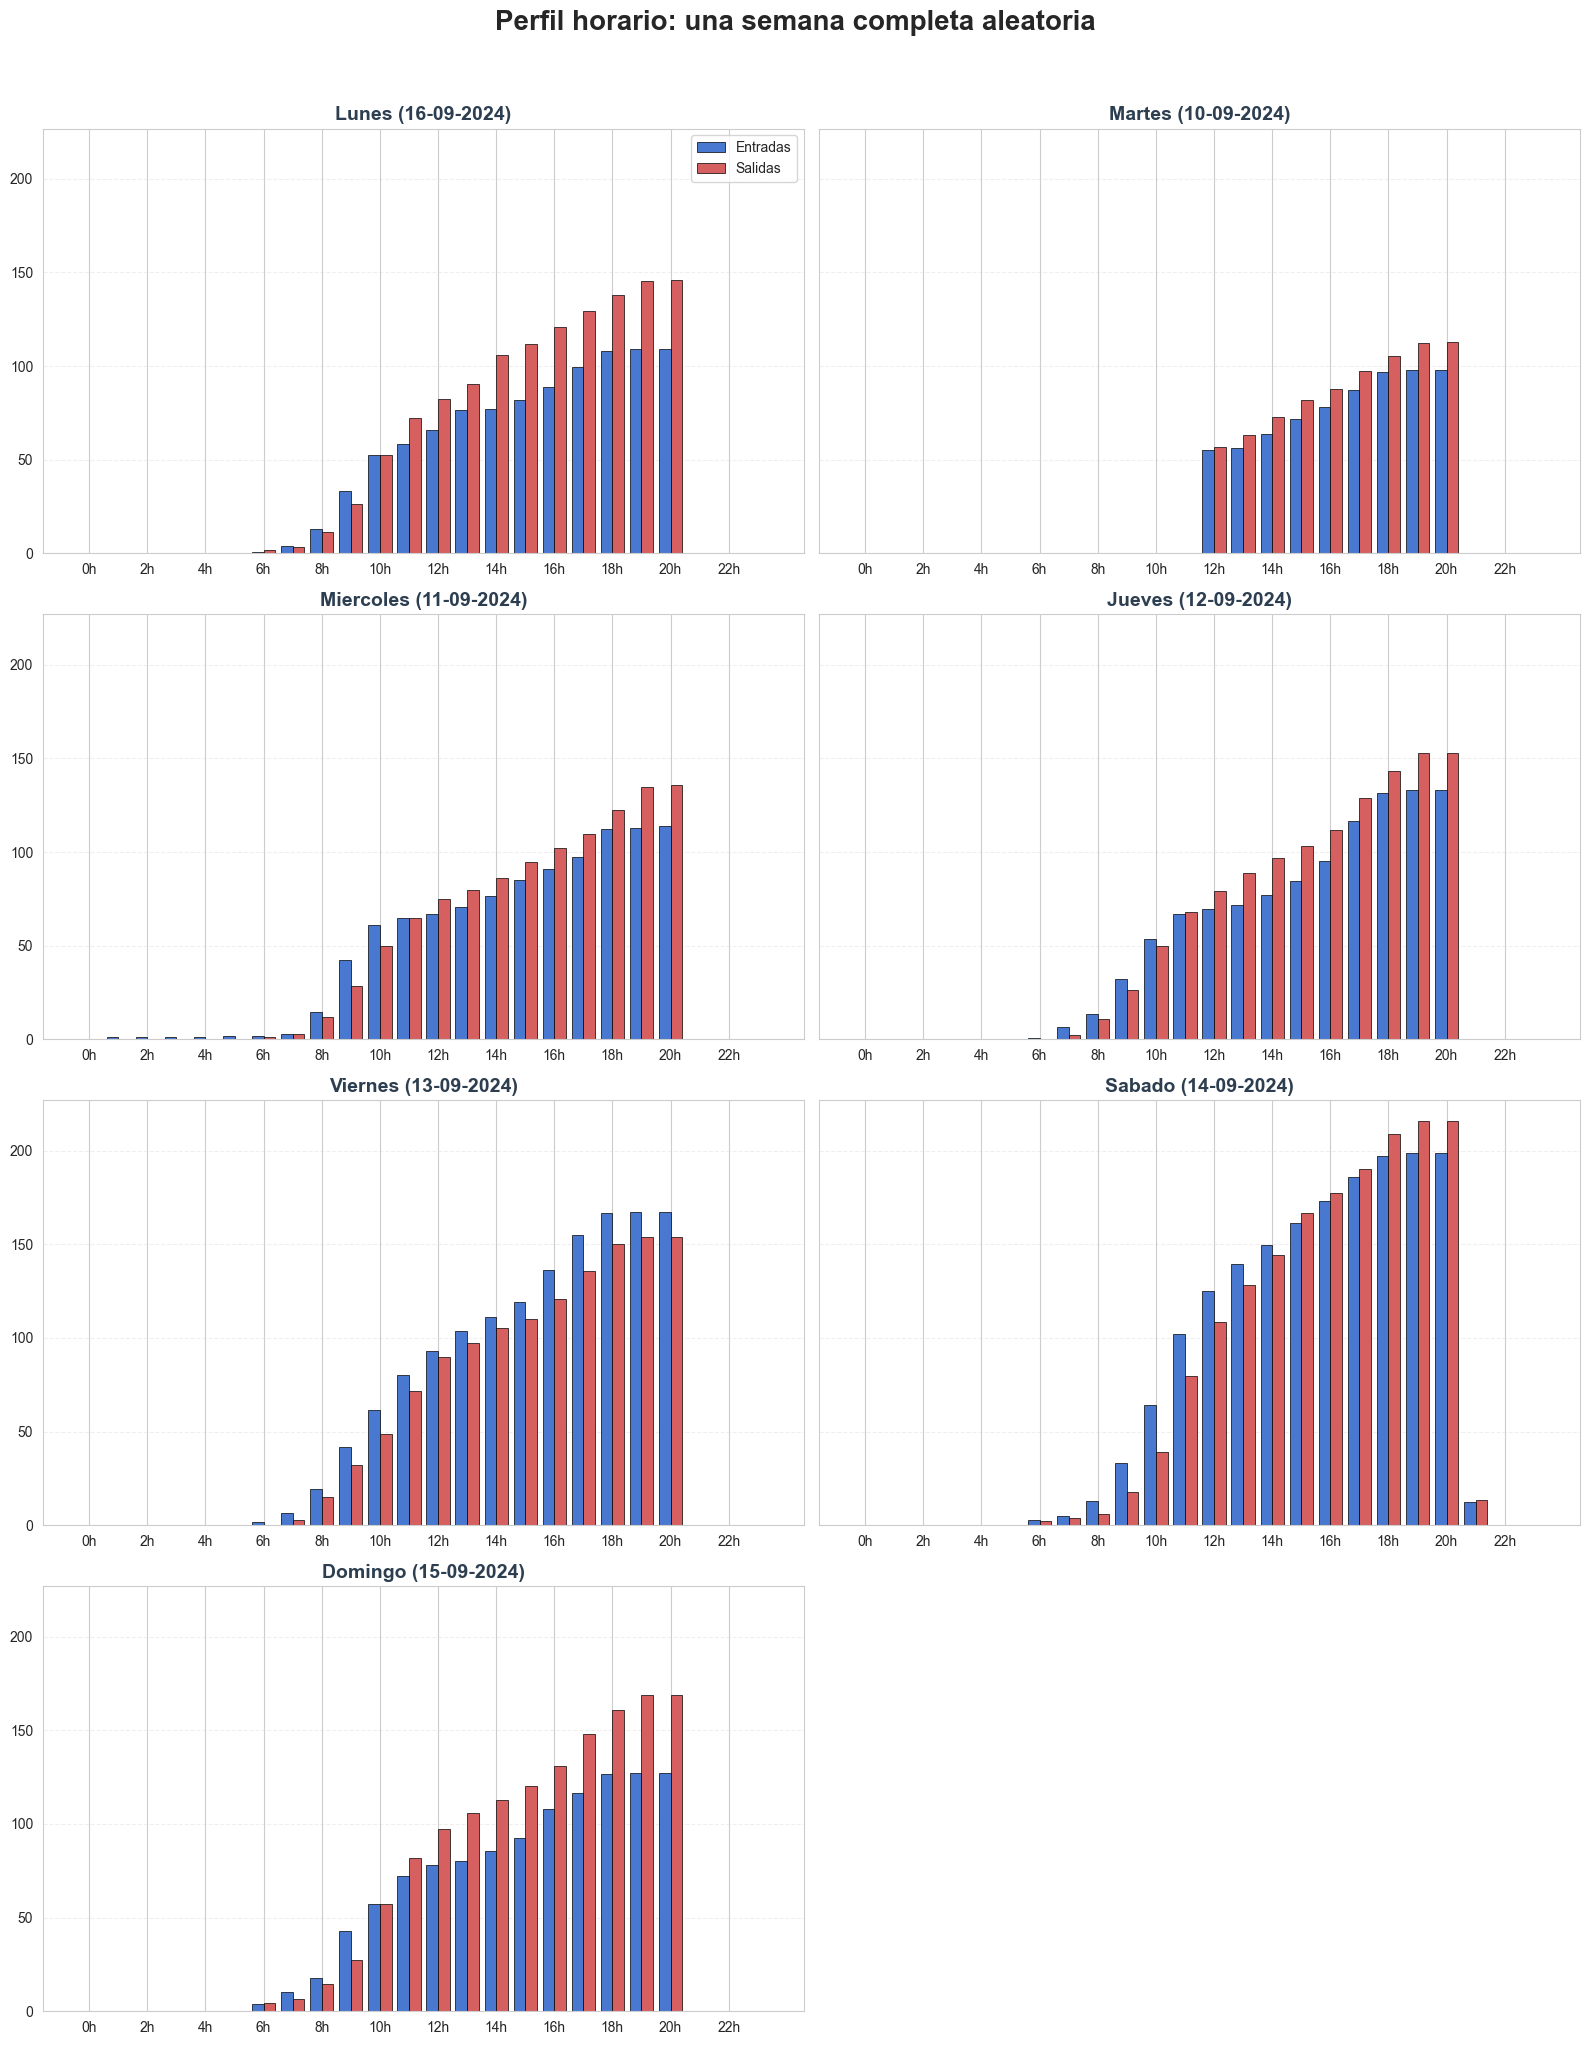

In [23]:
# Definimos la semilla
SEMILLA = 42 

# Selección de un día único para cada día de la semana
# Agrupamos todas las fechas disponibles por el nombre del día en español
dias_disponibles = df_lagunas[['Fecha_sin_hora', 'Dia_semana']].drop_duplicates()

# Extraemos un ejemplo aleatorio para cada uno de los 7 días
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
random_dates = []

for dia in orden_dias:
    # Filtramos todas las fechas que caen en ese día (ej. todos los Lunes)
    opciones = dias_disponibles[dias_disponibles['Dia_semana'] == dia]['Fecha_sin_hora']
    
    if not opciones.empty:
        # Elegimos una fecha al azar de ese día específico
        fecha_elegida = opciones.sample(1, random_state=SEMILLA).iloc[0]
        random_dates.append(fecha_elegida)

# CONFIGURACIÓN DE LA CUADRÍCULA (4x2)
fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharey=True)
axes = axes.flatten()
paleta = sns.color_palette("muted")
width = 0.4 

for i, date_obj in enumerate(random_dates):
    ax = axes[i]
    
    # Filtramos los datos del día
    df_day = df_lagunas[df_lagunas['Fecha_sin_hora'] == date_obj]
    
    # Obtenemos el nombre del día en español desde tu propia columna
    nombre_dia_es = df_day['Dia_semana'].iloc[0]
    date_str = date_obj.strftime("%d-%m-%Y")
    
    # Promedio por hora
    df_hourly_day = df_day.groupby('Hora')[['count_in', 'count_out']].mean()
    df_hourly_day = df_hourly_day.reindex(range(24), fill_value=0)
    
    horas = df_hourly_day.index
    
    # Dibujamos barras lado a lado
    ax.bar(horas - width/2, df_hourly_day['count_in'], width, 
           label='Entradas', color=paleta[0], edgecolor='black', lw=0.5)
    ax.bar(horas + width/2, df_hourly_day['count_out'], width, 
           label='Salidas', color=paleta[3], edgecolor='black', lw=0.5)
    
    # Estética
    ax.set_title(f'{nombre_dia_es} ({date_str})', fontsize=14, fontweight='bold', color='#2c3e50')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h}h' for h in range(0, 24, 2)])
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    if i == 0:
        ax.legend()

# Ocultamos el último hueco sobrante
axes[-1].axis('off')

fig.suptitle(f'Perfil horario: una semana completa aleatoria', 
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

En primer lugar, aclaramos que el número personas que entran y salen a lo largo de día son acomulaciones, no valores discretos; es decir, los valores de entrada a las 7 de la tarde no son las personas que han entrado a las 7 de la tarde, sino todas las personas que han entradado desde primera hora de la mañana hasta las 7 de la tarde.

Tras ver estas 7 subgráficas, vemos que presentan patrones muy similares:

* Las salidas acumuladas son mucho mayores que las entradas. No sabemos la razóne exacta de por qué sale mucha más gente de la que entra. Suponemos que son errores de los sensores o de que hay puertas por donde sale/entra la gente que no tienen sensores.
- Las entradas comienzan a ser más frecuentes durante las primeras horas de la mañana y se incrementan a lo largo de la tarde, estabilizándose a medio día y al final de la tarde (en concreto, de 8 a 10/11 de la mañana y de 4 a 7 de la tarde es cuando más gente entra).
- Las salidas parecen mantener un aumento constante a lo largo de todo el día.

#### 2.1.4 Presupuestos Municipales (Gastos e Ingresos)

En este trabajo, la carpeta donde se encuentran todos los pdfs de gastos e ingresos de Torrevieja por parte del ayuntamiento desde 2022 hasta 2025 se encuentra dentro del Reto 4, con el nombre *Gastos-Ingresos*. De todos los datos que aparecen en los pdfs de gastos, nos quedamos con 2: 

1. Del capítulo *Gastos corrientes en bienes y servicios*, nos quedamos con el valor de *Obligaciones*. Este valor incluyen los pagos a empresas externas por la limpieza de calles, el mantenimiento de alcantarillado, los contratos con laboratorios para analizar el agua de las playas y pozos, etc. Representa el gasto que el Ayuntamiento ya ha reconocido que debe pagar por servicios efectivamente realizados.
2. Del capítulo *Gastos en inversiones*, nos quedamos con el valor de *Obligaciones*. Representa el dinero destinado a crear nuevas infraestructuras.

En cuanto a los pdfs de ingresos, del capítulo de *Tasas, precios públicos y otros ingresos*, nos quedamos con el valor de *DR Reconocidos*. Refleja la actividad turística y ciudadana; esto es, el dinero que espera recaudar el ayuntamiento por el uso de servicios públicos.

Así, creamos un *dataset* llamado *Gastos-Ingresos_22-25* con estas 3 columnas.

In [29]:
df_gastos_ingresos = pd.read_excel('../DATASETS/RETO 4/DATASETS ORIGINALES/Gastos-Ingresos_22-25.ods', engine='odf')
df_gastos_ingresos.head(20)

,Año y trimestre,Gastos corrientes en bienes y servicios,Gastos en inversiones,"Tasas, precios públicos y otros ingresos"
0,2022-1T,7059422.50,3210315.63,1426569.37
1,2022-2T,19181233.12,5982982.75,5846939.75
2,2022-3T,31854821.35,6591456.00,7084401.26
3,2022-4T,63309008.11,12029399.65,12992689.81
4,2023-1T,5482259.22,1102313.34,3187406.46
5,2023-2T,25327364.71,3238684.10,7106110.59
6,2023-3T,43756926.70,4392186.82,8604559.60
7,2023-4T,71796651.83,11217567.06,14383794.00
8,2024-1T,12000447.09,385455.19,2564571.24
9,2024-2T,22495424.51,8842158.37,8317313.76


Dado que tenemos los gastos e ingresos acumulados por trimestres y no discretos; es decir, los gastos del tercer trimestre también incluyen los de los 2 trimestres anteriores, procedemos a añadir al *dataset* los gastos e ingresos relativos únicamente a cada trimestre.

In [30]:
# Extraemos el Año y el Trimestre de la columna 'Año y trimestre'
df_gastos_ingresos['Año'] = df_gastos_ingresos['Año y trimestre'].str[:4].astype(int)
df_gastos_ingresos['Trimestre'] = df_gastos_ingresos['Año y trimestre'].str[5:6].astype(int)

# Definimos las listas de trimestres y años
trimestres = [1, 2, 3, 4] 
años = [2022, 2023, 2024, 2025] 

# Inicializamos listas vacías donde almacenaremos los resultados de los cálculos
gastos_bienes_servicios = []  
gastos_inversiones = [] 
ingresos = [] 
gastos_totales = [] 

# Comenzamos un bucle para recorrer cada año y trimestre
for año in años:
    for trimestre in trimestres:
        # Para el primer trimestre de cada año, no se realiza la diferencia, se toma el valor tal cual
        if trimestre == 1:
            # Añadimos los valores de los gastos y los ingresos del primer trimestre
            gastos0 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre)]['Gastos corrientes en bienes y servicios'].values[0]
            gastos2 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre)]['Gastos en inversiones'].values[0]
            ingresos0 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre)]['Tasas, precios públicos y otros ingresos'].values[0]
            
            gastos_bienes_servicios.append(gastos0)
            gastos_inversiones.append(gastos2)
            ingresos.append(ingresos0)
            gastos_totales.append(gastos0 + gastos2)

        else:
            # Para trimestres posteriores, calculamos la diferencia respecto al trimestre anterior
            # Gastos en bienes y servicios del trimestre actual menos los del trimestre anterior
            gastos0 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre-1)]['Gastos corrientes en bienes y servicios'].values[0]
            gastos1 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre)]['Gastos corrientes en bienes y servicios'].values[0]
            gastos_bienes_servicios.append(gastos1 - gastos0)

            # Gastos en inversiones del trimestre actual menos los del trimestre anterior
            gastos2 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre-1)]['Gastos en inversiones'].values[0]
            gastos3 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre)]['Gastos en inversiones'].values[0]
            gastos_inversiones.append(gastos3 - gastos2)
            
            gastos_totales.append(gastos1 - gastos0 + gastos3 - gastos2)

            # Ingresos del trimestre actual menos los del trimestre anterior
            ingresos0 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre-1)]['Tasas, precios públicos y otros ingresos'].values[0]
            ingresos1 = df_gastos_ingresos[(df_gastos_ingresos['Año'] == año) & (df_gastos_ingresos['Trimestre'] == trimestre)]['Tasas, precios públicos y otros ingresos'].values[0]
            ingresos.append(ingresos1 - ingresos0)

# Finalmente, asignamos los resultados a nuevas columnas en el DataFrame
df_gastos_ingresos['gastos_bienes_servicios'] = gastos_bienes_servicios 
df_gastos_ingresos['gastos_inversiones'] = gastos_inversiones  
df_gastos_ingresos['ingresos'] = ingresos 
df_gastos_ingresos['gastos_totales'] = gastos_totales 

In [31]:
print("=== 1. FILAS DEL DATASET ===")
display(df_gastos_ingresos.head(20))

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_gastos_ingresos.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_gastos_ingresos.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_gastos_ingresos.duplicated().sum()}\n")

=== 1. FILAS DEL DATASET ===


,Año y trimestre,Gastos corrientes en bienes y servicios,Gastos en inversiones,"Tasas, precios públicos y otros ingresos",Año,Trimestre,gastos_bienes_servicios,gastos_inversiones,ingresos,gastos_totales
0,2022-1T,7059422.50,3210315.63,1426569.37,2022,1,7059422.50,3210315.63,1426569.37,10269738.13
1,2022-2T,19181233.12,5982982.75,5846939.75,2022,2,12121810.62,2772667.12,4420370.38,14894477.74
2,2022-3T,31854821.35,6591456.00,7084401.26,2022,3,12673588.23,608473.25,1237461.51,13282061.48
3,2022-4T,63309008.11,12029399.65,12992689.81,2022,4,31454186.76,5437943.65,5908288.55,36892130.41
4,2023-1T,5482259.22,1102313.34,3187406.46,2023,1,5482259.22,1102313.34,3187406.46,6584572.56
5,2023-2T,25327364.71,3238684.10,7106110.59,2023,2,19845105.49,2136370.76,3918704.13,21981476.25
6,2023-3T,43756926.70,4392186.82,8604559.60,2023,3,18429561.99,1153502.72,1498449.01,19583064.71
7,2023-4T,71796651.83,11217567.06,14383794.00,2023,4,28039725.13,6825380.24,5779234.40,34865105.37
8,2024-1T,12000447.09,385455.19,2564571.24,2024,1,12000447.09,385455.19,2564571.24,12385902.28
9,2024-2T,22495424.51,8842158.37,8317313.76,2024,2,10494977.42,8456703.18,5752742.52,18951680.60



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Año y trimestre                           16 non-null     str    
 1   Gastos corrientes en bienes y servicios   16 non-null     float64
 2   Gastos en inversiones                     16 non-null     float64
 3   Tasas, precios públicos y otros ingresos  16 non-null     float64
 4   Año                                       16 non-null     int64  
 5   Trimestre                                 16 non-null     int64  
 6   gastos_bienes_servicios                   16 non-null     float64
 7   gastos_inversiones                        16 non-null     float64
 8   ingresos                                  16 non-null     float64
 9   gastos_totales                            16 non-null     float64
dtypes: floa

Creamos variables auxiliares para las visualizaciones y nos descargamos el csv resultante.

In [32]:
# Calculamos la proporción de recuperación
df_gastos_ingresos['Proporcion_recuperada'] = (df_gastos_ingresos['ingresos'] / df_gastos_ingresos['gastos_totales']) * 100

# Guardamos el dataset modificado
df_gastos_ingresos.to_csv(
    '../DATASETS/RETO 4/DATASETS MODIFICADOS/Gastos_Ingresos_MOD.csv', 
    index=False, 
    sep=";", 
    encoding="latin-1"
)

Consideramos que estos son los gastos e ingresos relacionados con el turismo, que también tienen que ver con la ciudadanía de Torrevieja, pero hacemos esta consideración por simplicidad. Por tanto, de los gastos relacionados con el turismo, veamos que proporción se recupera con los ingresos que se obtienen también del turismo.

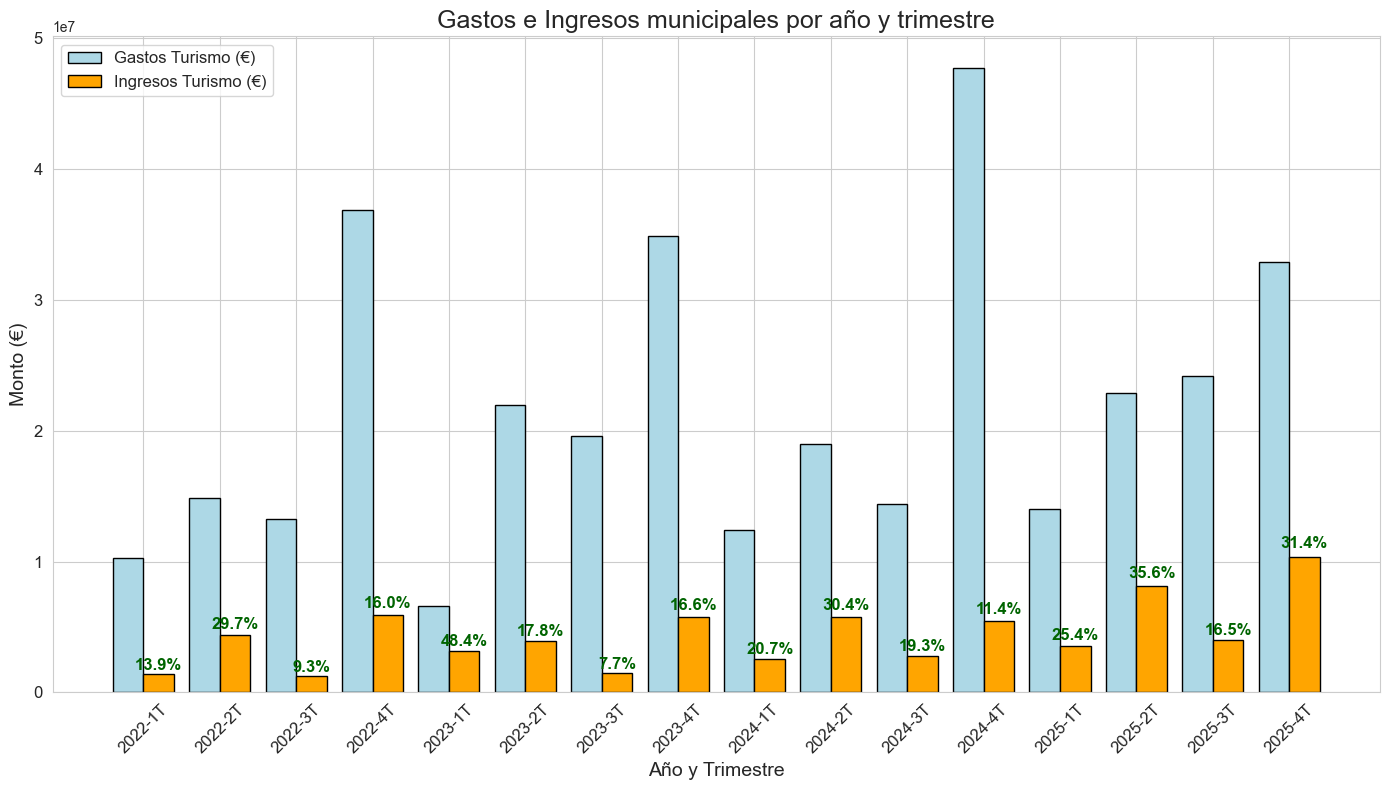

In [33]:
# Creamos un gráfico de barras con barras al lado
fig, ax1 = plt.subplots(figsize=(14, 8))

# Definimos las posiciones para las barras
x_pos = np.arange(len(df_gastos_ingresos))

# Ancho de las barras
width = 0.4

# Graficamos las barras de los gastos e ingresos turísticos
bars_gastos = ax1.bar(x_pos - width/2, df_gastos_ingresos['gastos_totales'], width, label='Gastos Turismo (€)', color='lightblue', edgecolor='black')
bars_ingresos = ax1.bar(x_pos + width/2, df_gastos_ingresos['ingresos'], width, label='Ingresos Turismo (€)', color='orange', edgecolor='black')

# Añadimos el porcentaje de recuperación sobre las barras de ingresos
for i, bar in enumerate(bars_ingresos):
    height = bar.get_height()
    proportion = df_gastos_ingresos['Proporcion_recuperada'].iloc[i]
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.05 * height, f'{proportion:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkgreen')

# Títulos y etiquetas
ax1.set_title('Gastos e Ingresos municipales por año y trimestre', fontsize=18)
ax1.set_xlabel('Año y Trimestre', fontsize=14)
ax1.set_ylabel('Monto (€)', fontsize=14)
ax1.tick_params(axis='both', labelsize=12)  # Aumentamos el tamaño de las etiquetas de los ejes

# Etiquetas en el eje X
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_gastos_ingresos['Año y trimestre'], rotation=45, fontsize=12)

# Añadimos leyenda
ax1.legend(loc='upper left', fontsize=12)

# Mejoraramos el ajuste y mostrar la gráfica
plt.tight_layout()
plt.show()

En general, vemos que se repiten patrones similares por año:

* Para los gastos, se sigue el mismo patrón por año en cuanto a top de trimestres en los que se gasta más: 1T<3T<2T<4T (a excepción del año 2025, en que 2T<3T). Además, observamos que el salto del tercer trimestre al cuarto es muy grande, en el cuarto trimestre es cuando más se gasta y con gran diferencia. También, parece que a lo largo de los años, los gastos son mayores.

* Para los ingresos, no observamos patrones tan claros como para los gastos. si que notamos que a medida que avanzan los años, los ingresos tienden a ser mayores.

* En cuanto a la proporción de dinero que el turismo es capaz de recuperar, vemos que los mínimos y máximos por año aumentan a lo laego de los años.

Así, en general, podemos decir que parece seguirse un orden en cuanto a trimestres en los que más se gasta y que los gastos e ingresos tieneden a aumentar con los años, al igual que la proporción de dinero que se recupera con el turismo.

#### 2.1.5 Registros sobre criminalidad

Al acceder a este enlace, nos damos cuenta de que los registros de criminalidad se organizan por años, y cada año se organiza en 4 trimestres. Si nos metemos en un trimestre de un año en concreto, nos podemos descargar un archivo *.xlsx* que contienen registros de criminalidad para ese trimestre de ese año, pero de toda España. Por tanto, nos hemos descargado los archivos de los 4 trimestres de los años 2021-2025 (los que había disponibles), y los hemos guardado en la carpeta *Criminalidad* del reto 4

Posteriormente, manualmente hacemos un excel que contenga los delitos de los que se tienen registros para Torrevieja para cada Año-Trimestre. Observamos que para los años 2020-2021 los delitos de ciberseguridad están vacíos. Esto se debe a que estos delitos se comenzaron a registrar posteriormente.

In [34]:
df_criminalidad = pd.read_excel('../DATASETS/RETO 4/DATASETS ORIGINALES/Criminalidad.ods', engine='odf')
df_criminalidad.head(20)

,Delitos,2024-1T,2025-1T,2024-2T,2025-2T,2024-3T,2025-3T,2024-4T,2025-4T,2023-1T,...,2022-3T,2022-4T,2021-1T,2021-2T,2021-3T,2021-4T,2020-1T,2020-2T,2020-3T,2020-4T
0,I. CRIMINALIDAD CONVENCIONAL,1921,1893,3860,4344,6422,7122,6422,7122,1614,...,5658,7371,1204.0,2647.0,4722.0,6320.0,1387.0,2447.0,4385.0,5646.0
1,1. Homicidios dolosos y asesinatos consumados,1,0,1,0,1,1,1,1,0,...,0,0,0.0,1.0,1.0,3.0,2.0,2.0,2.0,3.0
2,2. Homicidios dolosos y asesinatos en grado te...,1,1,1,2,1,3,1,3,1,...,1,2,4.0,5.0,8.0,8.0,0.0,0.0,2.0,3.0
3,3. Delitos graves y menos graves de lesiones y...,36,32,84,67,145,108,145,108,27,...,86,104,9.0,27.0,71.0,98.0,21.0,39.0,69.0,84.0
4,4. Secuestro,0,0,0,0,1,0,1,0,0,...,1,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
5,5. Delitos contra la libertad sexual,16,22,39,44,68,67,68,67,16,...,61,74,6.0,25.0,40.0,56.0,14.0,23.0,36.0,47.0
6,5.1. Agresión sexual con penetración,4,3,8,11,17,19,17,19,2,...,17,19,1.0,4.0,6.0,7.0,2.0,2.0,4.0,7.0
7,5.2. Resto de delitos contra la libertad sexual,12,19,31,33,51,48,51,48,14,...,44,55,5.0,21.0,34.0,49.0,12.0,21.0,32.0,40.0
8,6. Robos con violencia e intimidación,53,55,101,153,210,251,210,251,44,...,114,160,20.0,37.0,76.0,103.0,44.0,51.0,91.0,125.0
9,"7. Robos con fuerza en domicilios, establecimi...",136,142,272,313,441,509,441,509,121,...,485,611,150.0,312.0,490.0,621.0,216.0,324.0,553.0,679.0


Preprocesamos los datos de la siguiente forma:

1. Establecemos *Delitos* como índice y transponemos el resto de columnas.
2. Restablecemos el índice para convertirlo en una columna y renombramos *index* a *Año-Trimestre*.
3. Extraemos el *Año* y el *Trimestre* de la columna *Año-Trimestre*.
4. Ordenamos el *dataframe* por *Año* y *Trimestre*.
5. Eliminamos la columna *Año-Trimestre*.

In [35]:
# Establecemos 'Delitos' como índice y transponemos el resto de columnas
df_criminalidad = df_criminalidad.set_index('Delitos').transpose()

# Restablecemos el índice para convertirlo en una columna y renombramos 'index' a 'Año-Trimestre'
df_criminalidad.reset_index(inplace=True)
df_criminalidad.rename(columns={'index': 'Año-Trimestre'}, inplace=True)

# Extraemos el 'Año' y el 'Trimestre' de la columna 'Año-Trimestre'
df_criminalidad['Año'] = df_criminalidad['Año-Trimestre'].str[:4].astype(int)
df_criminalidad['Trimestre'] = df_criminalidad['Año-Trimestre'].str[5:6].astype(int)

# Ordenamos el dataframe por 'Año' y 'Trimestre'
df_criminalidad.sort_values(by=['Año', 'Trimestre'], ascending=[True, True], inplace=True)

Dado que tenemos los delitos acumulados por trimestres y no discretos; es decir, los delitos del tercer trimestre, por ejemplo, también incluyen los de los 2 trimestres anteriores, procedemos a añadir discretizarlos y a crear un nuevo *dataframe* a partir de ellos.

In [36]:
# Definimos los años y trimestres
años = [2020, 2021, 2022, 2023, 2024, 2025]
trimestres = [1, 2, 3, 4]

# Inicializamos listas vacías donde almacenaremos los resultados de los cálculos para cada delito
criminalidad_convencional = []
homicidios_consumados = []
homicidios_tentativa = []
delitos_graves_lesiones = []
secuestro = []
libertad_sexual = []
agresion_sexual = []
resto_agresion_sexual = []
robo_violencia = []
robos_sitios = []
robos_domicilios = []
hurtos = []
sustraccion_vehiculos = []
trafico_drogas = []
resto_crim = []
ciberdelitos = []
estafas_informaticas = []
otros_ciberdelitos = []

# Bucle para recorrer cada año y trimestre
for año in años:
    for trimestre in trimestres:
        # Si es el primer trimestre de cada año, tomamos el valor tal cual
        if trimestre == 1:
            # Para cada delito, tomamos el valor directamente del primer trimestre
            criminalidad_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['I. CRIMINALIDAD CONVENCIONAL'].values[0]
            homicidios_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['1. Homicidios dolosos y asesinatos consumados'].values[0]
            homicidios_tentativa_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['2. Homicidios dolosos y asesinatos en grado tentativa'].values[0]
            delitos_graves_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['3. Delitos graves y menos graves de lesiones y riña tumultuaria'].values[0]
            secuestro_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['4. Secuestro'].values[0]
            libertad_sexual_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['5. Delitos contra la libertad sexual'].values[0]
            agresion_sexual_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['5.1. Agresión sexual con penetración'].values[0]
            resto_agresion_sexual_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['5.2. Resto de delitos contra la libertad sexual'].values[0]
            robo_violencia_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['6. Robos con violencia e intimidación'].values[0]
            robos_sitios_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['7. Robos con fuerza en domicilios, establecimientos y otras instalaciones'].values[0]
            robos_domicilios_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['7.1 Robos con fuerza en domicilios'].values[0]
            hurtos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['8. Hurtos'].values[0]
            sustraccion_vehiculos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['9. Sustracciones de vehículos'].values[0]
            trafico_drogas_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['10. Tráfico de drogas'].values[0]
            resto_crim_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['11. Resto de criminalidad convencional'].values[0]
            ciberdelitos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['II. CIBERCRIMINALIDAD (infracciones penales cometidas en/por medio ciber)'].values[0]
            estafas_informaticas_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['12. Estafas informáticas'].values[0]
            otros_ciberdelitos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['13. Otros ciberdelitos'].values[0]
            
            # Añadimos los valores del primer trimestre
            criminalidad_convencional.append(criminalidad_0)
            homicidios_consumados.append(homicidios_0)
            homicidios_tentativa.append(homicidios_tentativa_0)
            delitos_graves_lesiones.append(delitos_graves_0)
            secuestro.append(secuestro_0)
            libertad_sexual.append(libertad_sexual_0)
            agresion_sexual.append(agresion_sexual_0)
            resto_agresion_sexual.append(resto_agresion_sexual_0)
            robo_violencia.append(robo_violencia_0)
            robos_sitios.append(robos_sitios_0)
            robos_domicilios.append(robos_domicilios_0)
            hurtos.append(hurtos_0)
            sustraccion_vehiculos.append(sustraccion_vehiculos_0)
            trafico_drogas.append(trafico_drogas_0)
            resto_crim.append(resto_crim_0)
            ciberdelitos.append(ciberdelitos_0)
            estafas_informaticas.append(estafas_informaticas_0)
            otros_ciberdelitos.append(otros_ciberdelitos_0)

        else:
            # Para trimestres posteriores, calculamos la diferencia respecto al trimestre anterior
            # Criminalidad convencional
            criminalidad_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['I. CRIMINALIDAD CONVENCIONAL'].values[0]
            criminalidad_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['I. CRIMINALIDAD CONVENCIONAL'].values[0]
            criminalidad_convencional.append(criminalidad_1 - criminalidad_0)

            # Repetimos para cada delito
            homicidios_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['1. Homicidios dolosos y asesinatos consumados'].values[0]
            homicidios_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['1. Homicidios dolosos y asesinatos consumados'].values[0]
            homicidios_consumados.append(homicidios_1 - homicidios_0)

            homicidios_tentativa_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['2. Homicidios dolosos y asesinatos en grado tentativa'].values[0]
            homicidios_tentativa_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['2. Homicidios dolosos y asesinatos en grado tentativa'].values[0]
            homicidios_tentativa.append(homicidios_tentativa_1 - homicidios_tentativa_0)

            delitos_graves_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['3. Delitos graves y menos graves de lesiones y riña tumultuaria'].values[0]
            delitos_graves_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['3. Delitos graves y menos graves de lesiones y riña tumultuaria'].values[0]
            delitos_graves_lesiones.append(delitos_graves_1 - delitos_graves_0)

            secuestro_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['4. Secuestro'].values[0]
            secuestro_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['4. Secuestro'].values[0]
            secuestro.append(secuestro_1 - secuestro_0)

            libertad_sexual_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['5. Delitos contra la libertad sexual'].values[0]
            libertad_sexual_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['5. Delitos contra la libertad sexual'].values[0]
            libertad_sexual.append(libertad_sexual_1 - libertad_sexual_0)

            agresion_sexual_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['5.1. Agresión sexual con penetración'].values[0]
            agresion_sexual_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['5.1. Agresión sexual con penetración'].values[0]
            agresion_sexual.append(agresion_sexual_1 - agresion_sexual_0)

            resto_agresion_sexual_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['5.2. Resto de delitos contra la libertad sexual'].values[0]
            resto_agresion_sexual_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['5.2. Resto de delitos contra la libertad sexual'].values[0]
            resto_agresion_sexual.append(resto_agresion_sexual_1 - resto_agresion_sexual_0)

            robo_violencia_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['6. Robos con violencia e intimidación'].values[0]
            robo_violencia_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['6. Robos con violencia e intimidación'].values[0]
            robo_violencia.append(robo_violencia_1 - robo_violencia_0)

            robos_sitios_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['7. Robos con fuerza en domicilios, establecimientos y otras instalaciones'].values[0]
            robos_sitios_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['7. Robos con fuerza en domicilios, establecimientos y otras instalaciones'].values[0]
            robos_sitios.append(robos_sitios_1 - robos_sitios_0)

            robos_domicilios_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['7.1 Robos con fuerza en domicilios'].values[0]
            robos_domicilios_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['7.1 Robos con fuerza en domicilios'].values[0]
            robos_domicilios.append(robos_domicilios_1 - robos_domicilios_0)

            resto_crim_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['11. Resto de criminalidad convencional'].values[0]
            resto_crim_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['11. Resto de criminalidad convencional'].values[0]
            resto_crim.append(resto_crim_1 - resto_crim_0)

            hurtos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['8. Hurtos'].values[0]
            hurtos_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['8. Hurtos'].values[0]
            hurtos.append(hurtos_1 - hurtos_0)

            sustraccion_vehiculos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['9. Sustracciones de vehículos'].values[0]
            sustraccion_vehiculos_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['9. Sustracciones de vehículos'].values[0]
            sustraccion_vehiculos.append(sustraccion_vehiculos_1 - sustraccion_vehiculos_0)

            trafico_drogas_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['10. Tráfico de drogas'].values[0]
            trafico_drogas_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['10. Tráfico de drogas'].values[0]
            trafico_drogas.append(trafico_drogas_1 - trafico_drogas_0)

            # Ciberdelitos (tienen NaN en los primeros años)
            ciberdelitos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['II. CIBERCRIMINALIDAD (infracciones penales cometidas en/por medio ciber)'].values[0]
            ciberdelitos_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['II. CIBERCRIMINALIDAD (infracciones penales cometidas en/por medio ciber)'].values[0]
            ciberdelitos.append(ciberdelitos_1 - ciberdelitos_0)

            # Estafas informáticas
            estafas_informaticas_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['12. Estafas informáticas'].values[0]
            estafas_informaticas_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['12. Estafas informáticas'].values[0]
            estafas_informaticas.append(estafas_informaticas_1 - estafas_informaticas_0)

            # Otros ciberdelitos
            otros_ciberdelitos_0 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre-1)]['13. Otros ciberdelitos'].values[0]
            otros_ciberdelitos_1 = df_criminalidad[(df_criminalidad['Año'] == año) & (df_criminalidad['Trimestre'] == trimestre)]['13. Otros ciberdelitos'].values[0]
            otros_ciberdelitos.append(otros_ciberdelitos_1 - otros_ciberdelitos_0)



In [37]:
# Creamos un df vacío y añadimos Año y Trimestre
df_criminalidad1 = pd.DataFrame()
df_criminalidad1['Año'] = df_criminalidad['Año']
df_criminalidad1['Trimestre'] = df_criminalidad['Trimestre']
df_criminalidad1['Año-Trimestre'] = df_criminalidad['Año-Trimestre']


# Asignamos los resultados a nuevas columnas en el DataFrame
df_criminalidad1['I. CRIMINALIDAD CONVENCIONAL'] = criminalidad_convencional
df_criminalidad1['1. Homicidios dolosos y asesinatos consumados'] = homicidios_consumados
df_criminalidad1['2. Homicidios dolosos y asesinatos en grado tentativa'] = homicidios_tentativa
df_criminalidad1['3. Delitos graves y menos graves de lesiones y riña tumultuaria'] = delitos_graves_lesiones
df_criminalidad1['4. Secuestro'] = secuestro
df_criminalidad1['5. Libertad sexual'] = libertad_sexual
df_criminalidad1['5.1. Agresión sexual con penetración'] = agresion_sexual
df_criminalidad1['5.2. Resto de delitos contra la libertad sexual'] = resto_agresion_sexual
df_criminalidad1['6. Robos con violencia e intimidación'] = robo_violencia
df_criminalidad1['7. Robos con fuerza en domicilios, establecimientos y otras instalaciones'] = robos_sitios
df_criminalidad1['7.1 Robos con fuerza en domicilios'] = robos_domicilios
df_criminalidad1['8. Hurtos'] = hurtos
df_criminalidad1['9. Sustracción de vehículos'] = sustraccion_vehiculos
df_criminalidad1['10. Tráfico de drogas'] = trafico_drogas
df_criminalidad1['11. Resto de criminalidad convencional'] = resto_crim
df_criminalidad1['II. CIBERCRIMINALIDAD (infracciones penales cometidas en/por medio ciber)'] = ciberdelitos
df_criminalidad1['12. Estafas informáticas'] = estafas_informaticas
df_criminalidad1['13. Otros ciberdelitos'] = otros_ciberdelitos

In [38]:
df_criminalidad1.to_csv(
    '../DATASETS/RETO 4/DATASETS MODIFICADOS/Criminalidad_MOD.csv', 
    index=False, 
    sep=";", 
    encoding="latin-1"
)

In [39]:
print("=== 1. FILAS DEL DATASET ===")
display(df_criminalidad1.head(24))

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_criminalidad1.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_criminalidad1.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_criminalidad1.duplicated().sum()}\n")

=== 1. FILAS DEL DATASET ===


,Año,Trimestre,Año-Trimestre,I. CRIMINALIDAD CONVENCIONAL,1. Homicidios dolosos y asesinatos consumados,2. Homicidios dolosos y asesinatos en grado tentativa,3. Delitos graves y menos graves de lesiones y riña tumultuaria,4. Secuestro,5. Libertad sexual,5.1. Agresión sexual con penetración,...,6. Robos con violencia e intimidación,"7. Robos con fuerza en domicilios, establecimientos y otras instalaciones",7.1 Robos con fuerza en domicilios,8. Hurtos,9. Sustracción de vehículos,10. Tráfico de drogas,11. Resto de criminalidad convencional,II. CIBERCRIMINALIDAD (infracciones penales cometidas en/por medio ciber),12. Estafas informáticas,13. Otros ciberdelitos
20,2020,1,2020-1T,1387.0,2.0,0.0,21.0,0.0,14.0,2.0,...,44.0,216.0,179.0,314.0,27.0,15.0,734.0,NaN,NaN,NaN
21,2020,2,2020-2T,1060.0,0.0,0.0,18.0,0.0,9.0,0.0,...,7.0,108.0,93.0,153.0,15.0,5.0,745.0,NaN,NaN,NaN
22,2020,3,2020-3T,1938.0,0.0,2.0,30.0,1.0,13.0,2.0,...,40.0,229.0,192.0,513.0,27.0,7.0,1076.0,NaN,NaN,NaN
23,2020,4,2020-4T,1261.0,1.0,1.0,15.0,0.0,11.0,3.0,...,34.0,126.0,96.0,269.0,17.0,11.0,776.0,NaN,NaN,NaN
16,2021,1,2021-1T,1204.0,0.0,4.0,9.0,0.0,6.0,1.0,...,20.0,150.0,119.0,220.0,16.0,11.0,768.0,NaN,NaN,NaN
17,2021,2,2021-2T,1443.0,1.0,1.0,18.0,0.0,19.0,3.0,...,17.0,162.0,124.0,312.0,16.0,14.0,883.0,NaN,NaN,NaN
18,2021,3,2021-3T,2075.0,0.0,3.0,44.0,0.0,15.0,2.0,...,39.0,178.0,141.0,609.0,18.0,10.0,1159.0,NaN,NaN,NaN
19,2021,4,2021-4T,1598.0,2.0,0.0,27.0,0.0,16.0,1.0,...,27.0,131.0,105.0,376.0,22.0,26.0,971.0,NaN,NaN,NaN
12,2022,1,2022-1T,1480.0,0.0,0.0,17.0,0.0,15.0,4.0,...,29.0,123.0,103.0,345.0,23.0,10.0,918.0,78.0,59.0,19.0
13,2022,2,2022-2T,1803.0,0.0,1.0,26.0,0.0,18.0,4.0,...,34.0,171.0,154.0,543.0,22.0,8.0,980.0,93.0,79.0,14.0



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
Index: 24 entries, 20 to 7
Data columns (total 21 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   Año                                                                        24 non-null     int64  
 1   Trimestre                                                                  24 non-null     int64  
 2   Año-Trimestre                                                              24 non-null     str    
 3   I. CRIMINALIDAD CONVENCIONAL                                               24 non-null     float64
 4   1. Homicidios dolosos y asesinatos consumados                              24 non-null     float64
 5   2. Homicidios dolosos y asesinatos en grado tentativa                      24 non-null     float64
 6   3. Delitos graves y menos graves

Los valores nulos que aparecen es por lo comentado anteriormente, los ciberdelitos se consideraron a partir de 2022.

A continuación, graficamos cómo ha evolucionado la criminalidad convencional a lo largo de los años.

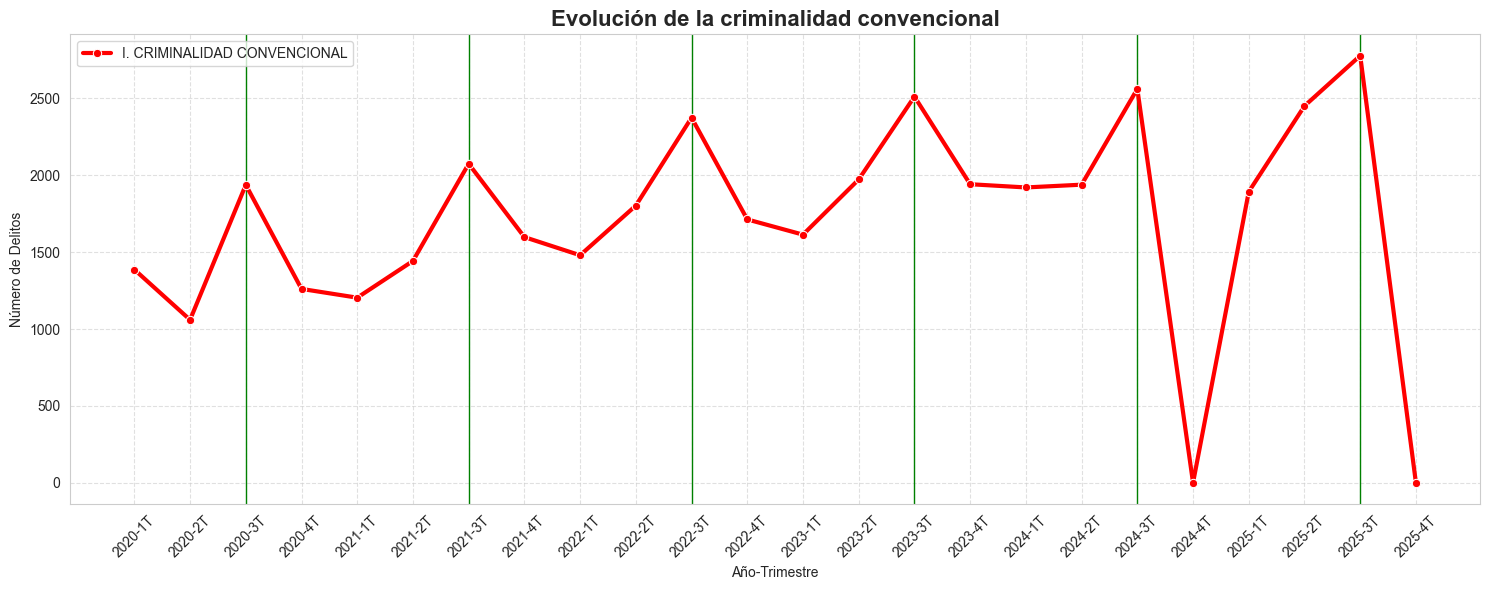

In [40]:
# Gráfica de evolución
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_criminalidad1, x='Año-Trimestre', y='I. CRIMINALIDAD CONVENCIONAL', 
             marker='o', linewidth=3, color='red', label='I. CRIMINALIDAD CONVENCIONAL')

# Resaltamos el tercer trimestre de cada año con una linea verde vertical
for x in df_criminalidad1[df_criminalidad1['Trimestre'] == 3]['Año-Trimestre']:
    plt.axvspan(x, x, color='green', alpha=1, label='Pico Verano' if x == '2020-T3' else "")

plt.title('Evolución de la criminalidad convencional', fontsize=16, fontweight='bold')
plt.ylabel('Número de Delitos')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

En primer lugar, notamos que el cuarto trimestre de los años 2024 y 2025 presenta delincuencia 0. Consideramos esto un error en los registros públicos.

Apreciamos una clara tendencia creciente de la delincuencia conforme aumentan los años. Además, se repite el mismo patrón por años. Del primer trimestre al tercero aumentan los delitos, para posteriormente disminuir en el cuarto trimestre. Observamos que, para todos los años, el tercer trimestre es el que presenta mayor número de delitos, y con una gran diferencia.

Ahora, nos centramos en cada delito por separado, para estudiar su distribución a lo largo de los años.

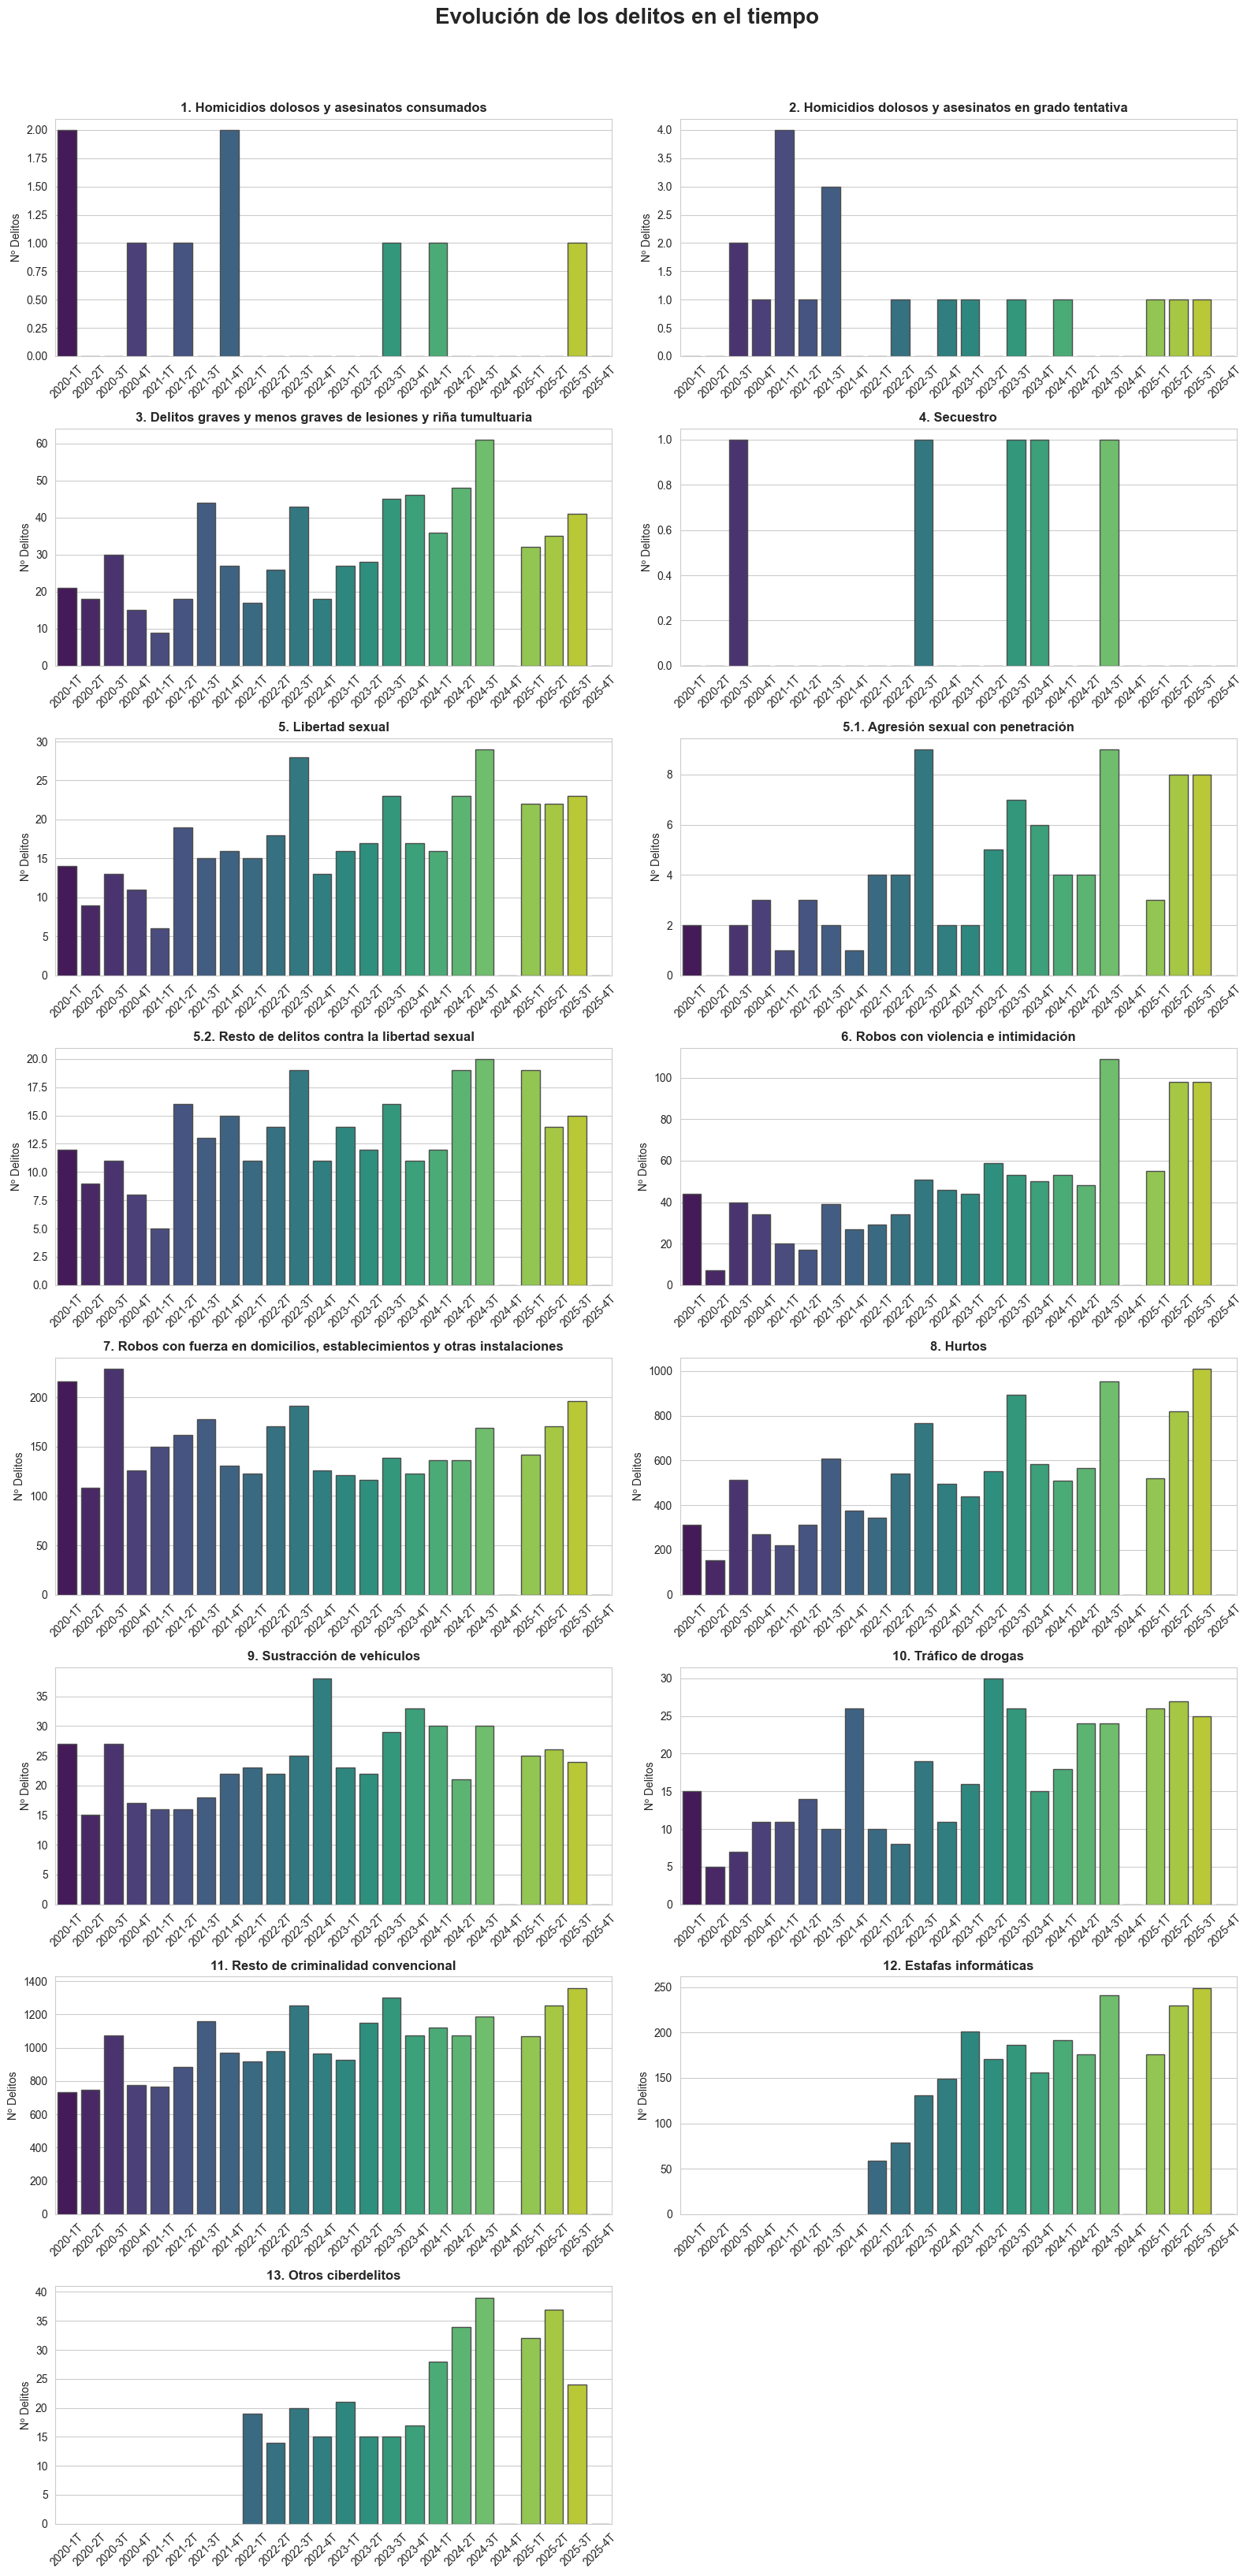

In [41]:
#  Definimos la lista exacta de las columnas 
delitos_cols = [
    '1. Homicidios dolosos y asesinatos consumados',
    '2. Homicidios dolosos y asesinatos en grado tentativa',
    '3. Delitos graves y menos graves de lesiones y riña tumultuaria',
    '4. Secuestro', 
    '5. Libertad sexual',
    '5.1. Agresión sexual con penetración',
    '5.2. Resto de delitos contra la libertad sexual',
    '6. Robos con violencia e intimidación',
    '7. Robos con fuerza en domicilios, establecimientos y otras instalaciones',
    '8. Hurtos',
    '9. Sustracción de vehículos', 
    '10. Tráfico de drogas',
    '11. Resto de criminalidad convencional',
    '12. Estafas informáticas',
    '13. Otros ciberdelitos'
]

# Configuración de la cuadrícula (2 columnas por fila)
n_cols = 2
n_rows = math.ceil(len(delitos_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Iteramos para crear cada gráfico
for i, col in enumerate(delitos_cols):
    sns.barplot(
        data=df_criminalidad1, 
        x='Año-Trimestre', 
        y=col, 
        ax=axes[i], 
        hue='Año-Trimestre',
        palette='viridis',
        legend=False,        
        edgecolor='0.3'
    )
    
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nº Delitos')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Limpieza: Si hay huecos vacíos en la cuadrícula, los ocultamos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Evolución de los delitos en el tiempo', fontsize=20, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


**Homicidios dolosos y asesinatos consumados**

* Apreciamos pocos registros de estos delitos. En total, en todo el tiempo hubo 9 homicidios de este tipo.

**Homicidios dolosos y asesinatos en grado tentativa**

* Observamos un aumento importante en el primer trimestre de 2021, pero el número de delitos de este tipo se mantiene constante en un homicidio para algunos periodos.

**Delitos graves y menos graves de lesiones y riña tumultuaria**
* Los delitos de este tipo han aumentado de forma constante desde 2020, con un pico destacado en el tercer trimestre de 2023.

**Secuestro**
* Rara vez ocurre un secuentra. Han ocurrido 5 en nuestros 6 años.

**Delitos contra la libertad sexual**
* Estos delitos parecen aumentar con el paso del tiempo, en especial para el último año. Apreciamos picos en el tercer trimestre de 2023-2024.

**Agresión sexual con penetración**
* También tienden a aumentar con los años, apreciamos picos en los trimestres terceros.

**Resto de delitos contra la libertad sexual**
* Los delitos relacionados con la libertad sexual (sin incluir la agresión sexual con penetración) también han tenido un aumento. De nuevo, vemos picos en los terceros trimestres.

**Robos con violencia e intimidación**
* También tienden a aumentar, especialmente en los dos últimos años.

**Robos con fuerza en domicilios, establecimientos y otras instalaciones**
* Se mantienen estables los números a lo largo de los años.

**Hurtos**
* Tienen una tendencia clara a aumentar, con picos preocupantes en todos los terceros trimestres.

**Sustracción de vehículos**
* Parece que aumentarom hasta 2023 y que están empezando a disminuir.

**Tráfico de drogas**
* Tiene una tendencia creciente.

**Resto de criminalidad convencional**
* Tendencia clara a aumentar en el tiempo.

**Estafas informáticas** y **Otros ciberdelitos**
* Se empezaron a tratar ej 2022 y aumentan de manera drástica con el paso de los años y de los trimestres.

Así las cosas, podemos decir que los delitos están aumentando con los años, y que se producen con gran diferencia en el tercer trimestre de cada año. Además, los delitos que más suceden son:

* 3. Delitos graves y menos graves de lesiones y riña tumultuaria
* 6. Robos con violencia e intimidación
* 7. Robos con fuerza en domicilios, establecimientos y otras instalaciones
* 8. Hurtos
* 11. Resto de criminalidad convencional
* 12. Estafas informáticas

En conjunto, los 3 delitos relacionados con abusos sexuales también se encuentran bastante presentes, aunque en menor medida que los 6 anteriores.


#### 2.1.6 Precios de la venta de viviendas en idealista

El enlace de esta sección nos lleva al histórico de precios de venta de vivienda en Torrevieja publicado por idealista. De las cuatro columnas de información disponibles, la que nos interesa para este análisis es la de *Precio m2*, ya que permite estudiar la evolución temporal del precio de la vivienda y ponerlo en relación con otros indicadores del municipio.

Para construir un *dataset* propio con esta información, realizamos *web scraping* sobre la página web. En primer lugar, utilizamos `undetected_chromedriver` para abrir la página en un navegador Chrome configurado de forma menos detectable, ya que este tipo de portales puede incorporar mecanismos anti-*bot*. Además, mantenemos la ventana visible para poder resolver manualmente un posible CAPTCHA o verificación de acceso en caso de que aparezca.

Una vez cargada la página y transcurrido un tiempo de espera para asegurar que el contenido dinámico se renderiza correctamente, capturamos el HTML completo mediante `driver.page_source` y lo procesamos con `BeautifulSoup`. A continuación, localizamos la tabla del histórico de precios buscando específicamente el elemento `table` con las clases HTML que identifican esa tabla en la página.

Después, recorremos las filas del cuerpo de la tabla (`tbody`) y extraemos, para cada fila, la información correspondiente a la fecha y al precio por metro cuadrado. En el caso del precio, realizamos una limpieza del texto para eliminar la unidad $€/m^2$, los espacios y los separadores de miles, de modo que el valor quede en formato numérico limpio y listo para su posterior análisis.

Finalmente, almacenamos los datos extraídos en una lista de diccionarios y los exportamos a un archivo CSV, con las columnas:
* *Fecha*: mes y año de referencia del dato.
* *Precio_m2*: precio de venta por metro cuadrado en Torrevieja.

De este modo, conseguimos una serie temporal mensual del precio de la vivienda en venta, adecuada para estudiar su evolución y compararla con otras variables del reto.

In [ ]:
# 1. Configuración del navegador indetectable
options = uc.ChromeOptions()
# Mantenemos la ventana visible para poder resolver el CAPTCHA si aparece
driver = uc.Chrome(options=options)

url = "https://www.idealista.com/sala-de-prensa/informes-precio-vivienda/venta/comunitat-valenciana/alicante-alacant/torrevieja/historico/"

try:
    driver.get(url)
    
    # --- MOMENTO CRÍTICO ---
    # Si te aparece un "Verificar que eres humano" o un puzzle, HAZLO TÚ MISMO en la ventana.
    # El script esperará 20 segundos para darte tiempo.
    time.sleep(20) 

    # 2. Pasamos el HTML renderizado a BeautifulSoup
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    
    # Buscamos la tabla con las clases que identificamos en tu inspección
    table = soup.select_one('table.js-scroll-header.component-table')

    lista_precios = []

    if table:
        # Localizamos todas las filas de la tabla
        rows = table.find('tbody').find_all('tr', class_='table__row')
        
        for row in rows:
            # Buscamos las celdas de cada fila
            cells = row.find_all('td', class_='table__cell')
            
            if len(cells) >= 2:
                # Extracción según tu lógica original
                fecha_raw = cells[0].get_text(strip=True)
                precio_raw = cells[1].get_text(strip=True)

                # Limpieza: "2.407 €/m2" -> "2407"
                # Quitamos la unidad, espacios y el punto de miles
                precio_limpio = precio_raw.replace("€/m2", "").replace(".", "").strip()
                
                lista_precios.append({
                    'Fecha': fecha_raw,
                    'Precio_m2': precio_limpio
                })

        # 3. Guardar en un archivo CSV para Excel
        with open('precios_vivienda.csv', 'w', newline='', encoding='utf-8') as file:
            writer = csv.DictWriter(file, fieldnames=['Fecha', 'Precio_m2'])
            writer.writeheader()
            writer.writerows(lista_precios)
        print("\n[INFO] Los datos se han guardado en 'precios_vivienda.csv'")

    else:
        print("ERROR: No se encontró la tabla. Probablemente el bloqueo persiste o la página no cargó.")

except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

finally:
    # Cerramos el navegador después de terminar
    time.sleep(5)
    driver.quit()


[INFO] Los datos se han guardado en 'precios_vivienda.csv'


Como preprocesamiento o limpieza de los datos, eliminamos los últimos 9 registros ya que aparecen con un *Precio_m2* de *nd (dato no disponibles)*. También. convertimos los tipos de datos:
1. *Fecha* pasa de `str` a `datetime64`.
2.  *Precio_m2* pasa de `str` a `int64`.

In [42]:
df_viviendas = pd.read_csv('../DATASETS/RETO 4/DATASETS ORIGINALES/precios_vivienda.csv', encoding='utf-8', sep=',')

# Eliminamos los últimos 9 registros
df_viviendas = df_viviendas.iloc[:-9]

# Convertimos tipos
df_viviendas['Fecha'] = pd.to_datetime(df_viviendas['Fecha'], dayfirst=True)
df_viviendas['Precio_m2'] = df_viviendas['Precio_m2'].astype(int)

In [43]:
print("=== 1. PRIMERAS FILAS DEL DATASET ===")
display(df_viviendas.head())

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_viviendas.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_viviendas.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_viviendas.duplicated().sum()}\n")

=== 1. PRIMERAS FILAS DEL DATASET ===


,Fecha,Precio_m2
0,2026-02-01,2407
1,2026-01-01,2409
2,2025-12-01,2392
3,2025-11-01,2336
4,2025-10-01,2319



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Fecha      233 non-null    datetime64[us]
 1   Precio_m2  233 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 3.8 KB

=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===
Fecha        0
Precio_m2    0
dtype: int64

Número de filas exactamente iguales (duplicadas): 0



Añadimos variables auxiliares para las gráficas:

In [44]:
df_viviendas['Variacion_mensual'] = df_viviendas['Precio_m2'].pct_change() * 100
df_viviendas['Año'] = df_viviendas['Fecha'].dt.year
df_viviendas['Mes'] = df_viviendas['Fecha'].dt.month

In [45]:
# Guardamos el dataset modificado
df_viviendas.to_csv(
    '../DATASETS/RETO 4/DATASETS MODIFICADOS/Viviendas_MOD.csv', 
    index=False, 
    sep=",", 
    encoding="utf-8"
)

En primer lugar, estudiamos la evolución del precio medio por metro cuadrado de la vivienda en Torrevieja. Esto nos permite analizar cómo ha cambiado el mercado inmobiliario a lo largo del tiempo, identificando tendencias, fases de crecimiento o caída, así como posibles cambios estructurales en el comportamiento de los precios.

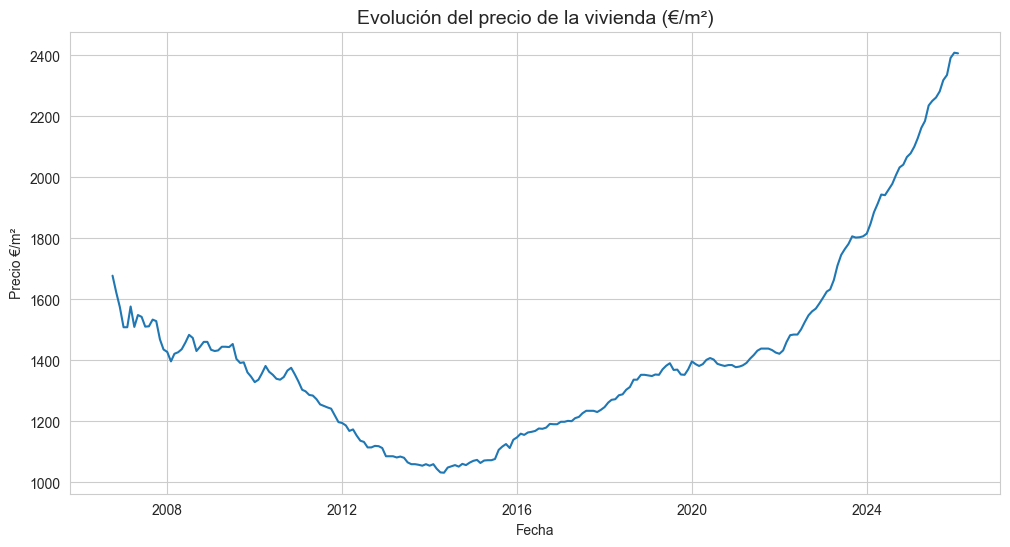

In [46]:
plt.figure(figsize=(12,6))
plt.plot(df_viviendas['Fecha'], df_viviendas['Precio_m2'])

plt.title('Evolución del precio de la vivienda (€/m²)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio €/m²')
plt.grid(True)

plt.show()

A partir de la gráfica, podemos identificar varias fases bien diferenciadas en la evolución del precio de la vivienda:

* En primer lugar, observamos un descenso progresivo desde aproximadamente 2007 hasta 2013-2014 (explosión de la burbuja inmobiliaria), en el que los precios pasaron de 1600–1700 $€/m^2$ a 1000 $€/m^2$ (un descenso de entorno el 40%).

* A partir de 2014, los precios empiezan a crecer de forma gradual y bastante estable hasta aproximadamente 2019-2020, alcanzando valores cercanos a los 1400 $€/m^2$.

* Entre 2020 y 2022, los precios se mantiene bastante estables, con pequeñas fluctuaciones pero sin cambios bruscos en la tendencia general.

* Sin embargo, desde 2022 en adelante, apreciamos un aumento prácticamente exponencial en los precios, pasando de los 1400 $€/m^2$ en 2022 a superar los 2400 $€/m^2$ en 2026 (un aumento del 70% en tan solo 4 años).

A continuación, representamos la variación porcentual mensual del precio por metro cuadrado con el fin de, a diferencia del análisis en niveles absolutos, estudiar la dinámica del mercado inmobiliario, mostrando cómo fluctúan los precios de un mes a otro.

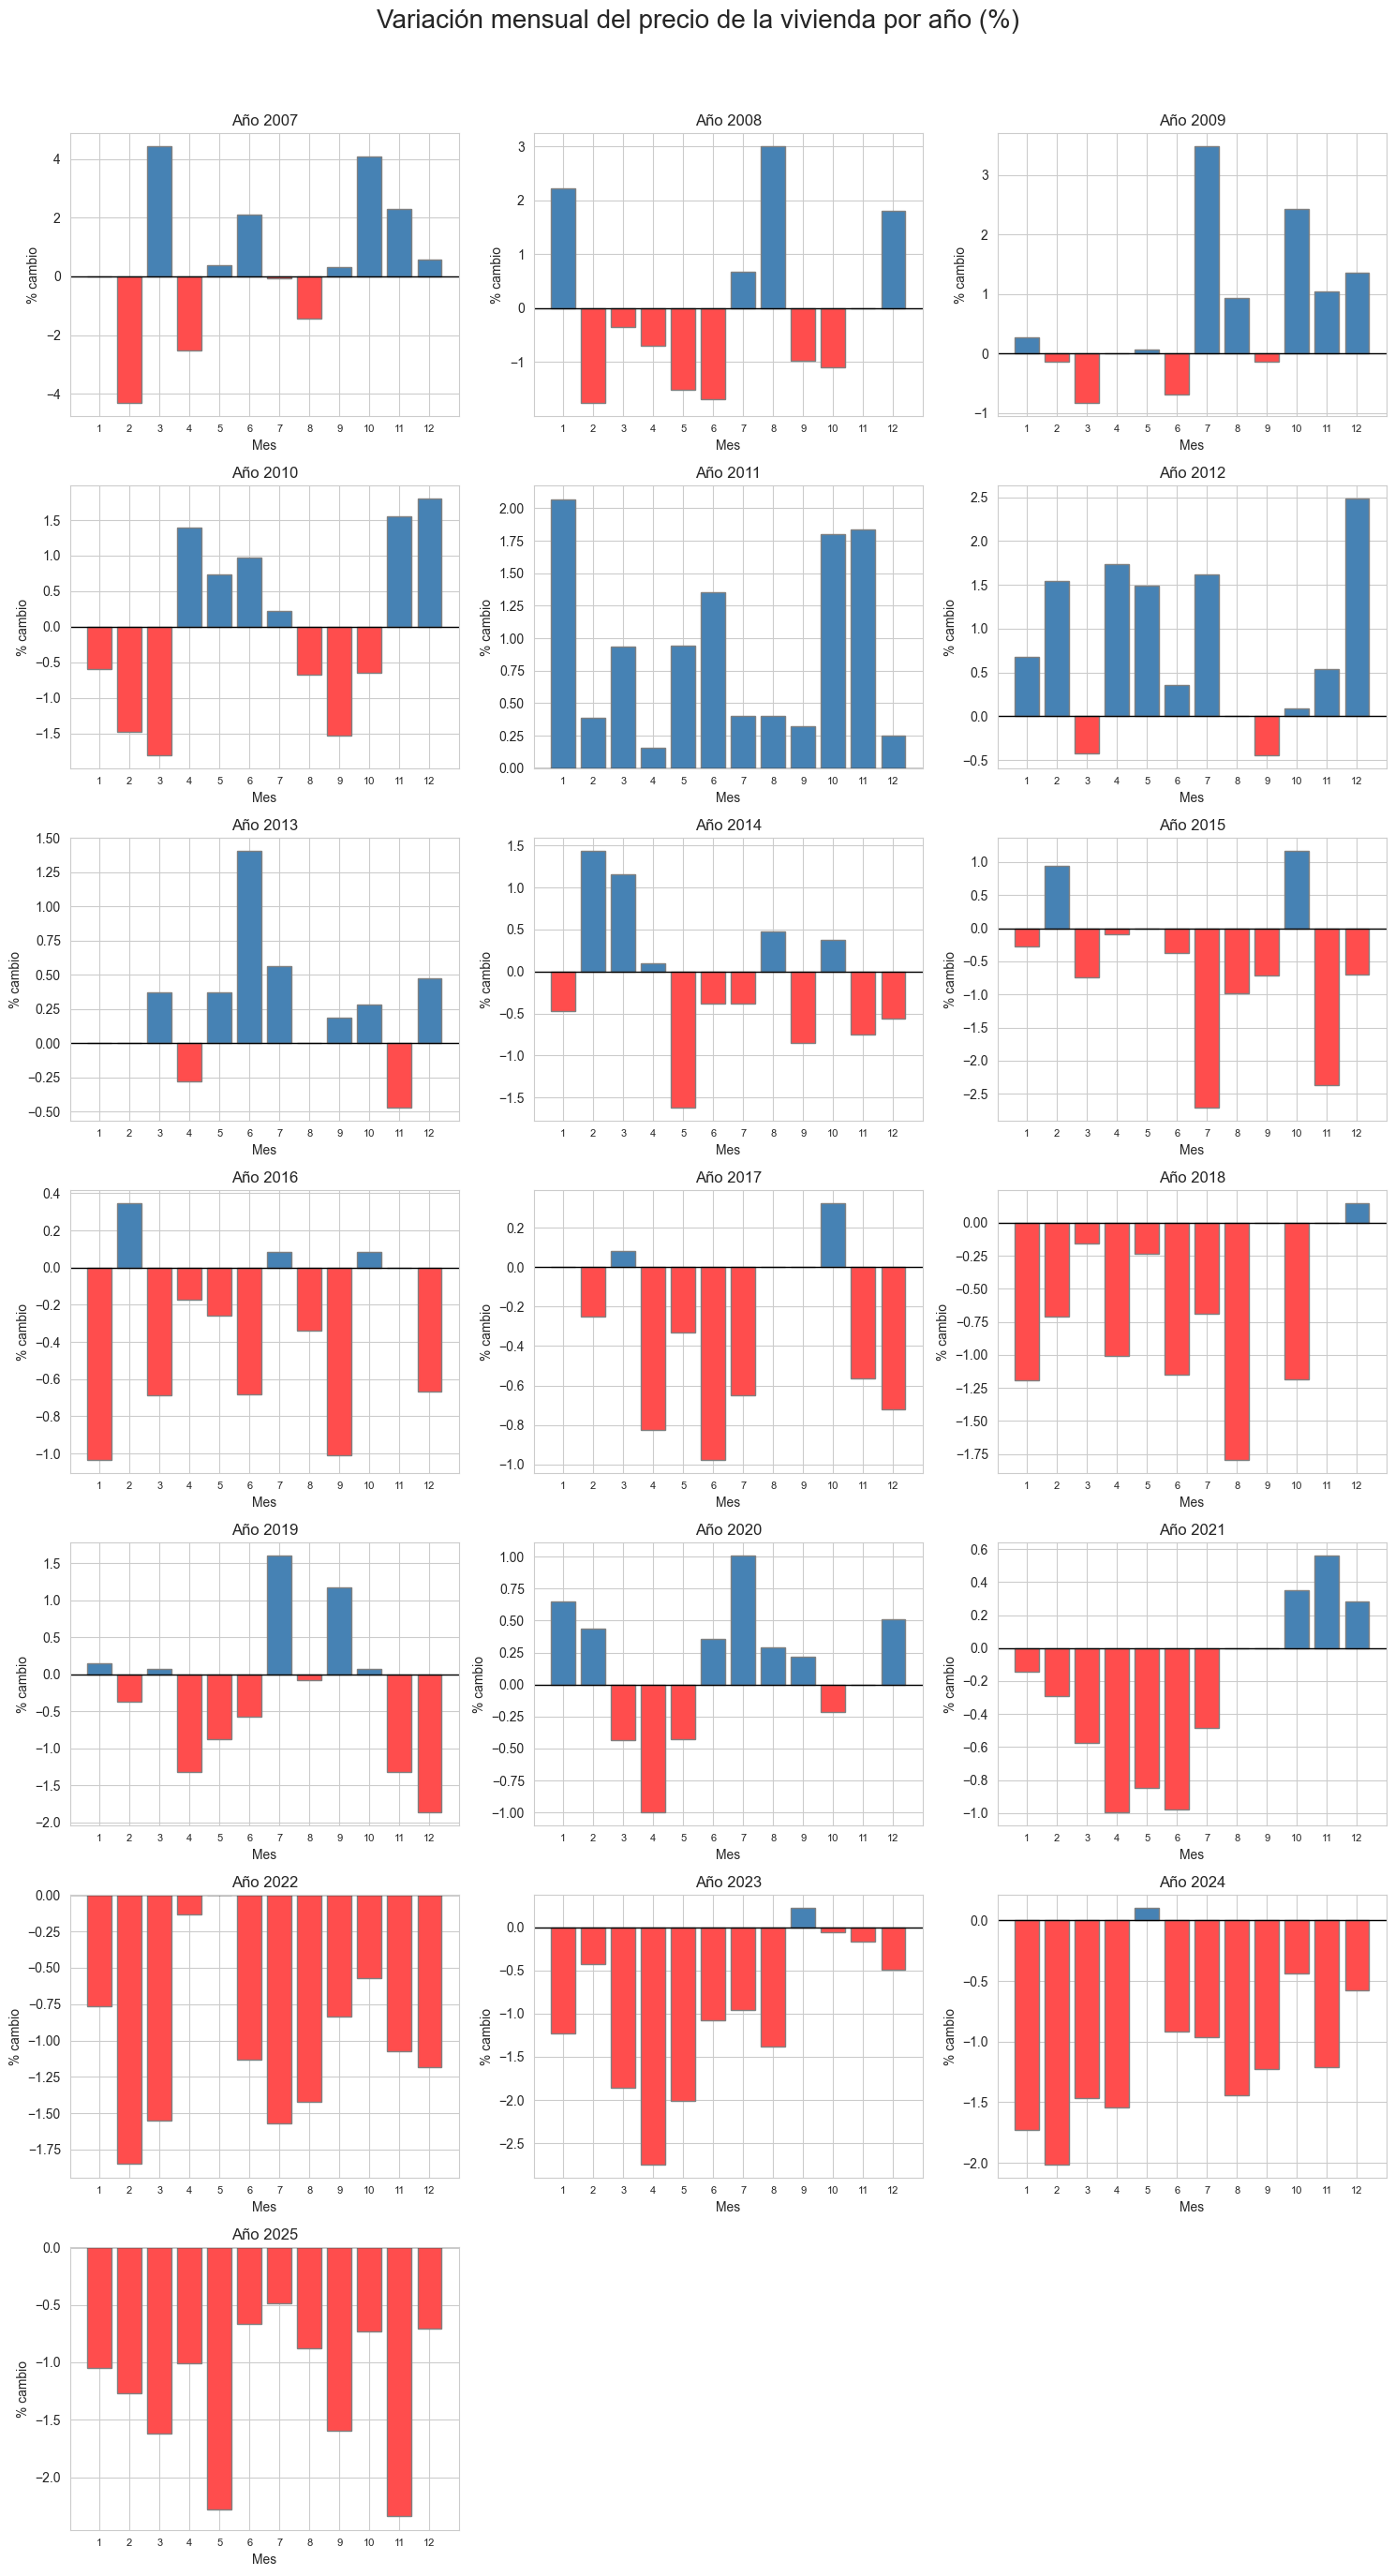

In [47]:
# Quitamos los años 2006 y 2026
df_var = df_viviendas.copy()
df_var = df_var[~df_var['Año'].isin([2006, 2026])]

# Lista de años
años = sorted(df_var['Año'].unique())

# Configuración subplots
n_cols = 3
n_rows = math.ceil(len(años) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

# Iteramos por años
for i, año in enumerate(años):
    df_año = df_var[df_var['Año'] == año].sort_values('Mes')
    
    x = np.arange(len(df_año))
    valores = df_año['Variacion_mensual'].values
    
    # Colores
    colors = ['steelblue' if v >= 0 else '#ff4d4d' for v in valores]
    
    axes[i].bar(x, valores, color=colors, edgecolor='gray')
    
    # Línea 0
    axes[i].axhline(0, color='black', linewidth=1)
    
    # Etiquetas eje X
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(df_año['Mes'], fontsize=8)
    
    axes[i].set_title(f'Año {año}')
    axes[i].set_xlabel('Mes')
    axes[i].set_ylabel('% cambio')
    axes[i].grid(True, axis='y')

# Ocultamos subplots vacíos
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Variación mensual del precio de la vivienda por año (%)', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

En primer lugar, notamos una elevada volatilidad en los primeros años (aproximadamente 2007–2010), donde aparecen tanto picos positivos como negativos que alcanzan valores superiores al $\pm 4$%. Los valores negativos indican que el precio ha subido con respecto al mes anterior, mientras que los valores positivos indican que el precio ha bajado. Esta alta variabilidad mensual evidencia un mercado claramente inestable. Dado que tenemos variaciones de entorno un 4% de un mes a otro en los primeros años, podemos decir que el mercado estaba muy inestable.

Entre 2007 y 2013, esta volatilidad se combina con una tendencia general descendente del precio (con algunas excepciones puntuales como 2008 y 2010, donde se registran subidas temporales). En general, los precios tienden a disminuir conforme avanza el año.

A partir de 2013–2014, se produce un cambio en la dinámica. La variabilidad se reduce notablemente y comienzan a predominar valores negativos en la variación mensual, lo que indica un cambio de tendencia hacia un crecimiento del precio. Desde 2014 hasta 2019, el patrón se invierte completamente: los precios aumentan de forma progresiva tanto a nivel anual como mensual, con variaciones relativamente estables en torno al -1.7% mensual.

En los años 2019 y 2020, observamos un comportamiento algo diferente, con incrementos de precio durante la primera mitad del año (hasta junio-julio), seguidos de ligeros descensos en los meses posteriores. Durante 2020 y 2021, aunque apreciamos episodios puntuales de caídas, estos son rápidamente compensados por nuevas subidas.

Finalmente, desde 2021 hasta 2025, el crecimiento del precio se vuelve continuo y sostenido tanto a nivel anual como mensual, con variaciones estables en torno al -1% / -2%. Además, apreciamos que la pendiente de crecimiento es cada vez mayor en los últimos años, lo que indica una intensificación del ritmo de subida de los precios. Como única excepción, en 2021 se produce un ligero descenso hacia finales de año.

#### 2.1.7 Precios de la venta de viviendas en idealista

El enlace de esta sección nos lleva al histórico de precios de alquileres de vivienda en Torrevieja publicado por idealista. De las cuatro columnas de información disponibles, la que nos interesa para este análisis es la de *Precio m2*, ya que permite estudiar la evolución temporal del precio de los alquileres y ponerlo en relación con otros indicadores del municipio.

Para construir un *dataset* propio con esta información, realizamos *web scraping* sobre la página web de la siguiente manera:

En primer lugar, configuramos un navegador automatizado utilizando la librería `undetected_chromedriver`, lo que permite acceder a la página evitando en la medida de lo posible los mecanismos de detección de bots. A continuación, cargamos la URL correspondiente al histórico de precios de alquiler en Torrevieja. Debido a las protecciones de la página (como verificaciones tipo CAPTCHA), introducimos una pausa en la ejecución para que podamos resolver manualmente cualquier comprobación de seguridad que aparezca.

Una vez cargada correctamente la página, obtenemos el HTML renderizado y lo procesamos mediante la librería `BeautifulSoup` Localizamos la tabla que contiene los datos de interés utilizando sus clases HTML específicas, para posteriormente recorrer todas sus filas.

Para cada fila, extraemos dos elementos: la fecha y el precio por metro cuadrado. Descartamos aquellas filas que contienen valores no disponibles (indicados como *n.d.*), ya que no aportan información útil para el análisis.

En cuanto al tratamiento de los datos, realiza una limpieza del campo de precio eliminando la unidad ($€/m^2$) y transformando el formato numérico, sustituyendo la coma decimal por un punto, con el objetivo de poder trabajar posteriormente con valores numéricos.

Finalmente, los datos procesados se almacenan en un archivo CSV, generando así un *dataset* estructurado con las variables *Fecha* y *Precio_m2*.

In [ ]:
# 1. Configuración del navegador indetectable
options = uc.ChromeOptions()
driver = uc.Chrome(options=options)

# URL específica de ALQUILER (histórico)
url = "https://www.idealista.com/sala-de-prensa/informes-precio-vivienda/alquiler/comunitat-valenciana/alicante-alacant/torrevieja/historico/"

try:
    driver.get(url)
    
    # RECUERDA: Si aparece el botón de "Pulsar y mantener", hazlo tú manualmente.
    time.sleep(20) 

    # 2. Procesamos el HTML con BeautifulSoup
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    table = soup.select_one('table.js-scroll-header.component-table')

    datos_alquiler = []

    if table:
        # Buscamos las filas de datos
        rows = table.find('tbody').find_all('tr', class_='table__row')
        
        for row in rows:
            cells = row.find_all('td', class_='table__cell')
            
            # Verificamos que la fila tenga datos reales (y no sea una fila vacía o de "n.d.")
            if len(cells) >= 2:
                fecha = cells[0].get_text(strip=True)
                precio_raw = cells[1].get_text(strip=True) # Ejemplo: "12,3 €/m2"

                # Si el precio es "n.d.", lo saltamos o lo guardamos como vacío
                if "n.d." in precio_raw.lower():
                    continue

                # --- LIMPIEZA ESPECÍFICA PARA ALQUILER ---
                # 1. Quitamos " €/m2"
                # 2. Cambiamos la coma por punto para que sea un número (12,3 -> 12.3)
                precio_limpio = precio_raw.replace('€/m2', '').replace(',', '.').strip()
                
                datos_alquiler.append({
                    'Fecha': fecha,
                    'Precio_m2': precio_limpio
                })

        # 3. Guardado en CSV
        nombre_csv = 'precio_alquileres.csv'
        with open(nombre_csv, 'w', newline='', encoding='utf-16') as f:
            writer = csv.DictWriter(f, fieldnames=['Fecha', 'Precio_m2'], delimiter='\t')
            writer.writeheader()
            writer.writerows(datos_alquiler)
        
        print("\n[INFO] Los datos se han guardado en 'precio_alquileres.csv'")

    else:
        print("No se pudo detectar la tabla. Revisa si el navegador muestra un error de acceso.")

except Exception as e:
    print(f"Error detectado: {e}")

finally:
    time.sleep(4)
    driver.quit()
    
print("\n[INFO] Los datos se han guardado en 'precio_alquileres.csv'")


[INFO] Los datos se han guardado en 'precio_alquileres.csv'


Como preprocesamiento de los datos, cambiamos la forma en que tenemos la variable *Fecha*. Ahora, la tenemos, por ejemplo, como `Febrero 2026`. La pasamos a `Febrero 2026`. También. convertimos los tipos de datos:
1. *Fecha* pasa de `str` a `datetime64`.
2.  *Precio_m2* pasa de `float64` a `int64`.

In [48]:
df_alquileres = pd.read_csv('../DATASETS/RETO 4/DATASETS ORIGINALES/precio_alquileres.csv', encoding='utf-16', sep=None, engine='python')

# Diccionario para traducir meses
meses_es = {
    'Enero': 'January', 'Febrero': 'February', 'Marzo': 'March', 'Abril': 'April',
    'Mayo': 'May', 'Junio': 'June', 'Julio': 'July', 'Agosto': 'August',
    'Septiembre': 'September', 'Octubre': 'October', 'Noviembre': 'November', 'Diciembre': 'December'
}

# Reemplazamos los nombres de los meses en español por inglés
df_alquileres['Fecha'] = df_alquileres['Fecha'].replace(meses_es, regex=True)

# Convertimos a datetime
# format='%B %Y': nombre del mes completo + Año de 4 dígitos
df_alquileres['Fecha'] = pd.to_datetime(df_alquileres['Fecha'], format='%B %Y')

# Convertimos a int64
df_alquileres['Precio_m2'] = df_alquileres['Precio_m2'].astype(int)


In [49]:
print("=== 1. PRIMERAS FILAS DEL DATASET ===")
display(df_alquileres.head())

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_alquileres.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_alquileres.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_alquileres.duplicated().sum()}\n")

=== 1. PRIMERAS FILAS DEL DATASET ===


,Fecha,Precio_m2
0,2026-02-01,12
1,2026-01-01,12
2,2025-12-01,12
3,2025-11-01,12
4,2025-10-01,11



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Fecha      213 non-null    datetime64[us]
 1   Precio_m2  213 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 3.5 KB

=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===
Fecha        0
Precio_m2    0
dtype: int64

Número de filas exactamente iguales (duplicadas): 0



Añadimos variables auxiliares para las gráficas:

In [50]:
df_alquileres['Variacion_mensual'] = df_alquileres['Precio_m2'].pct_change() * 100
df_alquileres['Año'] = df_alquileres['Fecha'].dt.year
df_alquileres['Mes'] = df_alquileres['Fecha'].dt.month

In [51]:
# Guardamos el dataset modificado
df_alquileres.to_csv(
    '../DATASETS/RETO 4/DATASETS MODIFICADOS/Alquileres_MOD.csv', 
    index=False, 
    sep=";", 
    encoding="utf-16"
)

En primer lugar, estudiamos la evolución del precio medio por metro cuadrado en los alquileres de Torrevieja. Esto nos permite analizar cómo ha cambiado el mercado inmobiliario a lo largo del tiempo, identificando tendencias, fases de crecimiento o caída, así como posibles cambios estructurales en el comportamiento de los precios.

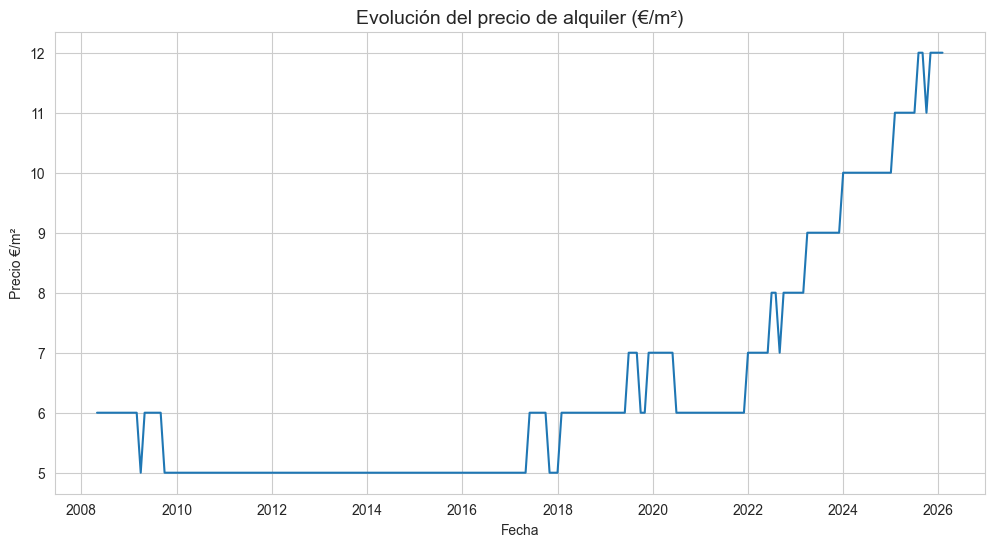

In [52]:
plt.figure(figsize=(12,6))
plt.plot(df_alquileres['Fecha'], df_alquileres['Precio_m2'])

plt.title('Evolución del precio de alquiler (€/m²)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio €/m²')
plt.grid(True)

plt.show()

En primer lugar, observamos un periodo inicial (2008–2017) caracterizado por una gran estabilidad en los precios, situándose en torno a los 5–6 $€/m^2$. Durante estos años, el mercado del alquiler presenta muy poca variación (solo una poca hasta 2010).

A partir de 2017, la tendencia se vuelve creciente. Sin embargo, es a partir de 2019 cuando notamos un crecimiento más claro, aunque todavía moderado, con algunas oscilaciones puntuales.

El cambio más significativo se produce desde 2022 en adelante. En este periodo, el precio del alquiler experimenta sube de manera pronunciada y sostenida, pasando de valores cercanos a 6 $€/m^2$ hasta alcanzar aproximadamente $12 €/m^2$ en 2026 (se duplican los precios de los alquileres).

Finalmente, graficamos la evolución mensual del precio por metro cuadrado para cada año de forma individual, para analizar cómo varía el precio cada año y si se repiten patrones en los años.

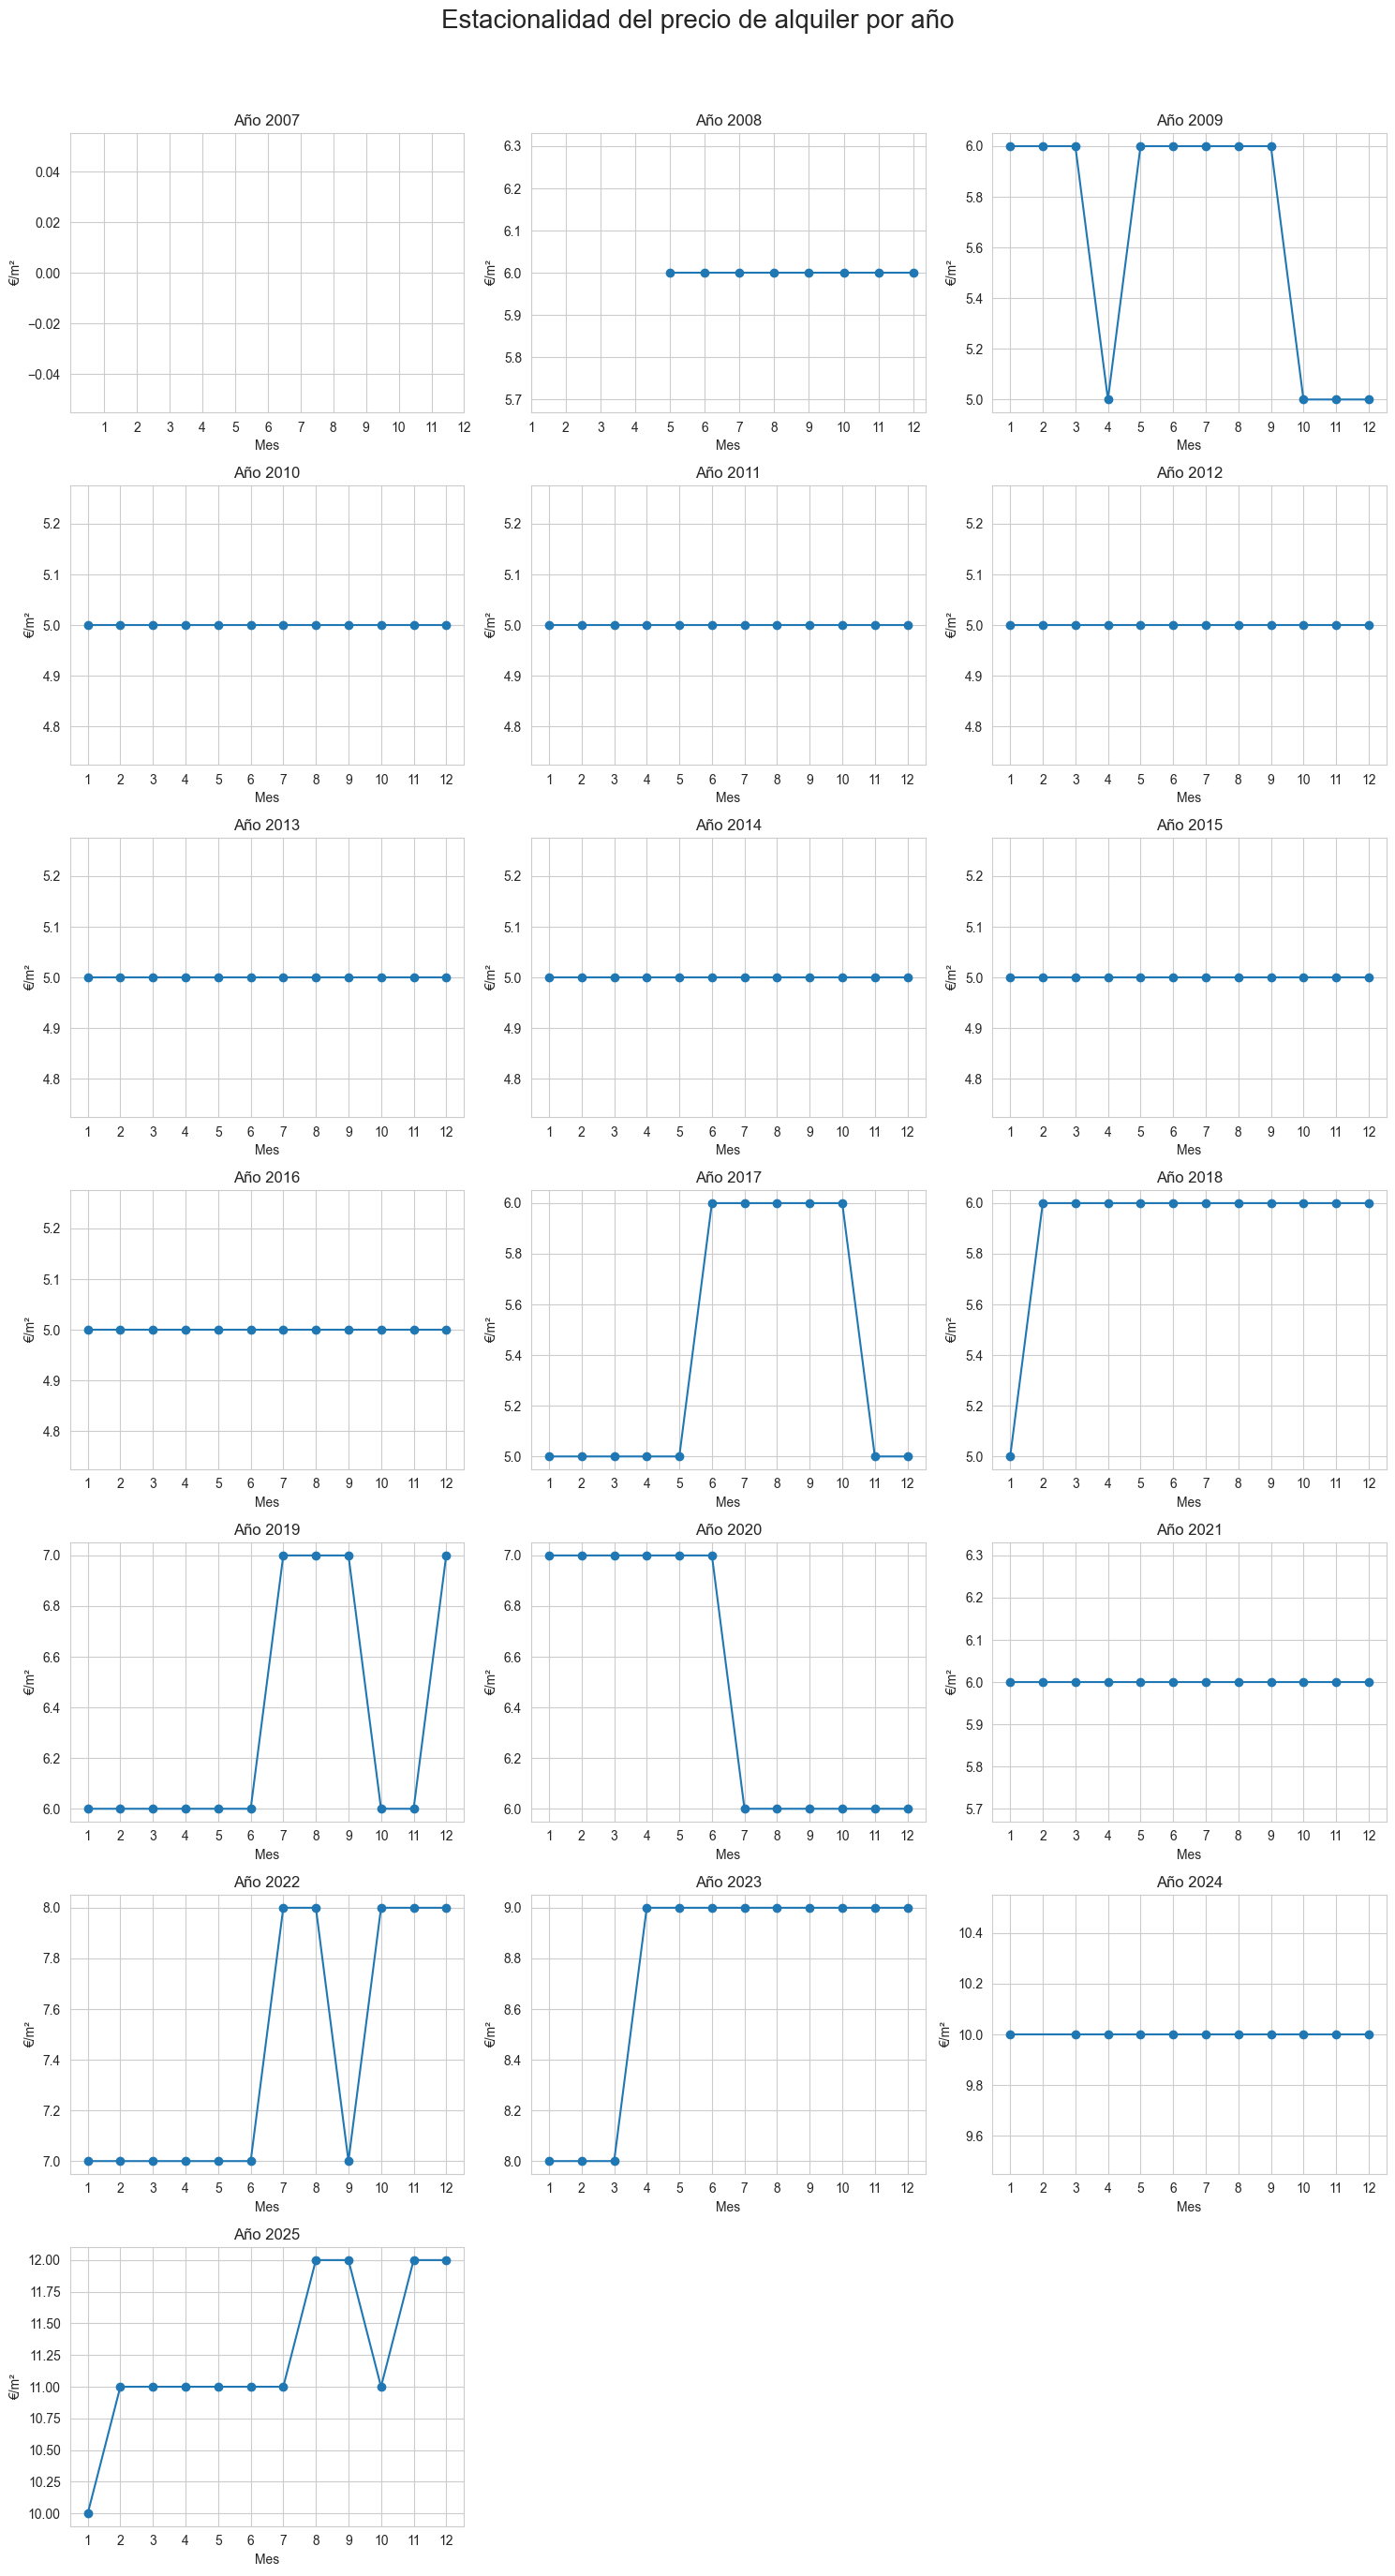

In [53]:
# Configuración subplots
n_cols = 3
n_rows = math.ceil(len(años) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

# Iteramos por cada año
for i, año in enumerate(años):
    df_año = df_alquileres[df_alquileres['Año'] == año]
    
    axes[i].plot(df_año['Mes'], df_año['Precio_m2'], marker='o')
    
    axes[i].set_title(f'Año {año}')
    axes[i].set_xlabel('Mes')
    axes[i].set_ylabel('€/m²')
    axes[i].set_xticks(range(1,13))
    axes[i].grid(True)

# Eliminamos ejes vacíos
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Estacionalidad del precio de alquiler por año', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

En primer lugar, observamos que durante los primeros años (2008–2016) apenas hay variaciones registradas (únicamete alguna en 2009), lo que indica una gran estabilidad del precio del alquiler en ese periodo

A partir de 2017, comienzan a aparecer las primeras variaciones significativas, con algunos incrementos puntuales importantes (por ejemplo, subidas cercanas al 20%) acompañados de caídas posteriores. No obstante, aunque notamos algunas reducciones en los precios de los alquileres, las pocas variaciones que se producen son subidas, de entorno al 7-10%, o incluso llegando al 16%.

Tampoco observamos patrones que se repitan año tras año, más alla de que, cada 4 años a partir de 2019, a mitad de año se produce una subida, luego una bajada y posteriormente otra subida en los precios de los alquileres.

## 3. Conclusiones conjuntas

El análisis conjunto de los 7 *datasets* estudiados permite hacernos una idea bastante coherente de la evolución reciente de Torrevieja. A grandes rasgos, los datos apuntan a un municipio sometido a una presión creciente desde varios frentes: presión turística, presión urbana e inmobiliaria, y también presión ambiental sobre algunos de sus ecosistemas.

Por un lado, los indicadores vinculados a la actividad humana y económica muestran una intensificación en los últimos años. Tanto los **gastos e ingresos municipales relacionados con el turismo** como los **precios de la vivienda en venta** y los **precios del alquiler** presentan una tendencia creciente, especialmente pronunciada desde 2022. En el caso de la vivienda en venta, tras la caída provocada por la explosión de la burbuja inmobiliaria entre 2007 y 2013-2014, se entra en una fase de recuperación progresiva que se acelera fuertemente a partir de 2022, con aumentos muy intensos en pocos años. En el caso del alquiler, la situación es aún más clara: tras una década larga de estabilidad, los precios prácticamente se duplican entre 2022 y 2026. Todo esto apunta hacia un mercado inmobiliario cada vez más tensionado, probablemente asociado a un aumento de la demanda residencial, turística o especulativa.

Esta idea casa bien con los datos de **afluencia a las lagunas**, aunque su serie temporal sea mucho más corta. El patrón que hemos observado nos muestra una fuerte concentración de visitantes en fines de semana, festivos y primeros meses del otoño, lo que podría indicar que los espacios naturales de Torrevieja funcionan son bastante atractivos y tienen público. Además, los perfiles horarios muestran una dinámica de entradas concentradas por la mañana y la tarde, acorde a un espacio recreativo o turístico. Aunque los sensores presentan inconsistencias, la conclusión general que sacamos es: existe una presión de uso significativa sobre estos espacios, especialmente en periodos de mayor movilidad y ocio. No obstante, si hubieramos dispuesto de un rango de tiempo mayor para estos datos, podríamos haber sacado conclusiones más robustas.

Al mismo tiempo, esta mayor actividad económica y turística parece coexistir con un aumento de problemas sociales y de seguridad. Los datos de **criminalidad** muestran una tendencia creciente bastante notoria conforme avanzan los años, con un patrón estacional muy marcado: los delitos aumentan del primer al tercer trimestre y descienden en el cuarto. El hecho de que el tercer trimestre concentre sistemáticamente los máximos de criminalidad resulta especialmente significativo, ya que coincide con la época del año en la que se espera una mayor actividad turística y una mayor ocupación del espacio urbano. No podemos afirmar causalidad directa solo con estos EDAs, pero la coincidencia temporal nos hace pensar que el incremento estacional de población y actividad está altamente asociado al aumento de ciertos delitos, especialmente hurtos, robos con violencia, lesiones, delitos sexuales y ciberdelitos.

En este sentido, apreciamos una cierta convergencia entre varios bloques de datos: el municipio parece volverse más atractivo económicamente, pero también más tensionado. Suben los precios de ventas de viviendas y de alquileres, crecen los **gastos e ingresos ligados al turismo**, aumenta la afluencia en espacios naturales y, paralelamente, se incrementa la criminalidad, especialmente en los trimestres de mayor actividad. Todo esto nos dibuja el perfil de un municipio cada vez más demandado, pero también más expuesto a desequilibrios derivados de ese crecimiento.

Frente a esta presión urbana y turística, la parte ambiental ofrece una imagen mixta. Por un lado, la **calidad microbiológica del agua de baño** es, en general, muy buena. La mayoría de las playas presentan valores de *E. coli* y *Enterococos* por debajo de los límites legales de calidad excelente, lo que indica que el baño es seguro en casi todos los casos. Los outliers detectados en algunas playas parecen ser más bien episodios puntuales que a un deterioro estructural. Esto nos indica que, al menos en superficie y en el entorno costero, el sistema sigue funcionando razonablemente bien pese a la elevada presión humana.

Sin embargo, la situación de las **aguas subterráneas** es diferente. Aquí, el problema principal no parece ser la presencia de compuestos orgánicos altamente tóxicos, ya que pesticidas, compuestos orgánicos volátiles y disruptores endocrinos presentan valores nulos en los registros disponibles, sino la salinidad y la presencia puntual o estacional de algunos metales pesados. La conductividad extremadamente alta, junto con los elevados valores de cloruros, sodio y calcio, nos llevan a un acuífero fuertemente salinizado, posiblemente por intrusión marina, sobreexplotación o influencia de las salinas. Además, ciertos metales como cadmio, plomo o níquel muestran picos y periodos de contaminación más prolongados, especialmente en algunos momentos de 2020-2022 y de forma muy marcada en 2025.

Esta diferencia entre aguas de baño y aguas subterráneas nos lleva a pensar que los indicadores más visibles y ligados al uso turístico directo ofrecen una imagen positiva, pero los indicadores menos visibles, como el estado del acuífero, muestran señales de deterioro más profundas y persistentes. En otras palabras, Torrevieja parece mantener una buena imagen ambiental en sus espacios de uso recreativo, pero esa buena situación no se extiende necesariamente al conjunto del sistema ecológico.

Además, las series temporales de las aguas subterráneas presentan un componente estacional compatible con la presión climática y antrópica (impacto del ser humano en entornos medioambientales): en verano y en noviembre aumentan varios compuestos, quizás por evaporación, por mayor concentración salina o por arrastre de sales y fertilizantes tras las primeras lluvias otoñales. Esta estacionalidad ambiental encaja parcialmente con la estacionalidad social y económica del municipio: los meses cálidos y los periodos de mayor actividad parecen ser también los momentos en los que más se tensionan tanto el territorio como ciertos parámetros ambientales.

Así las cosas, la imagen que podemos tener de Torrevieja es la de una ciudad que ha ganado atractivo y actividad en los últimos años, algo que se refleja en el crecimiento del turismo, en la subida de los precios inmobiliarios y en la intensidad de uso de algunos espacios, pero que presenta cada vez mayores niveles de criminalidad y ciertos indicios de presión ambiental, sobre todo en el subsuelo. Por tanto, la conclusión general no es simplemente que Torrevieja esté creciendo, sino que está creciendo bajo una intensificación que genera beneficios económicos y atractivo residencial, pero que al mismo tiempo incrementa tensiones sociales, encarece el acceso a la vivienda y deja huella en algunos componentes del medio natural.

## 4. Respuestas a las preguntas planteadas

A continuación, presentamos las respuestas a las preguntas iniciales del reto a partir de las conclusiones obtenidas. En aquellos casos en los que no ha sido posible responder de forma concluyente, indicamos las limitaciones y los datos adicionales necesarios.

---

#### 🔵 Eje ambiental

* **¿Cómo evolucionan en el tiempo los principales parámetros físico-químicos de las aguas subterráneas en Torrevieja?**  
Los parámetros físico-químicos muestran una elevada presencia de sales disueltas a lo largo del tiempo, destacando especialmente la conductividad, los cloruros, el sodio y el calcio. Además, hemos observado variaciones estacionales, con aumentos en verano y en noviembre. Algunos contaminantes como metales pesados presentan picos puntuales o periodos de mayor concentración.

* **¿Existen tendencias crecientes o decrecientes en contaminantes como nitratos o conductividad?**  
No se identifica una tendencia claramente creciente o decreciente sostenida en el tiempo para todos los contaminantes. Sin embargo, la conductividad se mantiene en niveles muy elevados de forma constante, lo que podría implicar un problema estructural de salinidad más que una tendencia puntual.

* **¿Se mantienen estables los niveles de calidad del acuífero a lo largo de los años?**  
No completamente. Aunque muchos compuestos se mantienen en niveles bajos, la elevada salinidad y la aparición de picos en metales pesados indican que el acuífero no presenta una estabilidad total y sufre episodios de deterioro.

* **¿Cuál es el nivel de concentración de bacterias fecales (E. coli y Enterococos) en las playas de Torrevieja?**  
Los niveles son, en general, bajos y se sitúan claramente por debajo de los umbrales establecidos para una calidad excelente.

* **¿Se mantienen estos indicadores dentro de niveles considerados seguros para el baño?**  
Sí. En prácticamente todas las muestras, los valores se encuentran dentro de los niveles seguros, lo que indica que las playas son aptas para el baño.

* **¿Existen diferencias significativas entre distintas playas o puntos de muestreo?**  
Sí, aunque no extremas. Algunas playas, como *Playa de las Piscinas del Paseo*, *Playa del Cura* y *Playa Los Náufragos*, presentan mayor variabilidad y más episodios puntuales de contaminación.

* **¿Cómo varía la afluencia de visitantes en la Laguna de la Mata a lo largo del tiempo?**  
La afluencia presenta una clara variación temporal, con mayor número de visitantes en fines de semana, festivos y en los primeros meses del otoño.

* **¿Se identifican patrones diarios o semanales en el uso de este espacio natural?**  
Sí. A nivel semanal, los fines de semana concentran la mayor afluencia. A nivel diario, las entradas se concentran en las primeras horas de la mañana y en la tarde, mostrando un patrón típico de uso recreativo.

---

#### 🔴 Eje social

* **¿Cómo evoluciona el número total de delitos en Torrevieja a lo largo del tiempo?**  
Se observa una tendencia creciente en el número total de delitos conforme avanzan los años.

* **¿Qué tipologías delictivas son más frecuentes en el municipio?**  
Los delitos más frecuentes son los relacionados con lesiones y riñas, robos con violencia, hurtos, robos con fuerza, criminalidad convencional y estafas informáticas.

* **¿Existen tendencias crecientes o decrecientes en la criminalidad en los últimos años?**  
Sí, la tendencia general es creciente, especialmente en los últimos años analizados.

* **¿Cómo han evolucionado los precios de la vivienda en venta en Torrevieja desde 2006?**  
Han seguido tres fases: caída (2007–2013), recuperación progresiva (2014–2020) y fuerte crecimiento desde 2022, con aumentos muy pronunciados.

* **¿Cómo han evolucionado los precios del alquiler desde 2008?**  
Han permanecido estables hasta aproximadamente 2017, para posteriormente iniciar una fase de crecimiento que se intensifica a partir de 2022, llegando a duplicarse en pocos años.

* **¿Existen cambios estructurales en el mercado inmobiliario en determinados periodos?**  
Sí. El cambio más importante se produce a partir de 2022, cuando se pasa de un crecimiento moderado a un crecimiento muy acelerado tanto en venta como en alquiler.

* **¿Cómo evolucionan los gastos e ingresos municipales asociados al turismo?**  
Tanto los gastos como los ingresos muestran una tendencia creciente a lo largo de los años. Los gastos presentan un patrón estacional muy claro, con máximos en el cuarto trimestre, mientras que los ingresos también aumentan con el tiempo, aunque de forma menos regular.

* **¿Existe un equilibrio entre los gastos y los ingresos generados por el turismo?**  
No completamente, aunque observamos una mejora progresiva. La proporción de dinero recuperado a través de los ingresos turísticos aumenta con los años, lo que sugiere una mayor eficiencia o rentabilidad del modelo turístico, aunque los gastos siguen siendo elevados.

* **¿Se identifican patrones estacionales en el gasto turístico?**  
Sí. Existe un patrón bastante consistente en el que el gasto aumenta progresivamente a lo largo del año, alcanzando su máximo en el cuarto trimestre, lo que indica una fuerte concentración del esfuerzo económico en ese periodo.

---

#### 🟢 Inferencias (cruce de datos)

* **¿Coinciden los periodos de mayor afluencia de visitantes con cambios en la calidad de las aguas subterráneas?**  
No podemos afirmar con certeza debido a la falta de alineación temporal exacta entre ambos datasets. Sería necesario disponer de datos simultáneos de afluencia y calidad del agua en los mismos periodos.

* **¿Se observa alguna relación temporal entre la presión de visitantes (Laguna) y los niveles de contaminantes?**  
No podemos concluir de forma directa. Se necesitaría una serie temporal más larga y sincronizada de ambos fenómenos.

* **¿Se producen variaciones en los indicadores microbiológicos de las playas en periodos de mayor uso turístico?**  
No hemos observado una relación clara en los datos analizados. Aunque existen picos puntuales, no podemos vincularlos directamente con periodos de mayor uso sin un análisis temporal más preciso.

* **¿Puede inferirse que el sistema de saneamiento mantiene su funcionamiento bajo presión estacional?**  
Sí, de forma indirecta. A pesar del aumento de actividad turística, los niveles microbiológicos se mantienen en rangos seguros, lo que sugiere un funcionamiento adecuado del sistema de saneamiento.

* **¿Coinciden los periodos de mayor afluencia de visitantes con incrementos en la criminalidad?**  
Sí, de forma indirecta. El tercer trimestre concentra tanto mayor actividad turística como mayores niveles de criminalidad, lo que nos lleva a una posible relación.

* **¿Se observan patrones estacionales en determinados tipos de delitos (por ejemplo, hurtos)?**  
Sí. Muchos delitos, especialmente hurtos y robos, presentan picos en el tercer trimestre de cada año.

* **¿Existe una relación entre el crecimiento de los precios de la vivienda y el modelo turístico del municipio?**  
No podemos demostrar causalidad directa, pero la coincidencia entre el aumento del turismo y la subida de precios nos hace pensar fuertemente en una relación plausible.

* **¿Se comportan de forma diferente los precios de venta y los precios de alquiler?**  
Sí. El alquiler muestra una estabilidad prolongada seguida de un crecimiento brusco, mientras que la venta presenta ciclos más claros (caída, recuperación y crecimiento acelerado). No obstante, en los últimos años se comportan de la misma manera: suben constantemente y sin frenos.

* **¿Puede interpretarse la evolución de los precios como una señal indirecta de gentrificación o desplazamiento de población local?**  
Podría ser una hipótesis razonable, pero no podemos confirmarlo con los datos disponibles. Serían necesarios datos socioeconómicos (renta, movilidad, etc.).

* **¿Se puede relacionar la presión turística con el deterioro o estabilidad de indicadores ambientales?**  
No de forma concluyente. Aunque hay indicios de presión ambiental (especialmente en aguas subterráneas), no podemos establecer una relación directa sin datos más completos y sincronizados.

* **¿Existe una relación temporal entre presión turística, criminalidad y evolución del mercado inmobiliario?**  
Sí, a nivel inferencial. Los tres indicadores muestran incrementos en los últimos años y patrones estacionales coincidentes, lo que sugiere una dinámica común asociada al aumento de actividad.

* **¿Se comportan de forma coherente los distintos indicadores ante los periodos de mayor demanda?**  
En gran medida, sí. En los periodos de mayor actividad (especialmente verano), aumentan la criminalidad y la presión sobre el territorio, mientras que los precios inmobiliarios reflejan una tendencia estructural al alza. Sin embargo, los indicadores ambientales visibles (como las aguas de baño) se mantienen estables, lo que indica cierta resiliencia del sistema en superficie.

### 4.1 Líneas de investigación futuras

A partir de las preguntas que no hemos podido resolver con los datos disponibles y los que nos hemos sido capaces de encontrar, hemos pensado varias líneas de investigación que permitirían completar y enriquecer el análisis que hemos realizado.

En primer lugar, en el eje ambiental, sería muy interesante incorporar datos adicionales que permitan cuantificar de forma directa la presión sobre los recursos naturales. En particular, disponer de series temporales sobre el consumo de agua (a nivel mensual o estacional) permitiría analizar si existe una relación clara entre el aumento de población turística y la demanda hídrica. Asimismo, contar con información diferenciada entre consumo de residentes y turistas ayudaría a entender mejor el impacto real del turismo sobre este recurso.

De igual forma, sería muy relevante acceder a datos sobre generación de residuos, ya que permitirían evaluar si los periodos de mayor actividad turística se traducen en un aumento significativo de desechos, lo que reforzaría la hipótesis de presión ambiental estacional. En esta misma línea, disponer de medidas directas de ocupación de playas (por ejemplo, densidad de personas por metro cuadrado) permitiría cuantificar de forma precisa los niveles de saturación del litoral en temporada alta, algo que actualmente solo podría inferirse indirectamente.

En cuanto al eje social, una de las principales limitaciones del análisis es la falta de desagregación de los datos de criminalidad. Sería necesario disponer de información que permita distinguir entre población residente y visitante, así como datos georreferenciados por barrios o zonas, para analizar posibles patrones espaciales y detectar áreas especialmente afectadas.

Por otro lado, en relación con el mercado inmobiliario, sería muy interesante incorporar datos sobre el alquiler turístico (tipo Airbnb o similares). Esto permitiría analizar hasta qué punto este tipo de oferta está influyendo en el incremento de los precios del alquiler residencial y en la tensión del mercado inmobiliario.